In [58]:
import pandas as pd

#-- load 
df_SL_rpk = pd.read_csv('./preprocessing/earliest_tp_rpk_avg_value_for_cohort_techreps_071626.csv').set_index('peptide')
df_hbdb_rpk = pd.read_csv('./preprocessing/hbdb_pass_100k_techreps_averaged_071626.csv').set_index('peptide')

df_sl_z = pd.read_csv('z_score_df_SL_over_US_090226.csv').set_index('peptide')
df_hbdb_z = pd.read_csv('z_hbdb_loo_results_090226.csv').set_index('peptide')

peps_metadata = (
pd.read_csv('lassa_library_sequences_species_standardized_070726.csv').rename(columns={'seq_id': 'peptide'})
)
#-- correct wrong genus name
peps_metadata.loc[peps_metadata['genus'] == 'Arenavirus', 'genus'] = 'Mammarenavirus'

In [76]:
Z_THRESH = 3
SENS_MIN = 0.05
SPEC_MIN = 0.99

#-- per peptide stats (sensitivity / specificity etc.)
def seropositivity_stats(df_sl_z, df_hbdb_z, metadata, z_thresh=Z_THRESH):
    pass_sl = df_sl_z > z_thresh
    pass_hbdb = df_hbdb_z > z_thresh

    stats = pd.concat(
        [pass_sl.mean(axis=1), pass_hbdb.mean(axis=1)], 
        axis=1, keys=['frac_pass_z_in_SL', 'frac_pass_z_in_US'] #performs multiindex on colums
    ).reset_index()

    stats = stats.merge(
        metadata[['peptide', 'sequence', 'species', 'genus', 'subfamily', 'family', 'order', 
                  'protein_name', 'accession', 'collection_date', 'collection_date_standardized', 'geo_loc_name', 'host']], 
                  on = 'peptide', how='left'
    )

    stats['delta'] = stats['frac_pass_z_in_SL'] - stats['frac_pass_z_in_US']
    stats['sensitivity'] = stats['frac_pass_z_in_SL']
    stats['specificity'] = 1 - stats['frac_pass_z_in_US']
    stats['youden'] = stats['sensitivity'] + stats['specificity'] - 1

    pass_bool = pd.concat([pass_sl, pass_hbdb], axis=1).reset_index()

    return stats, pass_bool

#-- get dataframes
df_fractions, df_pass_z_boolean = seropositivity_stats(df_sl_z, df_hbdb_z, peps_metadata)

hits = df_fractions[
    (df_fractions['sensitivity'] >= SENS_MIN) & 
    (df_fractions['specificity'] >= SPEC_MIN)
].copy()


In [77]:
#filtering out taxa I don't want to include downstream, such as Trypanosomatidae and Konkoviridae

TAXON_LEVEL = 'family'
TAXON_TO_REMOVE = ['Trypanosomatidae', 'Konkoviridae']

hits = hits[~hits[TAXON_LEVEL].isin(TAXON_TO_REMOVE)].copy()

In [78]:
hits['species'].nunique()
hits.shape

(1278, 19)

In [63]:
hits.to_csv('peptides_passing_filtering_090226.csv', index=False)

### this file was then corrected by standardizing the species name based on the species names that are recognized by ICTV 2025 MSL41.v1

In [ ]:
hits_raw = pd.read_csv('peptides_passing_filtering_090126.csv')

In [ ]:
hits_raw.shape

(1305, 19)

In [79]:
hits_old_090126 = pd.read_csv('peptides_passing_filtering_090126_1305_ICTV_MSL41_corrected.csv')

In [80]:
mask = hits_old_090126['peptide'].isin(hits['peptide'])

In [82]:
mask = hits_old_090126['peptide'].isin(hits['peptide'])
hits = hits_old_090126[mask]

In [83]:
hits

,peptide,frac_pass_z_in_SL,frac_pass_z_in_US,sequence,species,genus,subfamily,family,order,protein_name,...,collection_date,collection_date_standardized,geo_loc_name,host,delta,sensitivity,specificity,youden,species_ICTV_status,Unnamed: 20
0,XQN14281.1|polymerase|Rodent_Mammarenavirus|FK...,0.088161,0,MYEYDLSSGFSWVDLDVKPSIITAAELTRLKITEAGVFDDFWDLWN,Rodent mammarenavirus,Mammarenavirus,NaN,Arenaviridae,Hareavirales,RNA-dependent RNA polymerase,...,23-Apr,2023-04,China,Rattus norvegicus,0.088161,0.088161,1,0.088161,unresolved_retained,NaN
1,XQN12076.1|polymerase|Mammarenavirus_lassaense...,0.083123,0,IEGQFLKVDKSQLLNELNNLYADKVVAEDNIEHLIYQFKRASPILR,Mammarenavirus lassaense,Mammarenavirus,NaN,Arenaviridae,Hareavirales,RNA dependent-RNA polymerase,...,12-Dec-78,12/12/78,USA,guinea pig,0.083123,0.083123,1,0.083123,official_ICTV_MSL41,NaN
3,XQN12074.1|precursor|Mammarenavirus_juninense|...,0.068010,0,EFCDMLRLFDYNKNAIKTLNDETKKQVNLMGQTINALISDNLLMKN,Mammarenavirus juninense,Mammarenavirus,NaN,Arenaviridae,Hareavirales,glycoprotein precursor,...,1980,1980,Argentina,Homo sapiens,0.068010,0.068010,1,0.068010,official_ICTV_MSL41,NaN
4,XQN12073.1|polymerase|Mammarenavirus_juninense...,0.085642,0,SEGTKVEITKLKSKNPSVDERESLESLWAPFGVLREIKAEVSMHEV,Mammarenavirus juninense,Mammarenavirus,NaN,Arenaviridae,Hareavirales,RNA dependent-RNA polymerase,...,1980,1980,Argentina,Homo sapiens,0.085642,0.085642,1,0.085642,official_ICTV_MSL41,NaN
5,XQN12073.1|polymerase|Mammarenavirus_juninense...,0.055416,0,KSYFTNAALRNLCFYSDDSPTEFTSISSNTGNLKFGLSYKEQVGSN,Mammarenavirus juninense,Mammarenavirus,NaN,Arenaviridae,Hareavirales,RNA dependent-RNA polymerase,...,1980,1980,Argentina,Homo sapiens,0.055416,0.055416,1,0.055416,official_ICTV_MSL41,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1300,AJP33321.1|polymerase|Cedar_virus|isolate=Geel...,0.078086,0,GRPETTWVGNDDSFKYILEHTINRDIGLVHSDMETGIGKDNYTILN,Henipavirus cedarense,Henipavirus,Orthoparamyxovirinae,Paramyxoviridae,Mononegavirales,RNA polymerase,...,26-Oct-10,10/26/10,Australia,Pteropus poliocephalus,0.078086,0.078086,1,0.078086,official_ICTV_MSL41,Henipavirus sp. -> Henipavirus cedarense
1301,YP_009091833.1|nucleoprotein|Ghana_virus|isola...,0.098237,0,LSTAIVESNVGKQELTSATREGRFASSAPNIIEVDEESEDEQPQPR,Henipavirus ghanaense,Henipavirus,Orthoparamyxovirinae,Paramyxoviridae,Mononegavirales,nucleoprotein,...,2009,2009,Ghana,Eidolon helvum,0.098237,0.098237,1,0.098237,official_ICTV_MSL41,Henipavirus sp. -> Henipavirus ghanaense
1302,YP_009091834.1|phosphoprotein|Ghana_virus|isol...,0.095718,0,SIQTKPARNASGGDGTNPQMASPPPPPVVTNPPLKKRVPKLSEPNT,Henipavirus ghanaense,Henipavirus,Orthoparamyxovirinae,Paramyxoviridae,Mononegavirales,phosphoprotein,...,2009,2009,Ghana,Eidolon helvum,0.095718,0.095718,1,0.095718,official_ICTV_MSL41,Henipavirus sp. -> Henipavirus ghanaense
1303,YP_009091834.1|phosphoprotein|Ghana_virus|isol...,0.178841,0,TREGVIDVHLIKEDNKILNMDQDNPCSNQITSQQETGVTKRGIGEN,Henipavirus ghanaense,Henipavirus,Orthoparamyxovirinae,Paramyxoviridae,Mononegavirales,phosphoprotein,...,2009,2009,Ghana,Eidolon helvum,0.178841,0.178841,1,0.178841,official_ICTV_MSL41,Henipavirus sp. -> Henipavirus ghanaense


In [84]:
hits = hits.merge(df_pass_z_boolean, on='peptide', how='left')

hits.to_csv('peptides_passing_filtering_corrected_w_cohort_booleans_090226.csv')

In [85]:
hits = hits.drop(columns='Unnamed: 20')

In [86]:
#-- one long master dataframe, all taxonomic levels stacked

#-- combine RPK dataframes
df_rpk = pd.concat([df_SL_rpk, df_hbdb_rpk], axis=1)
df_z = pd.concat([df_sl_z, df_hbdb_z], axis=1)

#id_vars are columns that remain completely unchanges
ID_VARS = ['peptide',
 'frac_pass_z_in_SL',
 'frac_pass_z_in_US',
 'sequence',
 'species',
 'genus',
 'subfamily',
 'family',
 'order',
 'protein_name',
 'accession',
 'collection_date',
 'collection_date_standardized',
 'geo_loc_name',
 'host',
 'delta',
 'sensitivity',
 'specificity',
 'youden',
 'species_ICTV_status'
]

long = hits.melt(id_vars=ID_VARS, var_name='individual', value_name='pass_z_3')

z_long = (
    df_z.loc[hits['peptide']]
    .reset_index()
    .melt(id_vars='peptide', var_name='individual', 
    value_name='zscore')
)

rpk_long = (
    df_rpk.loc[hits['peptide']]
    .reset_index()
    .melt(id_vars='peptide', var_name='individual', 
    value_name='rpk')
)

long = (long.merge(rpk_long, on=['peptide', 'individual'], 
        how='left')
        .merge(z_long, on=['peptide', 'individual'], how='left'
        )
)

#define the categories in the long_df
long['category'] = 'HBDB'
long.loc[long['individual'].str.startswith('S-'), 'category'] = 'S'
long.loc[long['individual'].str.startswith('C-'), 'category'] = 'C'
long['category'] = pd.Categorical(long['category'], categories=['S', 'C', 'HBDB'], ordered=True)

#define the cohort in the long_df
long['cohort'] = 'HBDB'
long.loc[long['individual'].str.startswith(('S-', 'C-')), 'cohort'] = 'SL'
long['cohort'] = pd.Categorical(long['cohort'], categories=['SL', 'HBDB'], ordered=True)

#add mean and median rpk per category (HBDB, S, C) for each peptide to long df
long['peptide_mean_rpk_per_category'] = long.groupby(['peptide', 'category'])['rpk'].transform('mean')
long['peptide_median_rpk_per_category'] = long.groupby(['peptide', 'category'])['rpk'].transform('median')

#add mean and median rpk per cohort (SL, HBDB) for each peptide to long df
long['peptide_mean_rpk_per_cohort'] = long.groupby(['peptide', 'cohort'])['rpk'].transform('mean')
long['peptide_median_rpk_per_cohort'] = long.groupby(['peptide', 'cohort'])['rpk'].transform('median')
long['peptide_max_rpk_per_cohort'] = long.groupby(['peptide', 'cohort'])['rpk'].transform('max')

total_hits_per_individual = long.groupby('individual')['pass_z_3'].sum()

/tmp/ipykernel_3586760/1511168052.py:64: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  long['peptide_mean_rpk_per_category'] = long.groupby(['peptide', 'category'])['rpk'].transform('mean')
/tmp/ipykernel_3586760/1511168052.py:65: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  long['peptide_median_rpk_per_category'] = long.groupby(['peptide', 'category'])['rpk'].transform('median')
/tmp/ipykernel_3586760/1511168052.py:68: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt 

In [87]:
def level_summary(long, level):
   
    summary = (
        long.groupby([level, 'individual', 'category', 'cohort'], 
    observed=True).agg(
        n_hits=('pass_z_3', 'sum'), #count of seroreactive peptides at this level
        mean_rpk=('rpk', 'mean'), 
        sum_rpk=('rpk', 'sum'), 
        max_rpk=('rpk', 'max'), 
        mean_zscore=('zscore', 'mean'), 
        max_zscore=('zscore', 'max'),
        n_peptides_for_taxon=('peptide', 'nunique'),
        #peptides representing this taxon
        )
        .reset_index()
    )

    summary['frac_of_individual_hits'] = (
        summary['n_hits'] / summary['individual'].map(total_hits_per_individual) #get the summed peptide count for that individual
    )

    summary['frac_of_total_taxon_hits'] = (
        summary['n_hits'] / summary['n_peptides_for_taxon']
    )

    summary = summary.rename(columns={level: 'value'}) #put taxon name into a column always called value
    summary.insert(0, 'level', level) #add a column that records which taxnonmic rank that value is
    return summary

master = pd.concat(
    [level_summary(long,lvl) for lvl in ['family', 'genus', 'species']], 
    ignore_index=True
)

master = master.sort_values(['level', 'category', 'individual'])

In [88]:
#adding seropositivity, defining the threshold of needing at least 2 independent peptide hits per taxon
MIN_HITS_FOR_SEROPOSITIVE = 2

master['is_seropositive'] = master['n_hits'] >= MIN_HITS_FOR_SEROPOSITIVE
master['frac_of_individual_hits_confirmed'] = (
    master['frac_of_individual_hits'].where(master['is_seropositive'], 0)
)

### improving master to also be defined as 'seropositive' based on the mean RPK value of US healthies for a specific species + 1 SD, like I did for the lasv ELISA's below

In [90]:
import numpy as np

hbdb_stats = (
    master[master['category'] == 'HBDB']
    .groupby(['level', 'value'], observed=True)['sum_rpk']
    .agg(hbdb_mean = 'mean', hbdb_std='std', hbdb_max='max')
    .reset_index()
)

hbdb_stats['threshold_rpk_1sd'] = hbdb_stats['hbdb_mean'] + hbdb_stats['hbdb_std']
hbdb_stats['threshold_rpk_max'] = hbdb_stats['hbdb_max']

master = master.merge(
    hbdb_stats[['level', 'value', 'threshold_rpk_1sd', 'threshold_rpk_max']], 
    on=['level', 'value'], how='left'
)

#classify with an explicit "undetermined" bucket for missing reference data

master['seropositive_rpk_1sd'] = np.select(
    [master['threshold_rpk_1sd'].isna(), master['sum_rpk'] > master['threshold_rpk_1sd']], 
    ['Undetermined', 'Positive'], 
    default='Negative'
)

master['seropositive_rpk_max'] = np.select(
    [master['threshold_rpk_max'].isna(), master['sum_rpk'] > master['threshold_rpk_max']], 
    ['Undetermined', 'Positive'], 
    default='Negative'
)

In [91]:
master.to_csv('master_peptide_thresh_090226.csv', index=False)

### reassigning Orthohantavirus sp. to Hantavirus sp. 

In [92]:
master.loc[master['value'] == 'Orthohantavirus sp.', 'value'] = 'Hantaviridae sp.'

long.loc[long['species'] == 'Orthohantavirus sp.', 'species'] = 'Hantaviridae sp.'

### doing an individual x taxon heatmap/clustermap

zoom into individuals (columns, ordered by category S - C - US) X top N species clustered by families (rows)
colored by log(sum_rpk) OR by seropositive_rpk_1sd
-> shows if 

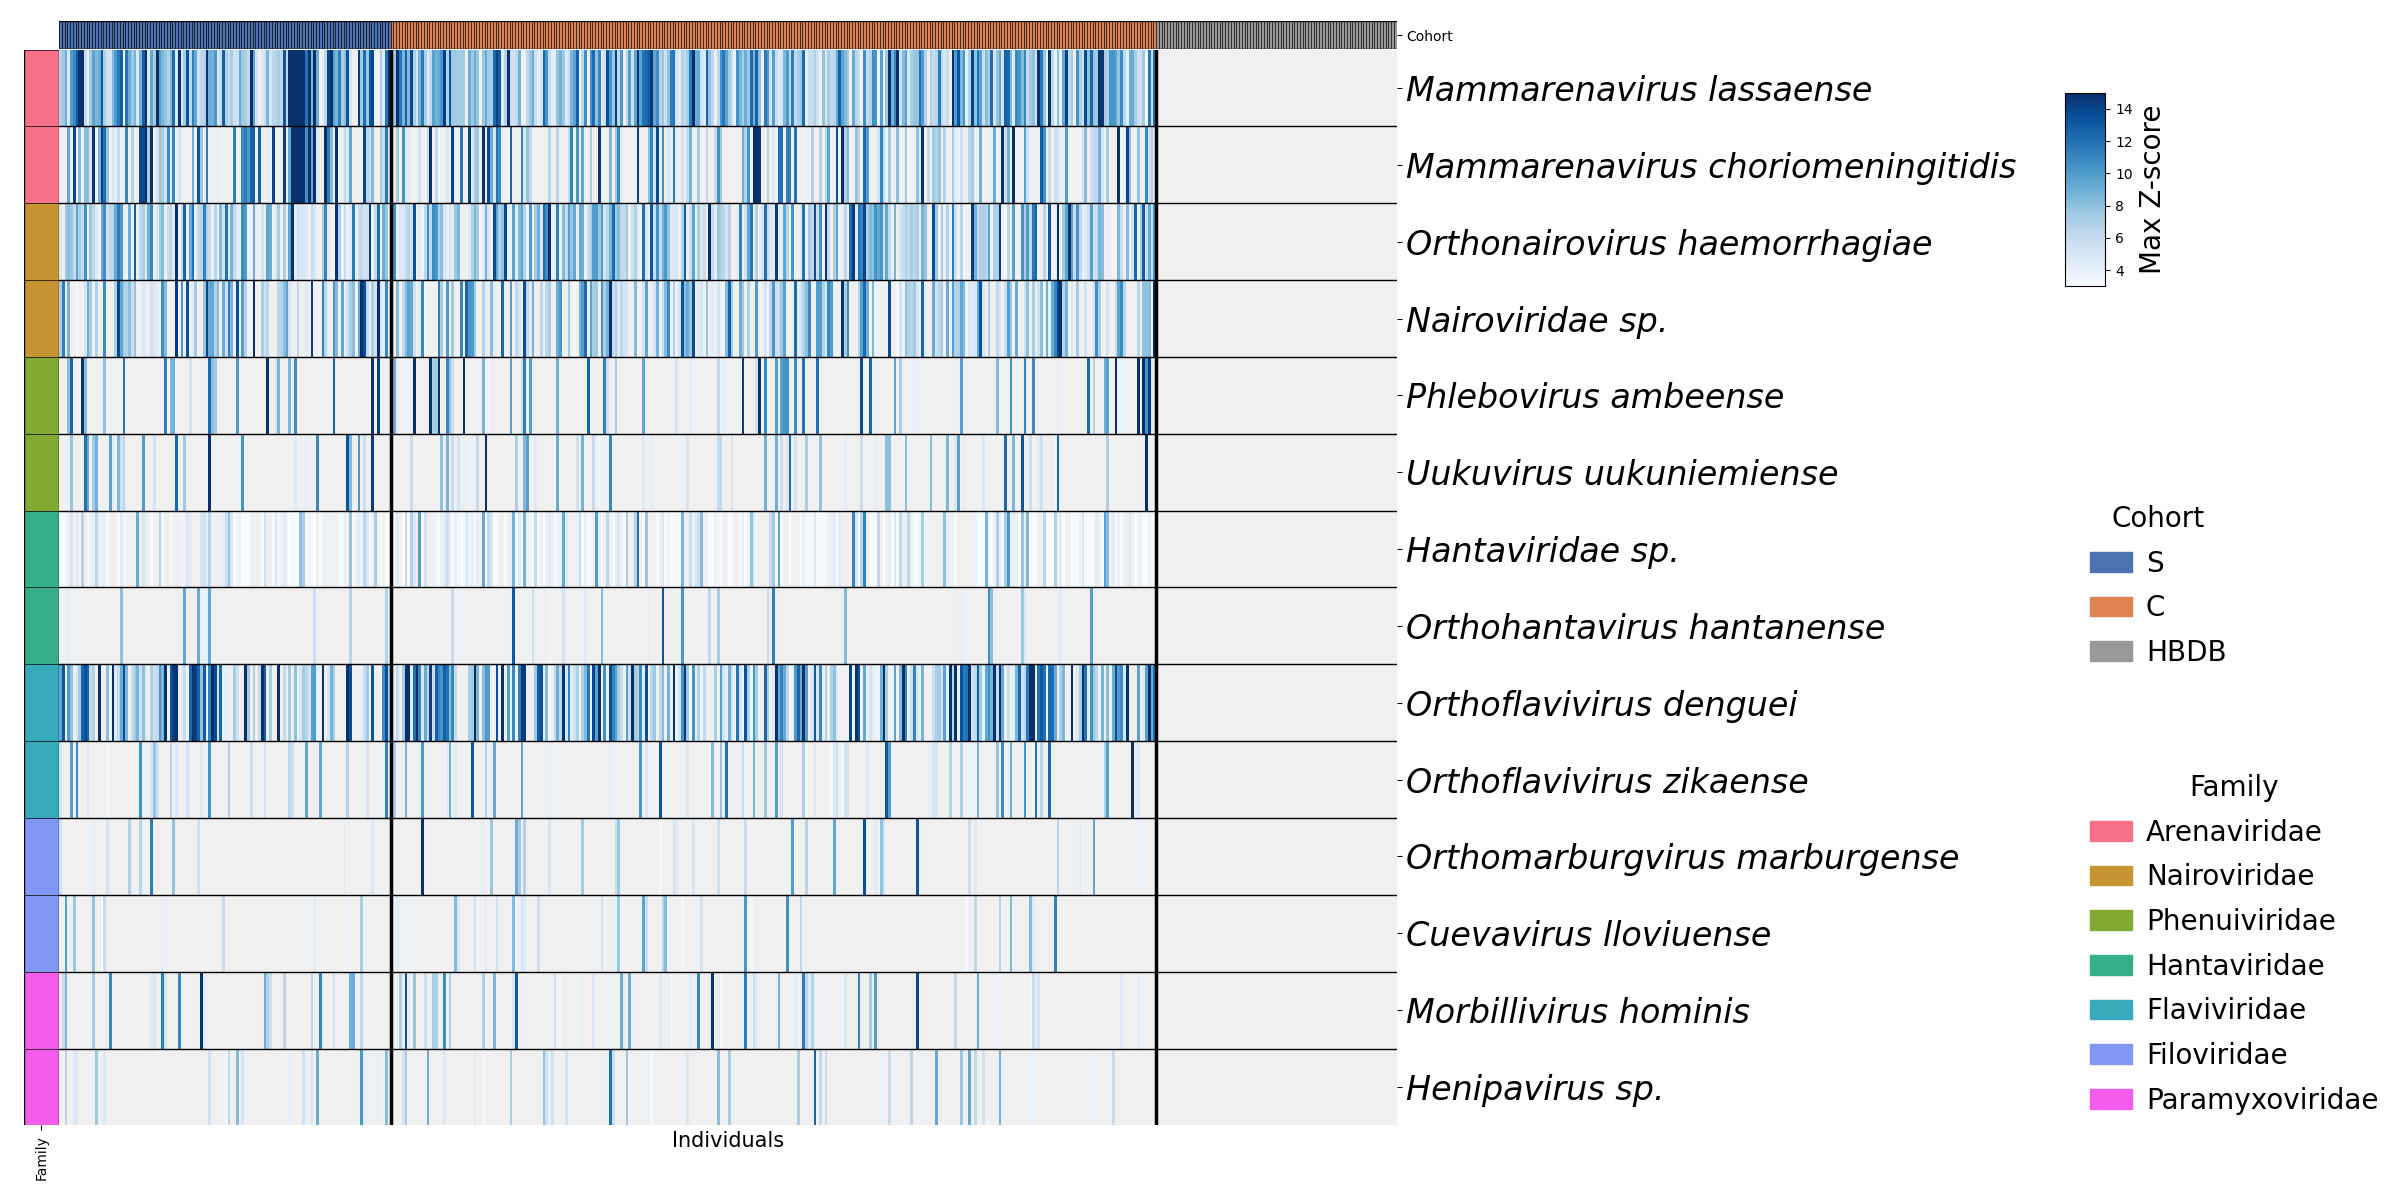

In [93]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import matplotlib.patches as mpatches

LEVEL = 'species' #or family
TOP_N_PER_FAMILY = 2

top_families = [
    'Arenaviridae', 'Nairoviridae', 'Phenuiviridae', 'Hantaviridae', 
    'Flaviviridae', 'Filoviridae', 'Paramyxoviridae', #'Matonaviridae', 'Togaviridae'
]

level_df = master[master['level'] == LEVEL].copy()

#attach family to each species 
species_to_family = long.drop_duplicates('species')[['species', 'family']]

species_prevalence = (
    level_df[level_df['category'] != 'HBDB']
    .groupby('value', observed=True)['is_seropositive'] #minimum >= 2 peptides reactive for species. value here is species name
    .sum()
    .rename('n_seropositive')
    .reset_index()
    .rename(columns={'value': 'species'})
    .merge(species_to_family, on='species', how='left')
)

species_prevalence = species_prevalence[species_prevalence['family'].isin(top_families)]

top_taxa = (
    species_prevalence[species_prevalence['n_seropositive'] >= df_SL_rpk.shape[1] * 0.05]
    .sort_values('n_seropositive', ascending=False)
    .groupby('family', observed=True)
    .head(TOP_N_PER_FAMILY)
    ['species']
)


heat_df = level_df[level_df['value'].isin(top_taxa)].copy()

heat_df['max_zscore_confirmed'] = heat_df['max_zscore'].where(heat_df['is_seropositive'], 0)
pivot = heat_df.pivot_table(index='individual', columns='value', values='max_zscore_confirmed', fill_value=0)

# order columns: family block (in your specified order), species within family by prevalence desc
species_order = (
    species_prevalence[species_prevalence['species'].isin(top_taxa)]
    .assign(family=lambda d: pd.Categorical(d['family'], categories=top_families, ordered=True))
    .sort_values(['family', 'n_seropositive'], ascending=[True, False])
    ['species']
)

pivot = pivot[species_order]

category_lookup = heat_df.drop_duplicates('individual').set_index('individual')['category']
palette = {'S': '#4C72B0', 'C': '#DD8452', 'HBDB': '#999999'}

# order rows S -> C -> HBDB
ordered_individuals = (
    category_lookup.sort_values(key=lambda s: s.map({'S': 0, 'C': 1, 'HBDB': 2})).index
)
pivot = pivot.loc[ordered_individuals]
row_colors = category_lookup.map(palette).reindex(pivot.index)

pivot_t = pivot.T

# ...(top_taxa / heat_df / pivot / pivot_t / row ordering — unchanged from before)...

cmap = sns.color_palette('Blues', as_cmap=True)
cmap.set_bad('#f0f0f0')  # non-reactive cells read as neutral, not fake-low-blue
mask = pivot_t == 0

species_family_map = species_prevalence.drop_duplicates('species').set_index('species')['family']
family_palette = dict(zip(top_families, sns.color_palette('husl', n_colors=len(top_families))))

species_row_colors = species_order.map(species_family_map).map(family_palette)
species_row_colors.index = species_order
species_row_colors.name = 'Family'

col_colors_named = row_colors.copy()
col_colors_named.name = 'Cohort'
g = sns.clustermap(
    pivot_t,
    mask=mask,
    row_colors=species_row_colors,
    col_colors=col_colors_named,
    cmap=cmap,
    figsize=(17, 12),
    xticklabels=False, yticklabels=True,
    row_cluster=False, col_cluster=False,
    vmin=3, vmax=15,
    dendrogram_ratio=(0.01, 0.01),
    colors_ratio=0.025,
    cbar_pos=None,   # disable the default colorbar entirely
)

# --- black borders around annotation color bars ---

# Cohort bar: one colored cell per individual (horizontal)
ax_col = g.ax_col_colors
n_individuals = pivot_t.shape[1]

for x in range(n_individuals + 1):
    ax_col.axvline(x, color='black', linewidth=0.5)

ax_col.axhline(0, color='black', linewidth=1)
ax_col.axhline(1, color='black', linewidth=1)


# Family bar: one colored cell per species (vertical)
ax_row = g.ax_row_colors
n_species = pivot_t.shape[0]

for y in range(n_species + 1):
    ax_row.axhline(y, color='black', linewidth=0.5)

ax_row.axvline(0, color='black', linewidth=1)
ax_row.axvline(1, color='black', linewidth=1)


# bounradires for species 

ax = g.ax_heatmap
n_species = pivot_t.shape[0]

for y in range(1, n_species):
    ax.axhline(y=y, color='black', linewidth=1)

cat_series = category_lookup.reindex(ordered_individuals)
boundaries = cat_series.ne(cat_series.shift()).to_numpy().nonzero()[0]
boundaries = boundaries[boundaries > 0]
for x in boundaries:
    ax.axvline(x=x, color='black', linewidth=2.5)

ax.set_yticklabels(ax.get_yticklabels(), fontsize=24, style='italic')
ax.set_xlabel('Individuals', fontsize=15)
ax.set_ylabel('')
ax.tick_params(left=False, bottom=False)

# --- everything below is anchored to `ax`, so it stacks reliably ---

# 1. colorbar (top band)
cbar_ax = ax.inset_axes([1.5, 0.78, 0.03, 0.18])  # x, y, width, height — axes-fraction
norm = plt.Normalize(vmin=3, vmax=15)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, cax=cbar_ax)
cbar.set_label('Max Z-score', fontsize=20)

# 2. Cohort legend (middle band)
cat_handles = [mpatches.Patch(color=c, label=k) for k, c in palette.items()]
leg1 = ax.legend(
    handles=cat_handles, title='Cohort', bbox_to_anchor=(1.5, 0.60), loc='upper left',
    frameon=False, fontsize=20, title_fontsize=20,
    labelspacing=0.6, handlelength=1.5, handletextpad=0.5,
)
ax.add_artist(leg1)

# 3. Family legend (bottom band)
fam_handles = [mpatches.Patch(color=c, label=k) for k, c in family_palette.items()]
ax.legend(
    handles=fam_handles, title='Family', bbox_to_anchor=(1.5, 0.35), loc='upper left',
    frameon=False, fontsize=20, title_fontsize=20,
    labelspacing=0.6, handlelength=1.5, handletextpad=0.5,
    ncol=1,
)

plt.show()




### looking at the protein these peptides map to - if nucleoprotein or other internal/ structural proteins, very likely cross-reactive to other species within same genus. if glycoprotein / surface protein these are usually more species-specific and a hit more trustworthy. 

In [94]:
peps_metadata.loc[peps_metadata['species']== 'Cuevavirus lloviuense']['protein_std'].unique()

array(['nucleoprotein', 'vp35', 'matrix protein', 'glycoprotein', 'vp30',
       'vp24', 'polymerase'], dtype=object)

### looking at cross-reactive peptides within same family or genus

In [95]:
long.loc[long['family'] == 'Arenaviridae'].protein_name.unique()

array(['RNA-dependent RNA polymerase', 'RNA dependent-RNA polymerase',
       'glycoprotein precursor', 'glycoprotein', 'nucleoprotein',
       'L protein', 'RNA-directed RNA polymerase', 'large protein',
       'nucleocapsid protein', 'polymerase', 'L polymerase',
       'putative nucleoprotein', 'RNA dependent RNA polymerase',
       'Z protein', 'L', 'NP', 'RNA polymerase', 'GPC', 'RdRp',
       'Glycoprotein precursor', 'RNA-directed RNA polymerase L',
       'large RNA-dependent RNA polymerase protein'], dtype=object)

In [ ]:
Arenaviridae_protein_dict = { 
    "nucleoprotein" : ["nucleoprotein"], 
    'polymerase': ["L polymerase", "RNA-directed RNA polymerase", "RNA dependent-RNA polymerase", 'L protein']
}

variant_to_canonical = {
    variant: canonical
    for canonical, variants in Arenaviridae_protein_dict.items()
    for variant in variants
}

arena_mask = long['family'] == 'Arenaviridae'
long.loc[arena_mask, 'protein_name'] = long.loc[arena_mask, 'protein_name'].replace(variant_to_canonical)

In [98]:
# pip install biopython  (if not already installed)
from Bio.Align import PairwiseAligner, substitution_matrices
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

TARGET_SPECIES = 'Reptarenavirus sp.'   # the "suspicious" non-local species
COMPARISON_RANK = 'family'                    # 'family' (broader) or 'genus' (narrower, faster)

aligner = PairwiseAligner()
aligner.substitution_matrix = substitution_matrices.load("BLOSUM62")
aligner.mode = 'global'
aligner.open_gap_score = -10
aligner.extend_gap_score = -0.5

def percent_identity(seq1, seq2):
    alignment = aligner.align(seq1, seq2)[0]
    s1, s2 = str(alignment[0]), str(alignment[1])
    matches = sum(a == b and a != '-' for a, b in zip(s1, s2))
    return 100 * matches / len(s1)

# --- peptide sets ---
target_family = long.loc[long['species'] == TARGET_SPECIES, COMPARISON_RANK].iloc[0]

target_peptides = (
    long[(long['species'] == TARGET_SPECIES)]
    [['peptide', 'sequence']]
    .drop_duplicates('peptide')
)

comparison_peptides = (
    long[(long[COMPARISON_RANK] == target_family) & (long['species'] != TARGET_SPECIES)]
    [['peptide', 'sequence', 'species']]
    .drop_duplicates('peptide')
)

print(f"{len(target_peptides)} target peptides x {len(comparison_peptides)} comparison peptides "
      f"= {len(target_peptides) * len(comparison_peptides)} alignments")
records = []
for _, t in target_peptides.iterrows():
    for _, c in comparison_peptides.iterrows():
        records.append({
            'target_peptide': t['peptide'],
            'comparison_peptide': c['peptide'],
            'comparison_species': c['species'],
            'pct_identity': percent_identity(t['sequence'], c['sequence']),
        })

identity_long = pd.DataFrame(records)

species_summary = (
    identity_long.groupby(['target_peptide', 'comparison_species'])['pct_identity']
    .max()
    .reset_index()
    .pivot(index='target_peptide', columns='comparison_species', values='pct_identity')
)

15 target peptides x 315 comparison peptides = 4725 alignments


In [99]:
species_summary['Mammarenavirus lassaense']

target_peptide
AKH49011.1|polymerase|unidentified_Reptarenavirus|?|Boa_constrictor|USA:_FL|1997|L|Reptarenavirus/Boa_constrictor/Florida/snake34/1997_(L17)|tile_18                24.528302
AKH49011.1|polymerase|unidentified_Reptarenavirus|?|Boa_constrictor|USA:_FL|1997|L|Reptarenavirus/Boa_constrictor/Florida/snake34/1997_(L17)|tile_45                29.411765
AKH49016.1|protein|unidentified_Reptarenavirus|?|Boa_constrictor|USA:_FL|1997|L|Reptarenavirus/Boa_constrictor/Florida/snake34/1997_(L14)|tile_4                    21.818182
AKH49097.1|polymerase|unidentified_Reptarenavirus|?|Boa_constrictor|USA:_Davis-_CA|2010|L|Reptarenavirus/Boa_constrictor/California/snake40/2010_(L8)|tile_46       22.807018
AKH49177.1|polymerase|unidentified_Reptarenavirus|?|Boa_constrictor|USA:_Vero_Beach-_FL|2005|L|Reptarenavirus/Boa_constrictor/Florida/snake32/2005_(L23)|tile_33    27.272727
AKH49177.1|polymerase|unidentified_Reptarenavirus|?|Boa_constrictor|USA:_Vero_Beach-_FL|2005|L|Reptarenavirus/Boa_c

In [100]:
top_matches = (
    species_summary
    .stack()
    .rename('pct_identity')
    .reset_index()
    .sort_values('pct_identity', ascending=False)
)

In [101]:
peptide_protein_map = long.drop_duplicates('peptide').set_index('peptide')['protein_name']
peptide_species_map = long.drop_duplicates('peptide').set_index('peptide')['species']

top_matches['protein_name'] = top_matches['target_peptide'].map(peptide_protein_map)
top_matches['target_species'] = top_matches['target_peptide'].map(peptide_species_map)

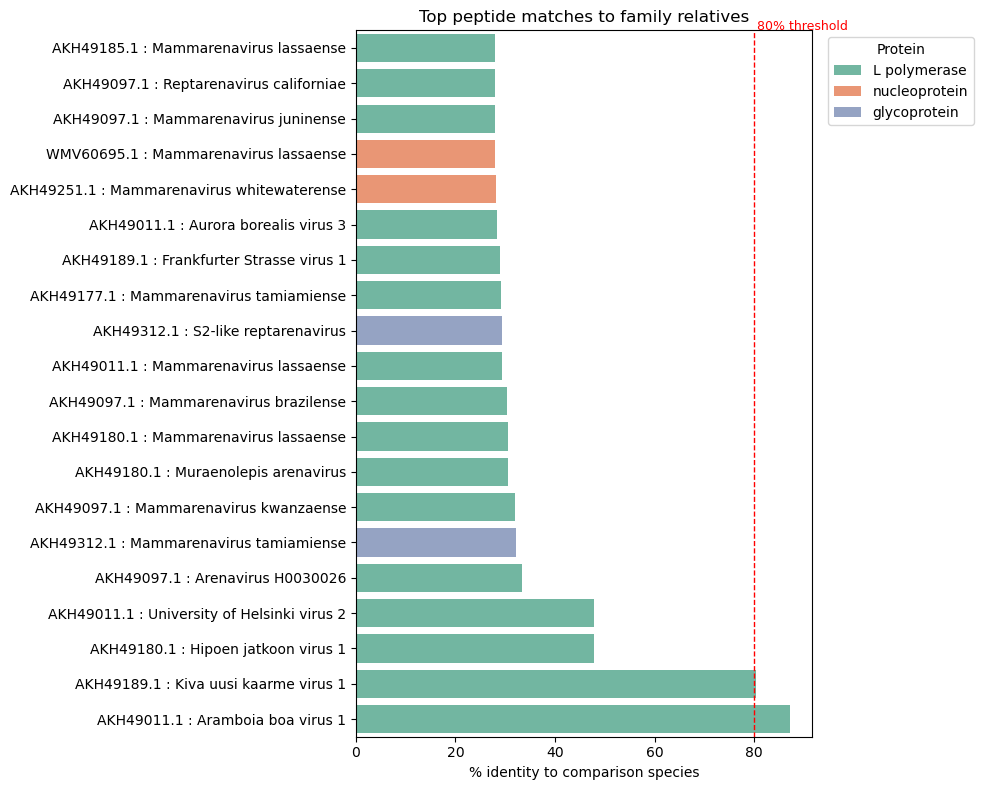

In [102]:
peptide_protein_map = long.drop_duplicates('peptide').set_index('peptide')['protein_name']
peptide_species_map = long.drop_duplicates('peptide').set_index('peptide')['species']

top_matches['protein_name'] = top_matches['target_peptide'].map(peptide_protein_map)
top_matches['target_species'] = top_matches['target_peptide'].map(peptide_species_map)

plot_df = top_matches.head(20).copy()
plot_df['label'] = plot_df['target_peptide'].str.split('|').str[0] + ' : ' + plot_df['comparison_species']

plt.figure(figsize=(10, 8))
sns.barplot(
    data=plot_df.sort_values('pct_identity', ascending=True),
    x='pct_identity', y='label', hue='protein_name', dodge=False,
    palette='Set2',
)
plt.axvline(80, color='red', linestyle='--', linewidth=1)
plt.text(80.5, -0.5, '80% threshold', color='red', fontsize=9)
plt.xlabel('% identity to comparison species')
plt.ylabel('')
plt.title(f'Top peptide matches to family relatives')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title='Protein')
plt.tight_layout()
plt.show()

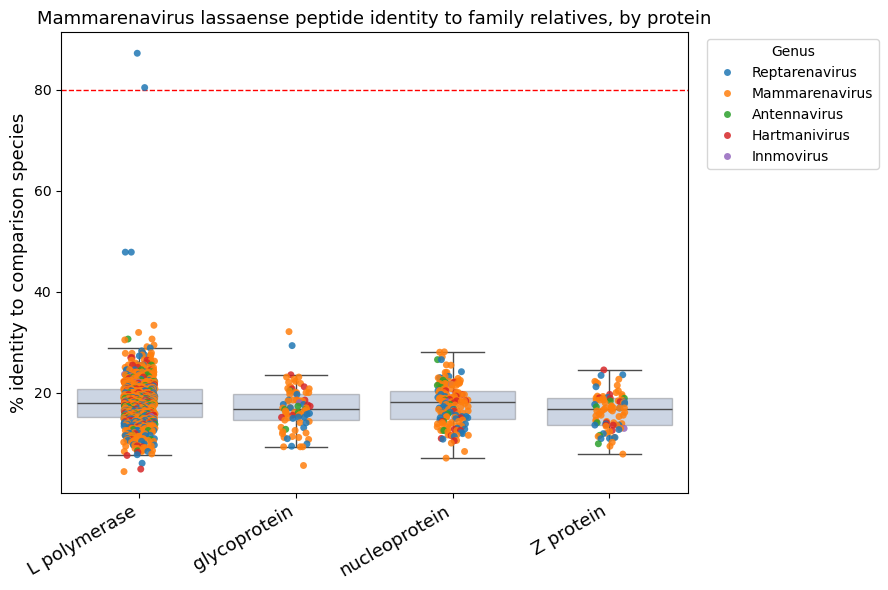

In [103]:
species_to_genus = long.drop_duplicates('species').set_index('species')['genus']
top_matches['comparison_genus'] = top_matches['comparison_species'].map(species_to_genus)

plt.figure(figsize=(9, 6))
sns.boxplot(
    data=top_matches, x='protein_name', y='pct_identity',
    color='#4C72B0', fliersize=0, boxprops=dict(alpha=0.3),
)
sns.stripplot(
    data=top_matches, x='protein_name', y='pct_identity',
    hue='comparison_genus', palette='tab10', size=5, alpha=0.85,
)
plt.axhline(80, color='red', linestyle='--', linewidth=1)
plt.xticks(rotation=30, ha='right', fontsize=13)
plt.ylabel('% identity to comparison species', fontsize=13)
plt.xlabel('')
plt.title('Mammarenavirus lassaense peptide identity to family relatives, by protein', fontsize=13)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title='Genus')
plt.tight_layout()
plt.show()

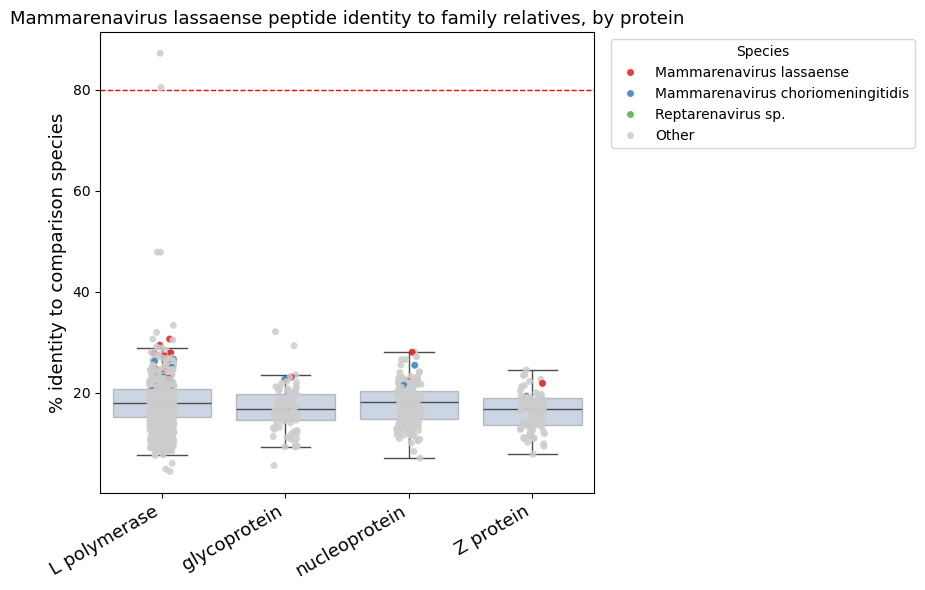

In [104]:
species_of_interest = [
    'Mammarenavirus lassaense',
    'Mammarenavirus choriomeningitidis',
    'Reptarenavirus sp.',
    # add your third species here
]

top_matches['species_highlight'] = top_matches['comparison_species'].where(
    top_matches['comparison_species'].isin(species_of_interest), 'Other'
)

palette = dict(zip(species_of_interest, sns.color_palette('Set1', n_colors=len(species_of_interest))))
palette['Other'] = '#cccccc'

plt.figure(figsize=(9, 6))
sns.boxplot(
    data=top_matches, x='protein_name', y='pct_identity',
    color='#4C72B0', fliersize=0, boxprops=dict(alpha=0.3),
)
sns.stripplot(
    data=top_matches, x='protein_name', y='pct_identity',
    hue='species_highlight', hue_order=species_of_interest + ['Other'],
    palette=palette, size=5, alpha=0.85,
)
plt.axhline(80, color='red', linestyle='--', linewidth=1)
plt.xticks(rotation=30, ha='right', fontsize=13)
plt.ylabel('% identity to comparison species', fontsize=13)
plt.xlabel('')
plt.title('Mammarenavirus lassaense peptide identity to family relatives, by protein', fontsize=13)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title='Species')
plt.tight_layout()
plt.show()

In [105]:
top_matches

,target_peptide,comparison_species,pct_identity,protein_name,target_species,comparison_genus,species_highlight
89,AKH49011.1|polymerase|unidentified_Reptarenavi...,Aramboia boa virus 1,87.234043,L polymerase,Reptarenavirus sp.,Reptarenavirus,Other
948,AKH49189.1|polymerase|unidentified_Reptarenavi...,Kiva uusi kaarme virus 1,80.434783,L polymerase,Reptarenavirus sp.,Reptarenavirus,Other
80,AKH49011.1|polymerase|unidentified_Reptarenavi...,University of Helsinki virus 2,47.826087,L polymerase,Reptarenavirus sp.,Reptarenavirus,Other
610,AKH49180.1|polymerase|unidentified_Reptarenavi...,Hipoen jatkoon virus 1,47.826087,L polymerase,Reptarenavirus sp.,Reptarenavirus,Other
258,AKH49097.1|polymerase|unidentified_Reptarenavi...,Arenavirus H0030026,33.333333,L polymerase,Reptarenavirus sp.,Mammarenavirus,Other
...,...,...,...,...,...,...,...
1229,WMV60695.1|nucleoprotein|Reptarenavirus_sp.|RI...,Mammarenavirus okahandjaense,7.017544,nucleoprotein,Reptarenavirus sp.,Mammarenavirus,Other
11,AKH49011.1|polymerase|unidentified_Reptarenavi...,Frankfurter Strasse virus 1,6.000000,L polymerase,Reptarenavirus sp.,Reptarenavirus,Other
1119,AKH49312.1|glycoprotein|unidentified_Reptarena...,Mammarenavirus allpahuayoense,5.555556,glycoprotein,Reptarenavirus sp.,Mammarenavirus,Other
600,AKH49180.1|polymerase|unidentified_Reptarenavi...,Hartmanivirus brazilense,4.838710,L polymerase,Reptarenavirus sp.,Hartmanivirus,Other


In [106]:
species_summary.max().sort_values(ascending=False)

comparison_species
Aramboia boa virus 1              87.234043
Kiva uusi kaarme virus 1          80.434783
Hipoen jatkoon virus 1            47.826087
University of Helsinki virus 2    47.826087
Arenavirus H0030026               33.333333
                                    ...    
Antennavirus salmonis             20.338983
Mammarenavirus AnRB3214           20.000000
Mafiga mammarenavirus             20.000000
Yunnan shrew mammarenavirus 1     20.000000
Hartmanivirus helvetiae           19.607843
Length: 84, dtype: float64

In [ ]:
# pip install biopython  (if not already installed)
from Bio.Align import PairwiseAligner, substitution_matrices
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

TARGET_SPECIES = 'Cuevavirus lloviuense'   # the "suspicious" non-local species
COMPARISON_RANK = 'family'                    # 'family' (broader) or 'genus' (narrower, faster)

aligner = PairwiseAligner()
aligner.substitution_matrix = substitution_matrices.load("BLOSUM62")
aligner.mode = 'global'
aligner.open_gap_score = -10
aligner.extend_gap_score = -0.5

def percent_identity(seq1, seq2):
    alignment = aligner.align(seq1, seq2)[0]
    s1, s2 = str(alignment[0]), str(alignment[1])
    matches = sum(a == b and a != '-' for a, b in zip(s1, s2))
    return 100 * matches / len(s1)

# --- peptide sets ---
target_family = long.loc[long['species'] == TARGET_SPECIES, COMPARISON_RANK].iloc[0]

target_peptides = (
    long[(long['species'] == TARGET_SPECIES) & (long['pass_z_3'])]
    [['peptide', 'sequence']]
    .drop_duplicates('peptide')
)

comparison_peptides = (
    long[(long[COMPARISON_RANK] == target_family) & (long['species'] != TARGET_SPECIES)]
    [['peptide', 'sequence', 'species']]
    .drop_duplicates('peptide')
)

print(f"{len(target_peptides)} target peptides x {len(comparison_peptides)} comparison peptides "
      f"= {len(target_peptides) * len(comparison_peptides)} alignments")
records = []
for _, t in target_peptides.iterrows():
    for _, c in comparison_peptides.iterrows():
        records.append({
            'target_peptide': t['peptide'],
            'comparison_peptide': c['peptide'],
            'comparison_species': c['species'],
            'pct_identity': percent_identity(t['sequence'], c['sequence']),
        })

identity_long = pd.DataFrame(records)

species_summary = (
    identity_long.groupby(['target_peptide', 'comparison_species'])['pct_identity']
    .max()
    .reset_index()
    .pivot(index='target_peptide', columns='comparison_species', values='pct_identity')
)

6 target peptides x 40 comparison peptides = 240 alignments


In [ ]:
species_summary

comparison_species,Bat filovirus,Dianlovirus menglaense,Orthoebolavirus bombaliense,Orthoebolavirus bundibugyoense,Orthoebolavirus restonense,Orthoebolavirus sudanense,Orthoebolavirus taiense,Orthoebolavirus zairense,Orthomarburgvirus marburgense,Striavirus antennarii,Tapjovirus bothropis,Thamnovirus thamnaconi
target_peptide,,,,,,,,,,,,
WJL97488.1|nucleoprotein|Cuevavirus_lloviuense|isolate=Hungary/2019/378|Miniopterus_schreibersii|Hungary|24-Sep-2019|segment=?|strain=?|tile_15,16.666667,20.000000,22.448980,6.896552,16.363636,19.607843,18.750000,18.867925,17.647059,21.818182,24.528302,16.071429
WJL97488.1|nucleoprotein|Cuevavirus_lloviuense|isolate=Hungary/2019/378|Miniopterus_schreibersii|Hungary|24-Sep-2019|segment=?|strain=?|tile_18,20.754717,17.857143,10.526316,14.035088,18.367347,20.408163,20.370370,17.307692,25.000000,18.333333,15.094340,20.833333
WJL97488.1|nucleoprotein|Cuevavirus_lloviuense|isolate=Hungary/2019/378|Miniopterus_schreibersii|Hungary|24-Sep-2019|segment=?|strain=?|tile_21,18.644068,12.500000,14.035088,20.000000,16.129032,19.607843,20.000000,16.363636,19.642857,18.367347,21.568627,24.489796
WJL97488.1|nucleoprotein|Cuevavirus_lloviuense|isolate=Hungary/2019/378|Miniopterus_schreibersii|Hungary|24-Sep-2019|segment=?|strain=?|tile_26,19.230769,22.222222,15.517241,13.114754,20.000000,25.000000,16.071429,20.754717,22.448980,21.818182,19.298246,21.568627
WJL97491.1|GP1|Cuevavirus_lloviuense|isolate=Hungary/2019/378|Miniopterus_schreibersii|Hungary|24-Sep-2019|segment=?|strain=?|tile_9,17.647059,14.000000,11.666667,12.307692,15.384615,19.230769,15.384615,16.000000,14.754098,19.230769,23.529412,18.518519
WJL97492.1|GP2|Cuevavirus_lloviuense|isolate=Hungary/2019/378|Miniopterus_schreibersii|Hungary|24-Sep-2019|segment=?|strain=?|tile_6,24.489796,21.568627,13.207547,11.764706,20.000000,19.607843,17.647059,21.311475,21.818182,17.857143,15.217391,15.384615


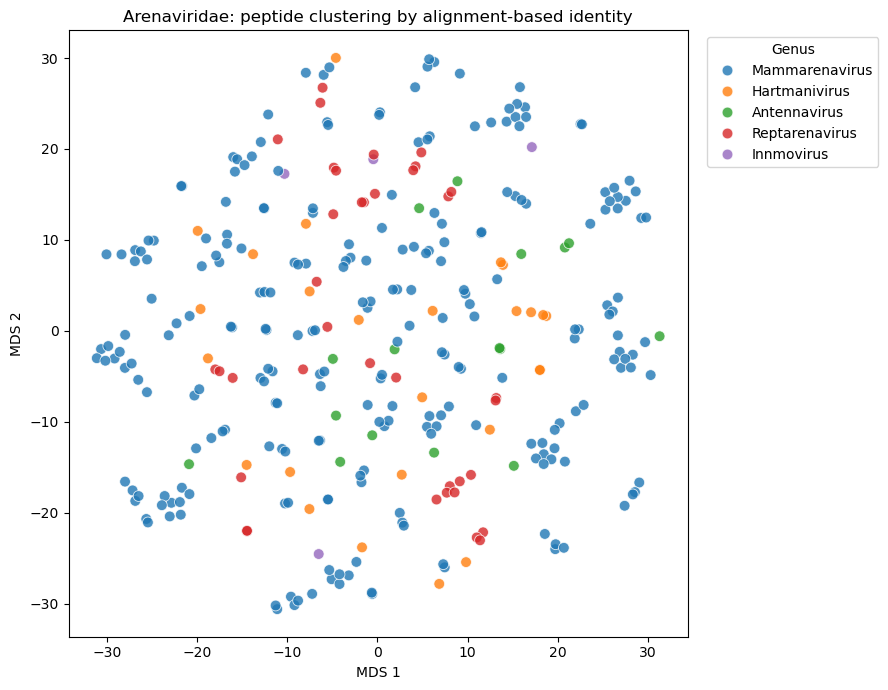

In [ ]:
from sklearn.manifold import MDS
import numpy as np

TARGET_FAMILY = 'Mammarenavirus'

family_peptides = (
    long[(long['family'] == TARGET_FAMILY)]
    [['peptide', 'sequence', 'species', 'genus']]
    .drop_duplicates('peptide')
    .reset_index(drop=True)
)

peptides = family_peptides['sequence'].tolist()
n = len(peptides)
dist_matrix = np.zeros((n, n))
for i in range(n):
    for j in range(i + 1, n):
        d = 100 - percent_identity(peptides[i], peptides[j])
        dist_matrix[i, j] = dist_matrix[j, i] = d

from sklearn.manifold import TSNE

coords = TSNE(
    n_components=2, metric='precomputed', init='random',
    perplexity=15, random_state=42,
).fit_transform(dist_matrix)

family_peptides['TSNE1'], family_peptides['TSNE2'] = coords[:, 0], coords[:, 1]

plt.figure(figsize=(9, 7))
sns.scatterplot(data=family_peptides, x='TSNE1', y='TSNE2', hue='genus', palette='tab10', s=60, alpha=0.8)
plt.title(f'{TARGET_FAMILY}: peptide clustering by alignment-based identity')
plt.xlabel('MDS 1'); plt.ylabel('MDS 2')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title='Genus')
plt.tight_layout()
plt.show()

### let's try a motif search approach. so each peptide gets represented as a vector of a short amino acid motif (k-mer) counts, then PCA that feature space. Peptides sharing motifs end up in similar vectors and cluster together geometrically. So there is no alignment needed. 

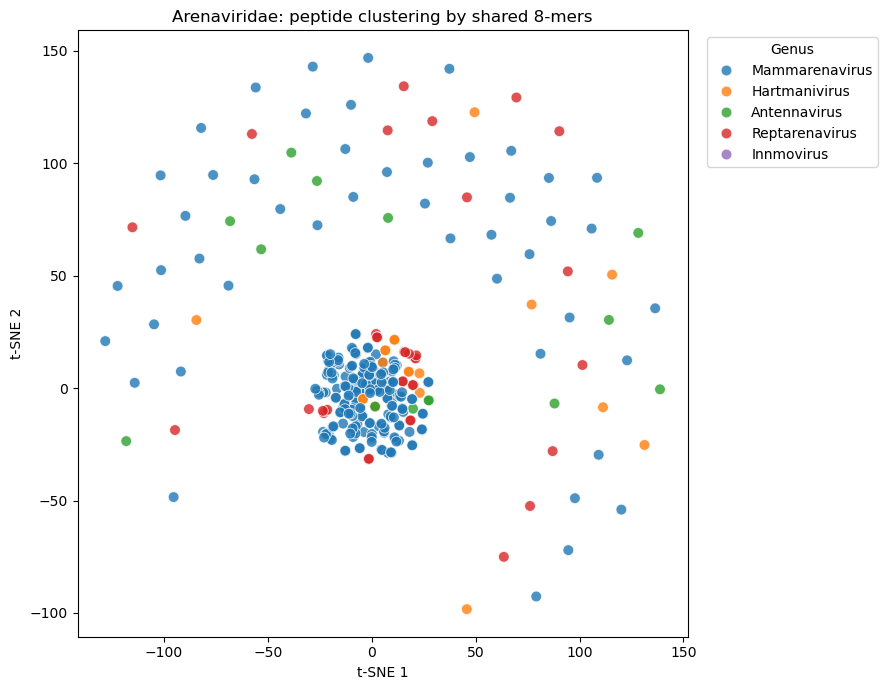

In [108]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns

TARGET_FAMILY = 'Arenaviridae'
KMER_SIZE = 8

family_peptides = (
    long[(long['family'] == TARGET_FAMILY)]
    [['peptide', 'sequence', 'species', 'genus']]
    .drop_duplicates('peptide')
    .reset_index(drop=True)
)

vectorizer = CountVectorizer(analyzer='char', ngram_range=(KMER_SIZE, KMER_SIZE))
kmer_matrix = vectorizer.fit_transform(family_peptides['sequence'])

coords = TSNE(n_components=2, perplexity=30, random_state=42).fit_transform(kmer_matrix.toarray())
family_peptides['TSNE1'], family_peptides['TSNE2'] = coords[:, 0], coords[:, 1]

plt.figure(figsize=(9, 7))
sns.scatterplot(data=family_peptides, x='TSNE1', y='TSNE2', hue='genus', palette='tab10', s=60, alpha=0.8)
plt.title(f'{TARGET_FAMILY}: peptide clustering by shared {KMER_SIZE}-mers')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title='Genus')
plt.tight_layout()
plt.show()

In [110]:
kmer_matrix 

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 12870 stored elements and shape (330, 11038)>

In [109]:
xmin, xmax = -50, 50
ymin, ymax = -50, 50

family_peptides[
    family_peptides['TSNE1'].between(xmin, xmax) & 
    family_peptides['TSNE2'].between(ymin, ymax)].head(50)


,peptide,sequence,species,genus,TSNE1,TSNE2
0,XQN14281.1|polymerase|Rodent_Mammarenavirus|FK...,MYEYDLSSGFSWVDLDVKPSIITAAELTRLKITEAGVFDDFWDLWN,Rodent mammarenavirus,Mammarenavirus,-12.572873,5.141205
1,XQN12076.1|polymerase|Mammarenavirus_lassaense...,IEGQFLKVDKSQLLNELNNLYADKVVAEDNIEHLIYQFKRASPILR,Mammarenavirus lassaense,Mammarenavirus,9.796085,7.462974
2,XQN12074.1|precursor|Mammarenavirus_juninense|...,EFCDMLRLFDYNKNAIKTLNDETKKQVNLMGQTINALISDNLLMKN,Mammarenavirus juninense,Mammarenavirus,0.842109,8.168827
3,XQN12073.1|polymerase|Mammarenavirus_juninense...,SEGTKVEITKLKSKNPSVDERESLESLWAPFGVLREIKAEVSMHEV,Mammarenavirus juninense,Mammarenavirus,-13.805337,-15.791900
4,XQN12073.1|polymerase|Mammarenavirus_juninense...,KSYFTNAALRNLCFYSDDSPTEFTSISSNTGNLKFGLSYKEQVGSN,Mammarenavirus juninense,Mammarenavirus,-4.018549,2.061168
5,XOB76281.1|glycoprotein|Mammarenavirus_wenzhou...,LNNTRSNRTSLPRCWLVSNGSYLNETEFSSDIEQEANNLITEMLQR,Mammarenavirus wenzhouense,Mammarenavirus,11.214885,-3.905783
6,XOB76282.1|nucleoprotein|Mammarenavirus_wenzho...,QQQKNVLSVGQLSSDDLLILAADIDRLKAKITRTERPQSNGVYMGN,Mammarenavirus wenzhouense,Mammarenavirus,-4.304807,-12.442986
7,XOB76264.1|protein|Mammarenavirus_wenzhouense|...,SETKSHDPQPHQASLSDLNEFISDPVKQRLIMSELSTHMVEDFDPN,Mammarenavirus wenzhouense,Mammarenavirus,5.330133,11.396380
8,XOB76262.1|polymerase|Yunnan_shrew_mammarenavi...,IAKRTLSLIDYSQYPRNPWLINTSTDCKDWIDGSRGYRLQRNFERL,Yunnan shrew mammarenavirus 1,Mammarenavirus,1.638890,-8.202528
9,XNW50214.1|nucleoprotein|Mecsek_Mountains_viru...,LSADLERLKNKVIRSEGQSAGVYQGNLSSTQLDQRSKLLQSIGMTN,Mammarenavirus mecsekense,Mammarenavirus,8.738544,2.917510


In [ ]:
from sklearn.cluster import DBSCAN
import pandas as pd

# 1. assign cluster labels on the t-SNE coordinates
clustering = DBSCAN(eps=3, min_samples=5).fit(family_peptides[['TSNE1', 'TSNE2']].values)
family_peptides['cluster'] = clustering.labels_
print(family_peptides['cluster'].value_counts())

# 2. pick the cluster you're interested in and find its enriched motifs
target_cluster = 0  # set to whichever label is your cluster of interest

in_cluster_mask = (family_peptides['cluster'] == target_cluster).values
kmer_names = vectorizer.get_feature_names_out()
kmer_df = pd.DataFrame(kmer_matrix.toarray(), columns=kmer_names, index=family_peptides['peptide'])

enrichment = pd.DataFrame({
    'kmer': kmer_names,
    'mean_in_cluster': kmer_df[in_cluster_mask].mean().values,
    'mean_outside': kmer_df[~in_cluster_mask].mean().values,
})
enrichment['enrichment'] = enrichment['mean_in_cluster'] - enrichment['mean_outside']
top_motifs = enrichment.sort_values('enrichment', ascending=False).head(5)
print(top_motifs)

# 3. for each top motif, find exactly which peptides (and species/genus) carry it
for _, row in top_motifs.iterrows():
    motif = row['kmer']
    carriers = family_peptides[family_peptides['sequence'].str.contains(motif, regex=False)]
    print(f"\nMotif: {motif}  (enrichment={row['enrichment']:.3f}, n_peptides={len(carriers)})")
    print(carriers[['peptide', 'species', 'genus']].to_string(index=False))

In [ ]:
from sklearn.cluster import DBSCAN

coords_2d = family_peptides[['PC1', 'PC2']].values  # or your t-SNE column names
clustering = DBSCAN(eps=3, min_samples=5).fit(coords_2d)  # tune eps to your coordinate scale
family_peptides['cluster'] = clustering.labels_

family_peptides['cluster'].value_counts()  # check which label is "your" cluster

cluster
-1     231
 1      34
 2       8
 4       8
 7       7
 0       6
 8       6
 3       6
 11      6
 5       6
 6       6
 9       6
 10      5
Name: count, dtype: int64

In [ ]:
target_cluster = 0  # whichever label is your cluster of interest

in_cluster_mask = (family_peptides['cluster'] == target_cluster).values
kmer_names = vectorizer.get_feature_names_out()
kmer_df = pd.DataFrame(kmer_matrix.toarray(), columns=kmer_names)

enrichment = pd.DataFrame({
    'kmer': kmer_names,
    'mean_in_cluster': kmer_df[in_cluster_mask].mean().values,
    'mean_outside': kmer_df[~in_cluster_mask].mean().values,
})
enrichment['enrichment'] = enrichment['mean_in_cluster'] - enrichment['mean_outside']

top_motifs = enrichment.sort_values('enrichment', ascending=False).head(15)
print(top_motifs)

           kmer  mean_in_cluster  mean_outside  enrichment
6699   ngsylnet         1.000000       0.00304    0.996960
9164   sngsylne         0.833333       0.00304    0.830294
3321   gsylneth         0.833333       0.00304    0.830294
9513   sylnethf         0.833333       0.00304    0.830294
10676  vsngsyln         0.666667       0.00000    0.666667
11049  ylnethfs         0.666667       0.00304    0.663627
2112   eqeannmi         0.500000       0.00000    0.500000
6236   lvsngsyl         0.500000       0.00000    0.500000
3796   ieqeannm         0.500000       0.00000    0.500000
10824  wlvsngsy         0.500000       0.00000    0.500000
631    cwlvsngs         0.500000       0.00304    0.496960
9736   thfsdeie         0.333333       0.00000    0.333333
8621   sdeieqea         0.333333       0.00000    0.333333
3469   hfsdeieq         0.333333       0.00000    0.333333
2748   fssdieqe         0.333333       0.00000    0.333333


In [ ]:
family_peptides

,peptide,sequence,species,genus,PC1,PC2,cluster
0,XQN14281.1|polymerase|Rodent_Mammarenavirus|FK...,MYEYDLSSGFSWVDLDVKPSIITAAELTRLKITEAGVFDDFWDLWN,Rodent mammarenavirus,Mammarenavirus,18.428062,-4.095882,-1
1,XQN12076.1|polymerase|Mammarenavirus_lassaense...,IEGQFLKVDKSQLLNELNNLYADKVVAEDNIEHLIYQFKRASPILR,Mammarenavirus lassaense,Mammarenavirus,14.730227,5.651274,0
2,XQN12074.1|precursor|Mammarenavirus_juninense|...,FVFLALAGRSCTEEAFKIGLHTEFQTVSFSMVGLFSNNPHDLPLLC,Mammarenavirus juninense,Mammarenavirus,21.376190,-6.645231,-1
3,XQN12074.1|precursor|Mammarenavirus_juninense|...,EFCDMLRLFDYNKNAIKTLNDETKKQVNLMGQTINALISDNLLMKN,Mammarenavirus juninense,Mammarenavirus,-15.513062,4.521062,1
4,XQN12073.1|polymerase|Mammarenavirus_juninense...,SEGTKVEITKLKSKNPSVDERESLESLWAPFGVLREIKAEVSMHEV,Mammarenavirus juninense,Mammarenavirus,6.123271,-8.957524,9
...,...,...,...,...,...,...,...
330,ABC71135.1|protein|Mammarenavirus_mopeiaense|?...,SQTMELKDCMLQLDPNAKTWIDIEGRADDPVEVAIYQPNNGQYIHF,Mammarenavirus mopeiaense,Mammarenavirus,12.536325,14.593413,22
331,ABW96603.1|protein|North_American_arenavirus|?...,LSKDELMELSSDLEKLKQKVQRSERVGNVPGQYQGNLSSTQLTRRS,Mammarenavirus whitewaterense,Mammarenavirus,-11.069717,24.127645,16
332,ABW96601.1|protein|North_American_arenavirus|?...,LSKDELMELSSDLEKLRQKVQRTERLGNTTGQYQGNLSSTQLTRRS,Mammarenavirus whitewaterense,Mammarenavirus,-11.742753,23.914152,16
333,ABW96599.1|protein|North_American_arenavirus|?...,AKYPNLTDLKVLTEKHPSLKIITQEESQVNISGYNLSLSAAVKAGA,Mammarenavirus whitewaterense,Mammarenavirus,19.514589,-22.215858,20


In [ ]:
tier_palette = {
    'High confidence (species-specific)': '#2ca02c',
    'Moderate (internal protein, low homology)': '#ff7f0e',
    'Low confidence (likely cross-reactive)': '#d62728',
}
species_tier_map = specificity.set_index('species')['specificity_tier']

species_tier_colors = species_order.map(species_tier_map).map(tier_palette)
species_tier_colors.index = species_order
species_tier_colors.name = 'Specificity'

g = sns.clustermap(
    pivot_t,
    mask=mask,
    row_colors=pd.concat([species_row_colors, species_tier_colors], axis=1),  # Family + Specificity, stacked
    col_colors=col_colors_named,
    # ...rest unchanged
)

NameError: name 'specificity' is not defined

### making a peptide-level summary lookup table separate from master, which is taxon - level 
includes a fast sequence lookup and a plotting helper, all built off long since it already has everything we need (peptide, taxonomy, category, rpk, pass_z_3)

In [ ]:
def peptide_lookup_table(taxon_value, level='species', cohort=None, min_prevalence=0.00):
    subset = long[long[level] == taxon_value]
    if cohort is not None: 
        subset = subset[subset['cohort'] == cohort]
    

    stats = (
        subset.groupby('peptide', observed=True)
        .agg(
            n_individuals=('individual', 'nunique'), 
            n_hits=('pass_z_3', 'sum'), 
            mean_rpk=('rpk', 'mean'), 
            median_rpk=('rpk', 'median'), 
            sum_rpk=('rpk', 'sum'), 
            max_rpk=('rpk', 'max')
        )
        .reset_index()
    )
    stats['prevalence'] = stats['n_hits'] / stats['n_individuals']

    # static per-peptide metadata (one row per peptide, safe to merge back in)
    meta = subset.drop_duplicates('peptide')[
        ['peptide', 'sequence', 'protein_name', 'species', 'genus', 'family']
    ]
    stats = stats.merge(meta, on='peptide', how='left')

    return stats[stats['prevalence'] >= min_prevalence]

### helper code to identify top and bottom responders for peptides

In [ ]:
def top_bottom_individuals_per_peptide(peptide_ids, long_df=long, n=40):
    rows = []
    for peptide in peptide_ids:
        subset = long_df[long_df['peptide'] == peptide][
            ['peptide', 'individual', 'category', 'rpk', 'pass_z_3']
        ].sort_values('rpk', ascending=False)

        top = subset.head(n).copy()
        top['rank_group'] = 'top'

        bottom = subset.tail(n).sort_values('rpk', ascending=True).copy()
        bottom['rank_group'] = 'bottom'

        rows.append(pd.concat([top, bottom]))

    return pd.concat(rows, ignore_index=True)

In [ ]:
top_taxa.values

array(['Mammarenavirus lassaense', 'Orthonairovirus haemorrhagiae',
       'Orthoflavivirus denguei', 'Nairoviridae sp.',
       'Mammarenavirus choriomeningitidis', 'Phlebovirus candiruense',
       'Phlebovirus ambeense', 'Orthoflavivirus zikaense',
       'Morbillivirus hominis', 'Henipavirus sp.', 'Hantaviridae sp.',
       'Orthomarburgvirus marburgense', 'Cuevavirus lloviuense',
       'Orthohantavirus hantanense'], dtype=object)

In [ ]:
table = peptide_lookup_table('Cuevavirus lloviuense', level='species', cohort='SL')

most_reactive = table.sort_values('mean_rpk', ascending=False).head(20)
most_shared   = table[table['prevalence'] >= 0.05].sort_values('prevalence', ascending=False).head(20)

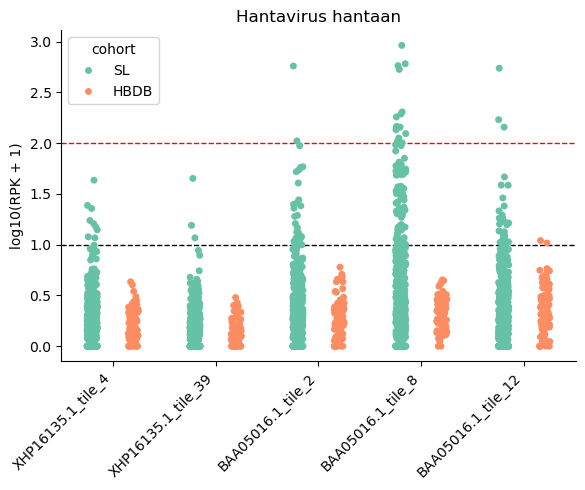

In [ ]:
table = peptide_lookup_table('Orthohantavirus hantanense', level='species', cohort='SL')

most_reactive = table.sort_values('mean_rpk', ascending=False).head(20)
most_shared   = table[table['prevalence'] >= 0.05].sort_values('prevalence', ascending=False).head(20)

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

def plot_peptides(peptide_ids, long_df=long, hue='cohort', species=''):
    plot_df = long_df[long_df['peptide'].isin(peptide_ids)].copy()
    parts = plot_df['peptide'].str.split('|')
    plot_df['peptide_label'] = parts.str[0] + '_' + parts.str[-1]
    plot_df['log_rpk'] = np.log10(plot_df['rpk'] + 1)

    fig, ax = plt.subplots(figsize=(max(6, 0.5 * len(peptide_ids)), 5))
    sns.stripplot(
        data=plot_df, x='peptide_label', y='log_rpk', hue=hue,
        dodge=True, jitter=True, palette='Set2', ax=ax,
    )
    ax.set_xlabel('')
    ax.set_ylabel('log10(RPK + 1)')
    plt.xticks(rotation=45, ha='right')
    plt.title(species)
    sns.despine()
    plt.tight_layout()
    ax.axhline(y=1, color='black', linestyle='--', linewidth=1)
    ax.axhline(y=2, color='red', linestyle='--', linewidth=1)
    plt.show()

plot_peptides(most_shared['peptide'], species='Hantavirus hantaan')

,peptide,sequence
0,AHC95546.1|polymerase|Mammarenavirus_lassaense...,TDDAVVAEDDIEQLIYQFKRASPILRFLYSDIEGEEDRKNVQVVKE
1,AHC95546.1|polymerase|Mammarenavirus_lassaense...,RESTSRSITEDFFYSNYQNGVVPSHISSVLDMGQGILHNTSDFYAL
2,AHC95546.1|polymerase|Mammarenavirus_lassaense...,LRQKVIYSGAVNLDDDKIPTIVKTIQNKLSSTFTRGAQKLLSEAIN
3,AIT17175.1|polymerase|Mammarenavirus_lassaense...,RLCESLSMTSGRLSGVESLNVLLDNRSNHYEEVITSCHQGINNKLT
4,AIT17179.1|polymerase|Mammarenavirus_lassaense...,SFDVSGVIPTITYQRSEEEKFPYVTGDVELLRTTDLERLSSLSLAL
...,...,...
71,WKK95338.1|nucleoprotein|Mammarenavirus_lassae...,KAGSNGSNKSLQSAGFTAGLTYSQLMTLKDAMLQLDPNAKTWMDIE
72,WNI01985.1|nucleoprotein|Mammarenavirus_lassae...,KVGTAGSNKSLQSAGFPTGLTYSQLMTLKDSMMQLDPSAKTWIDIE
73,WPS90786.1|polymerase|Mammarenavirus_lassaense...,DNRSSHYEEIIASCHQGINNKLTAHEVKLQIEEEYQVFRNRLRKGE
74,WPS90786.1|polymerase|Mammarenavirus_lassaense...,VLEAVDDWVDFKGYALCYSKSRKKVMVHSSGGKLRLKGRTCEELVK


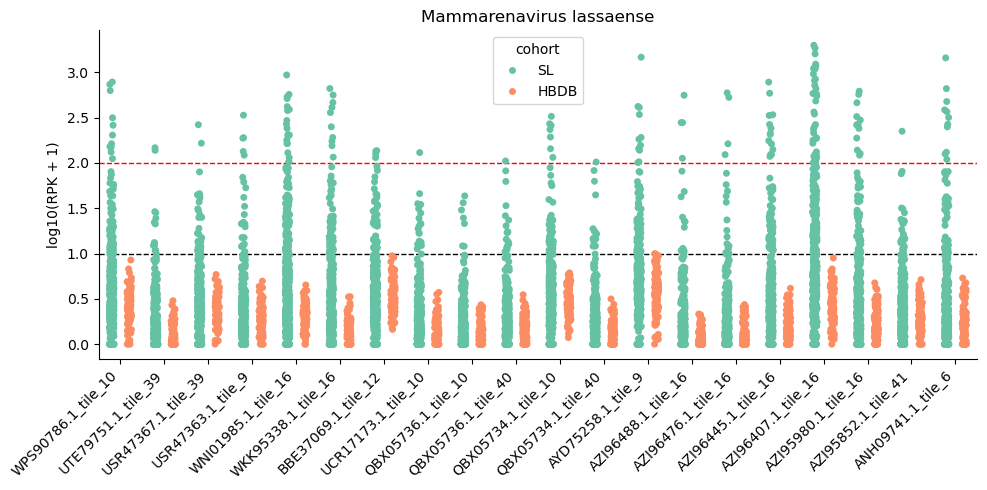

,peptide,sequence
0,ADV31331.1|precursor|Orthonairovirus_haemorrha...,TPTSETEGSGEATPLSNTIQAPSSPETTSERPATAVISTSGTDSTN
1,APG38028.1|precursor|Orthonairovirus_haemorrha...,DEASTLTDPKEASTEARSPSPSISRTPTPSPTVQASTENNTPSTPR
2,APG38067.1|precursor|Orthonairovirus_haemorrha...,AQTMQGQQAIVPVTTPVTTTFTPTNPTNRSKRESKVQIILTFPQGL
3,ARB18229.1|precursor|Orthonairovirus_haemorrha...,LVTNCVIKGREVRKGQSVLRQYRTEIRIGKASSGSRRLLSEESGED
4,ARB18229.1|precursor|Orthonairovirus_haemorrha...,CISRTQLLRTETAEIHGDNYGGPGDKITICNGSTIVDQRLGSELGC
5,ARB18229.1|precursor|Orthonairovirus_haemorrha...,EDASESKLLTVSVMDLSQMYSPVFEYLSGDRQVEEWPKATCTGDCP
6,ARB18229.1|precursor|Orthonairovirus_haemorrha...,EVPTPTGPEQASIETNSPRLATSKTPSPSPTAQVTTENSNPNTSRQ
7,ARB51458.1|precursor|Orthonairovirus_haemorrha...,TVCKLQSCTHGVAGDLQVYHVGNLLKGDKINGHSIHKIEPHLNTSW
8,ARB51458.1|precursor|Orthonairovirus_haemorrha...,DSSSSPLATQGARSPARNLLSVPSVEPGQQTTPKQPTTKGTVTPTT
9,ARB51458.1|precursor|Orthonairovirus_haemorrha...,PQPTTSSPTPAPTSATLSTNSSSISTPVQTSSPLQPMAPSHETQHA


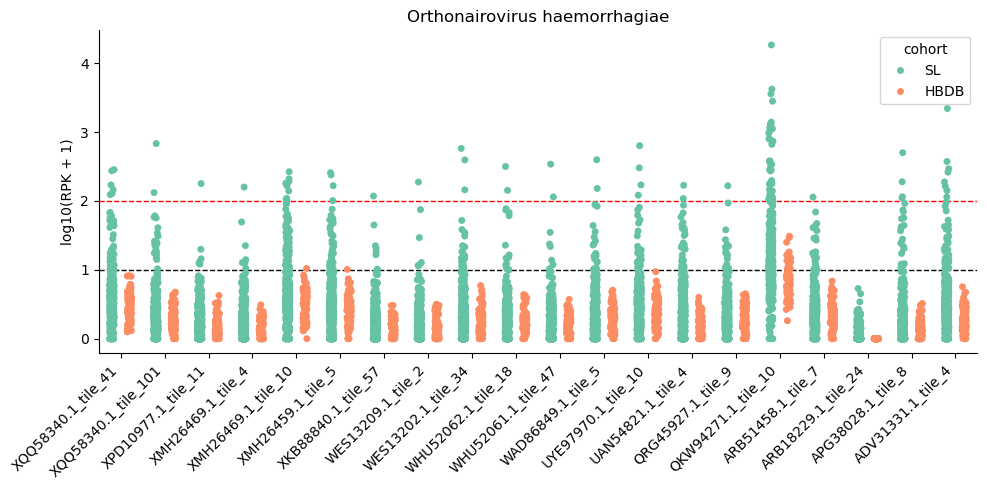

,peptide,sequence
0,AFZ40120.1|polyprotein|dengue_virus_type_2|iso...,LRLREKQDVFCDSKLMSAAIKDNRAVHADMGYWIESALNDTWKIEK
1,AFZ40123.1|polyprotein|dengue_virus_type_2|iso...,SRPPWAKNFQPAINQVRSLLCNEESADFMPSMKRFRREEEEAGVLW
2,AFZ40123.1|polyprotein|dengue_virus_type_2|iso...,ESEMVIPKNFAGPVSQHNNRPGYYTQTAGPWHLGKLEMDFDFCEGT
3,AFZ40123.1|polyprotein|dengue_virus_type_2|iso...,GSPIVDKKGKVVGLYGNGVVTRSGAYVSAIAQTEKSIEDYPEVEMD
4,AMN88556.1|polyprotein|Dengue_virus|isolate=Br...,NMEAQLIRQMESEGVFSPSELETPNLANRVLDWLEKYGVERLKRMA
5,AMN88556.1|polyprotein|Dengue_virus|isolate=Br...,LKYSVIVTVHTGDQHQVGNETTGHGTTATITPQAPTSEIQLTDYGA
6,AMN88556.1|polyprotein|Dengue_virus|isolate=Br...,GMSYVMCTGSFKLKKEVAETQHGTVLVQVEYEGTDAPCKIPFTTQD
7,AMN88556.1|polyprotein|Dengue_virus|isolate=Br...,TVLVQVEYEGTDAPCKIPFTTQDEKGVIQNGRLITANPIVTDKEKP
8,AMN88556.1|polyprotein|Dengue_virus|isolate=Br...,GSPIVNRDGKVVGLYGNGVVTTSGTYVSAIAQSKVSQEGPLPEIED
9,AMN88556.1|polyprotein|Dengue_virus|isolate=Br...,ARGYISTRVGMGEAAAIFMTATPPGSAEAFPQSNSVIYDEEKDIPE


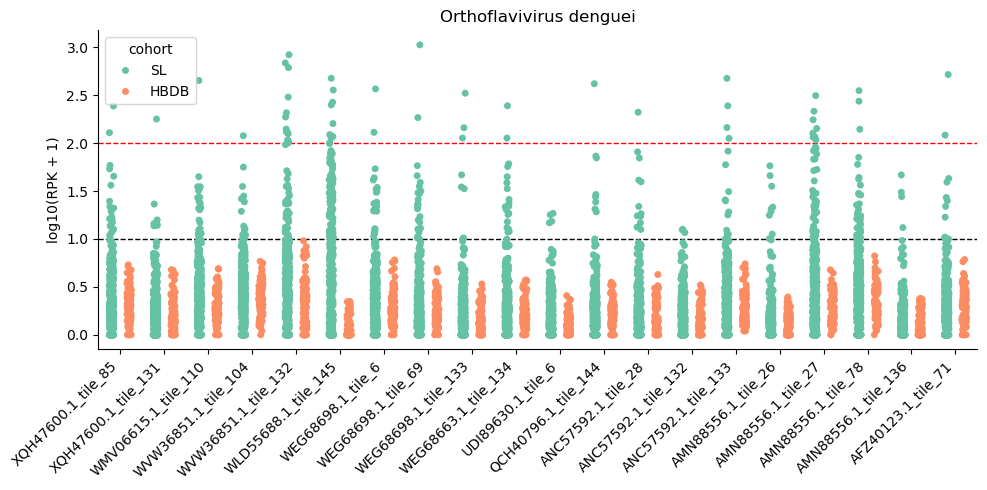

,peptide,sequence
0,BDE11111.1|protein|Nairoviridae_sp.|isolate=?|...,LGMIDLSDPSKVQKQINELRMVNEVEMLKKKAVAEEKERLKLAKAK
1,BDE11116.1|precursor|Nairoviridae_sp.|isolate=...,LDTSEFNLMEEYFFHSLRTEIGGRSMAFPVKARPTEGGGEITVLVE
2,BDE11118.1|polymerase|Nairoviridae_sp.|isolate...,LGEISLSFKVKCLDSHDMRLPKAEKKALLIKNLEDSVRGLMSDHNI
3,BDE11118.1|polymerase|Nairoviridae_sp.|isolate...,SYTYGSFELIQAATEYARGKYPQEAICKARRDPRNWVSISEVTETT
4,BDE11120.1|protein|Nairoviridae_sp.|isolate=?|...,TIIGTEFTNYGSFMSAVPDLSSFEQLAKSASTDQEKDAVYSKALIE
5,UUT42589.1|polymerase|Nairoviridae_sp.|isolate...,HATTEIFSKTLLSQTNDDGLTNSKLKEEILNKSLQQFKLSEEHHGR
6,UUT42589.1|polymerase|Nairoviridae_sp.|isolate...,GLVIEDIEQTVHSLKNLYTGLKMLPEEDFIVAPPGSVHSENISDSD
7,WAK75151.1|polymerase|Nairoviridae_sp.|isolate...,NRLGIARDDYDEYLNKGTSSAPLVDQVARKVITMNCLTEDFEAEAE
8,WAK75151.1|polymerase|Nairoviridae_sp.|isolate...,VDQVARKVITMNCLTEDFEAEAERLKQTLSSRNIIHGLAGGIKELS
9,WAK75151.1|polymerase|Nairoviridae_sp.|isolate...,FHSKSLLLERMLGAETSELNILRQIRESTEKKGQDLRDGTEHLLTV


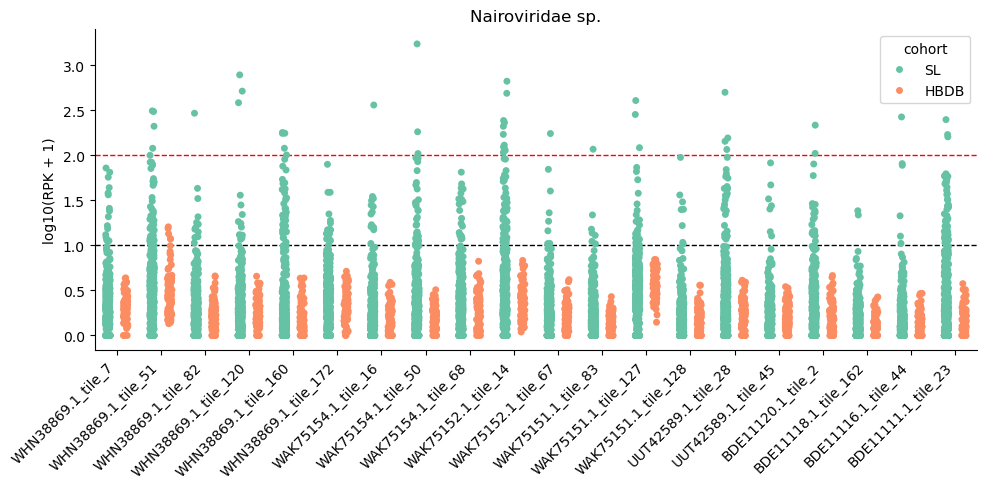

,peptide,sequence
0,ABB88931.1|protein|Mammarenavirus_choriomening...,ARLRQNQLGSGRYQVVECKEVFCQVIKMDSEEYHLLYQKTGECSRC
1,ABI96821.1|protein|Mammarenavirus_choriomening...,SRCIEMDGADKSGCIHNHDDKSVETILIESGIVCPGLPLIIPDGYK
2,ACP50597.1|nucleoprotein|Mammarenavirus_chorio...,EVAIFQPETGQYIHFYREPTDQKQFKQDAKHSHGMDLTDLFNVQPG
3,ACP50599.1|nucleoprotein|Mammarenavirus_chorio...,ENILYKVCLSGEGWPYIACRSSIVGRAWENTIIDLSDNRPAAHLSR
4,ACP50599.1|nucleoprotein|Mammarenavirus_chorio...,KQSQTPLNDVVQALTDLGLLYTVKYPNLTDLENLKDKHPVLGVITE
5,ACV72585.1|protein|Mammarenavirus_choriomening...,LELIGSRGVLDGVKSLDFERVGPEWEPVPLTVRVGALFEGKNLVQN
6,ACV72593.1|protein|Mammarenavirus_choriomening...,LNHSDYEYKVSKLVSRLVLGSKKTEAEQLEGEPEDVFFEGEEETQF
7,ACV72593.1|protein|Mammarenavirus_choriomening...,CLTNDDMKFFCEAVEGSEELSSLYFTSTVKDQCGLDEMAKNLSRKF
8,AFI42020.1|protein|Mammarenavirus_choriomening...,DARSHHNDEIMRMCHDGVNPSMSCDDVVFGINSLFSRFRRDLESGK
9,AFI42020.1|protein|Mammarenavirus_choriomening...,LSHSDYEYKVSKLVSRLVIGSKVTEEGKLEGDPSNVLFEGEEETSF


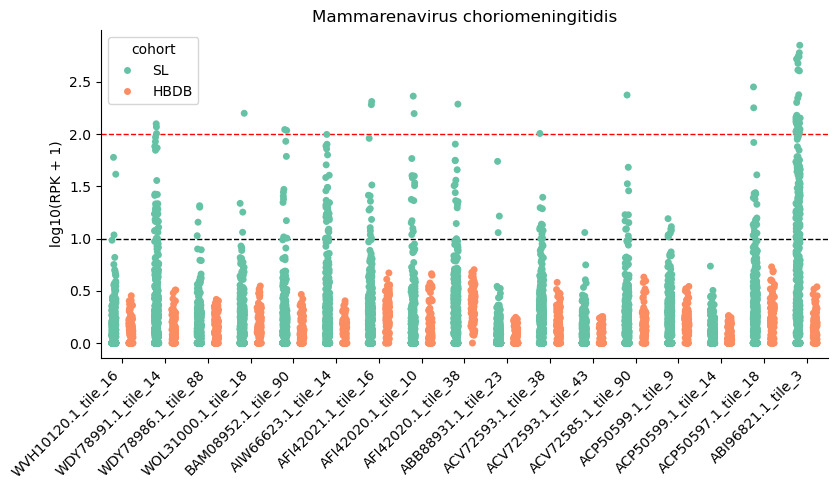

,peptide,sequence
0,AEA29966.1|glycoprotein|Jacunda_virus|isolate=...,ISLSLDAEGITGTNSISFLESSKGGFALYDEALSEIPREGFIGEVR
1,AEA30048.1|polyprotein|Mucura_virus|isolate=?|...,FIPLTLSCSETLVSNSKQVKCTQSSDGVKCSVTATVTQKAGIIGAE
2,AEA30048.1|polyprotein|Mucura_virus|isolate=?|...,RCHLVGECQGNRCQSWSDKEVSKEFKGISDNEIMSENKCFEQCGAI
3,AEA30048.1|polyprotein|Mucura_virus|isolate=?|...,SLDAEGISGTNSISFLESSKGGFALYDEALSEIPREGFIGEIRCSS
4,AEA30049.1|polyprotein|Morumbi_virus|isolate=?...,KGQDGVESDTRELKRVKVSECRNVDSNKSKICTGDHIFCQKYKCGD
5,AEA30051.1|polyprotein|Serra_Norte_virus|isola...,GQDNESQQREYKKVKLSDCSNVETGKSGVCTGDHIFCQKYTCSSAS
6,AEA30051.1|polyprotein|Serra_Norte_virus|isola...,QVRNGMTFTSSIDKKTVQAFNSGSIKAMITISMDDHEIQFLSDFGR
7,AEA30056.1|protein|Ariquemes_virus|isolate=?|s...,LGFSLDHDITNLEEFINKHDLGLFEESDDYFNPFQMDFDLRESAQK
8,AEA30056.1|protein|Ariquemes_virus|isolate=?|s...,DSDLSPASLRIHDESKDEMMALFNKEPSKSWATCSPIPAVMMHKII
9,AEA30056.1|protein|Ariquemes_virus|isolate=?|s...,IVKSLENDIKNEYEMEDFDLSDIDLFGPAHYKELSDLNTISHPLMD


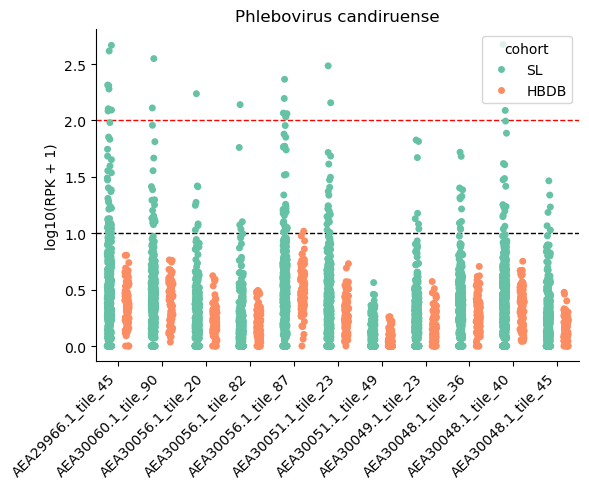

,peptide,sequence
0,YP_009346018.1|polyprotein|Ambe_virus|isolate=...,ILIGENPFDFRNKSGMTSTIINAKTSGWNFFSWLSGLTDWVGGPLK
1,YP_009346018.1|polyprotein|Ambe_virus|isolate=...,DEIAKLTARHEALVNALRETMTDRDRENNRLLSEKVEMENEKREIE
2,YP_009346030.1|polymerase|Ambe_virus|isolate=?...,EGADEDLSKLERELLSSLSLIEIDWDKTEASFPTFKRKMFEKFSQM
3,YP_009346030.1|polymerase|Ambe_virus|isolate=?...,GSISRMEDNPELELQQALGEGLDRPDERNKYHRVKIEMTSDERLYA
4,YP_009346030.1|polymerase|Ambe_virus|isolate=?...,DFSLDSLDSNSTIGSTLKPECVITGVKLSNFVHDFTYGHLCGSSDQ
5,YP_009346030.1|polymerase|Ambe_virus|isolate=?...,VLEQIDDQILKEMGHLTLERLATLKATSRFDENWYVYKDVKDKNYT
6,YP_009346030.1|polymerase|Ambe_virus|isolate=?...,VDIDSLMDLMMEDIHSNVFEEMANELHDDIEGQFEFEQFDAADVEL


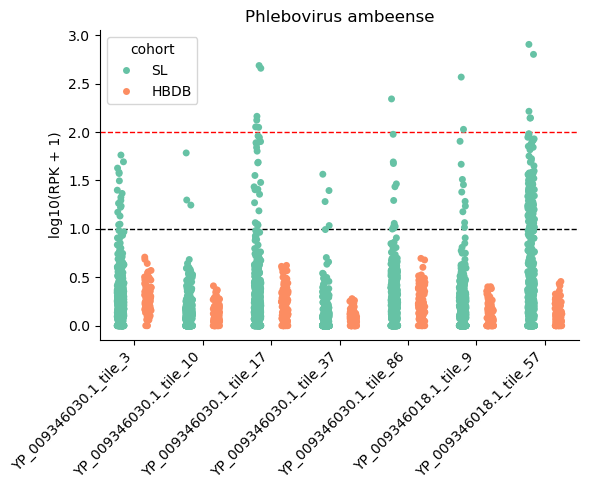

,peptide,sequence
0,ALL27019.1|polyprotein|Zika_virus|isolate=?|Ho...,VQYAGTDGPCKVPAQMAVDMQTLTPVGRLITANPVITESTENSKMM
1,ALL27019.1|polyprotein|Zika_virus|isolate=?|Ho...,GGCAETDEDHAHWLEARMLLDNIYLQDGLIASLYRPEADKVAAIEG
2,ANT96597.1|protein|Zika_virus_vector_pZIKV-ICD...,TIGGPKELTAFLHNMGDHVTRLDRWEPELNEAIPNDERDTTMPAAM
3,AQS26802.1|polyprotein|Zika_virus|isolate=ZIKV...,NEDHWMGRENSGGGVEGLGLQRLGYVLEEMSRTPGGRMYADDTAGW
4,ATG29296.1|polyprotein|Zika_virus|isolate=ZIKV...,EMKTCEWPKSHTLWTDGIEESDLIIPKSLAGPLSLHNTREGYRTQM
5,UHI99951.1|polyprotein|Zika_virus|isolate=GO53...,YAGTDGPCKVPAQMAVDVQTLTPVGRLITANPVITESTENSKMMLE
6,XJQ58408.1|polyprotein|Zika_virus|isolate=AFI-...,LKSGVDVFHMAAEPCDTLLCDIGESSSSPEVEEARTLRVLSMVGDW
7,XJQ58408.1|polyprotein|Zika_virus|isolate=AFI-...,WFHDIPLPWHAGADTGTPHWNNKEALVEFKDAHAKRQTVVVLGSQE
8,XJQ58408.1|polyprotein|Zika_virus|isolate=AFI-...,EMKTCEWPKSHTLWTDGIEESDLIIPKSLAGPLSHHNTREGYRSQM
9,XJQ58408.1|polyprotein|Zika_virus|isolate=AFI-...,CAETDEDHAHWLEARMLLDNIYLQDGLIASLYRPEADKVAAIEGEF


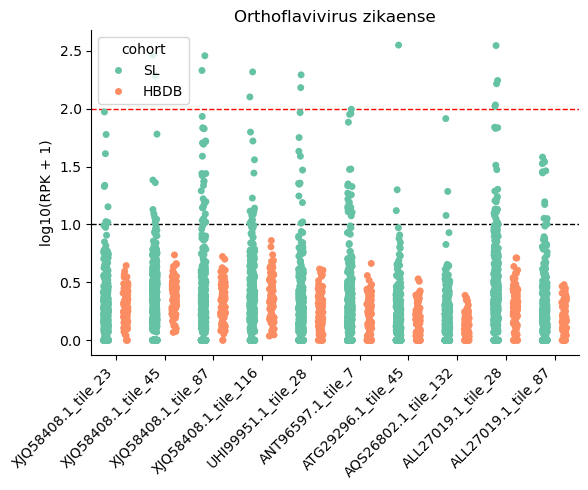

,peptide,sequence
0,ADU17892.1|protein|Measles_morbillivirus|T105-...,MAEEQARHVKNGLECIRALKAEPIGSLAVEEALAAWSETSDNPGQD
1,ADU17892.1|protein|Measles_morbillivirus|T105-...,IGSLAVEEALAAWSETSDNPGQDRATCKEEKAGSSGLSKPCLSAIG
2,ADU17962.1|phosphoprotein|Measles_morbilliviru...,SGEAAKGIQDADSIMVQSGLDSDSTLSGGDDESENSDVDIGEPDTE
3,ADU17962.1|phosphoprotein|Measles_morbilliviru...,GYAITDRGSAPISVGFRASDVETAEGGEIHELLRLQSRGDNFPKLG
4,AEP95738.1|protein|Measles_morbillivirus|?|Hom...,ITRPSDNGHHTAPRRMLEFRPVNAVAFNPLATLRIDKAIGPGKITD
5,ARL00310.1|protein|Measles_virus_genotype_D9|?...,GYAITDRGSAPISMGFRASDVETAEGGEIHELLKLQSRGNSFPKLG
6,AVA07198.1|protein|Measles_virus_genotype_G2|t...,PDLKPIIGRDSGRALAEVLKKPVASRQLQGVTNGRTSSRGQLLKEF
7,BAQ25524.1|nucleoprotein|Measles_morbillivirus...,KVSSTLASELGITAEDARLVSEIAMHTTEDRISRGVGPRQAQVSFL
8,QHG61060.1|protein|Measles_virus_genotype_B3|?...,GSGMDLYKSNRNNVYWLTIPPMRNLALGVINTLEWIPRFKVSPNLF
9,WJH19239.1|phosphoprotein|Measles_virus_genoty...,SNAALIPEWTPESGTTISPRSQNNEEGGEYYDDELFSDVQDIKTAL


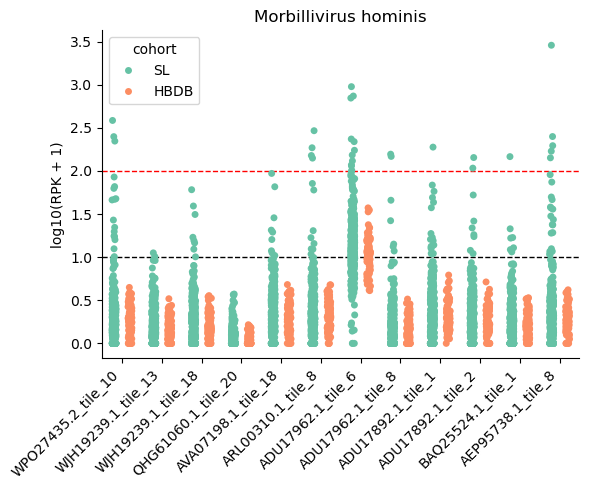

,peptide,sequence
0,WPV62323.1|phosphoprotein|Wenzhou_shrew_henipa...,LGLAVSSMEQMLASMRIMIPGKPIEEGDKPKNPTLKPVIGRDTIKA
1,WPV62323.1|phosphoprotein|Wenzhou_shrew_henipa...,GCRDNRAEGSGQGHGCAEINKGNLPFIFQGNLSQDPNVEDIGTKNE
2,WZI33218.1|phosphoprotein|Crocidura_tanakae_he...,QTRSDVDIQDSSVSTTGESSVDQGQQDHNYPKARPGTPIPHINKLT
3,WZI33498.1|phosphoprotein|Jingmen_Crocidura_sh...,TVCPGMVQRSGSKNGATLYAPGLNHVQQERDASAGHAPDTVNRKIA
4,WZI33498.1|phosphoprotein|Jingmen_Crocidura_sh...,TSAWELFHKVTLDADRHEEGIGEEGDSNTPVRDDSRNEHDDDGVDS
5,WZI33502.1|glycoprotein|Jingmen_Crocidura_shan...,KLKDPIMDIQNNCHNTNQDMCPAVCSSYGYEDIFPLNIEGNAMTYM
6,XJU75811.1|glycoprotein|Camp_Hill_virus|isolat...,TIGLNITTLSSIDYQRGLVTHMRKELDDKMTMMSELEEMIKSDLKP
7,XJU75811.1|glycoprotein|Camp_Hill_virus|isolat...,LNTKLLLLENKLGIVPDYSDSTPTKPATGDDNMTAPEEEDSNDDDS
8,XJU75812.1|polymerase|Camp_Hill_virus|isolate=...,VSSVPKTEAYDQDVWRVNKRDEVPIVNKERLDKDILNYYTSKCCTV


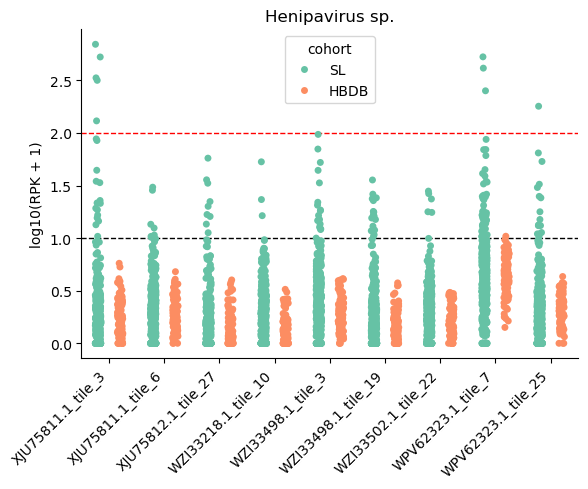

,peptide,sequence
0,ABV80308.1|polyprotein|Fusong_virus|isolate=?|...,RVVGKLSGKAPSTESSDTVQGVAFAGTPFYTSTGVLVAKDDPVYVW
1,ABV80308.1|polyprotein|Fusong_virus|isolate=?|...,SYTYRRELQNPASEQEKVPFHLQIERQVVHAEIQHLGHWMDGTFNL
2,ACT53110.1|polyprotein|Hantavirus_Jurong_TJK/0...,KIECPHSVNFGETSVSGQVELPPLPIAEVEQLVPESSCNMDNHQSL
3,AID54674.1|protein|Amga_virus|isolate=?|Sorex_...,ATGRQSQAAAEDPTGKEADDYLSQRSMLRYGNTIDVNAIDLDEPSG
4,AIL25318.1|glycoprotein|Yuanjiang_virus|isolat...,HASTTTQQAFTKWTWEKKSDLADGTKSSSSSYVSKSNEVNLRGLCV
5,AIL25331.1|polymerase|Yuanjiang_virus|isolate=...,DCSKIIEKILSDLEVNVGESGTFIDQPKKTTGVDDILKKFYDNELT
6,AMN88567.1|nucleocapsid|Xinyi_virus|isolate=?|...,RQTDVKNVQDKIAQLKQLMAEKVREGTQSMAARDPTGMEPDDHMSQ
7,ATX68098.1|glycoprotein|Seewis_virus|isolate=E...,KIECETQLEYKAHQASCPQHQCPYCFAHCEPSEAALQAHYKVCQVT
8,QBB85962.1|protein|Yakeshi_virus|isolate=Khekh...,TQSMGVQLDQRIINLYMSNWGKEAVDHFHLGDDMDPELRAAAQTLI
9,QFQ60707.1|polymerase|Buffalo_Bayou_virus|isol...,TDIEKEYNELRQDEDFSNFVNSMPTATFQKLERHLLHQRENNTAWN


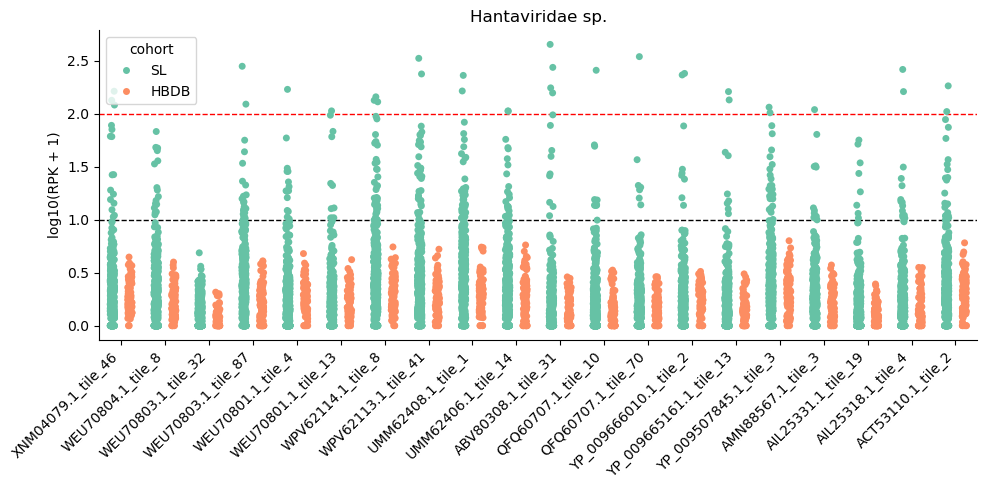

,peptide,sequence
0,AAR85463.1|protein|Orthomarburgvirus_marburgen...,IPPPLPTARPEIKLTSTPTDATKLNTTDPSSDDEDLATSGSGSGER
1,AFV31370.1|glycoprotein|Orthomarburgvirus_marb...,VPNTKTIFDESSSSGASAEEDQHASPNISLTLSYFPNINENTAYSG
2,AJY53714.1|precursor|Orthomarburgvirus_marburg...,DTGCFGTLQEYNSTKNQTCTPSKTPPSPPTAHPEIKPTSTPTDATR
3,QIC36348.1|glycoprotein|Orthomarburgvirus_marb...,GYRHMNLTSTNKYWTSSNGTQTNDTGCFGTLQEYNSTKNQTCAPSK
4,WKR37932.1|glycoprotein|Orthomarburgvirus_marb...,GYRHMNLTSTNKYWTSSNGTQTNDTGCFGILQEYNSTKNQTCAPPK
5,WKR37935.1|polymerase|Orthomarburgvirus_marbur...,VPSEYLFFDKPLDVDLNKYMDNELVYDNDPLCSGIKGRLGRVSRST
6,WKR37935.1|polymerase|Orthomarburgvirus_marbur...,TNSKYIVHPKNIPEMNARTELINYGSTTLQGMDIKMPLSEQNLVEG


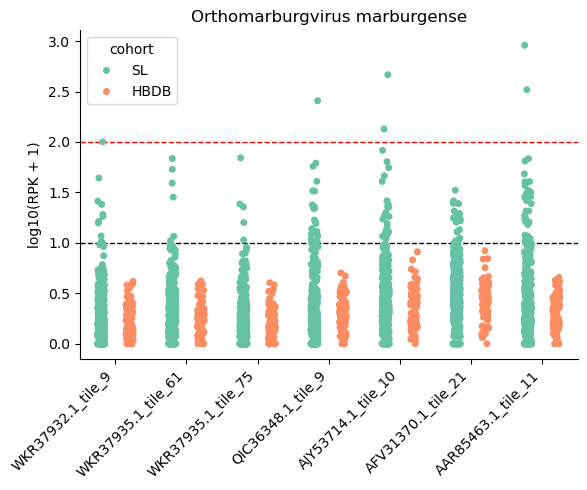

,peptide,sequence
0,WJL97488.1|nucleoprotein|Cuevavirus_lloviuense...,VATAHGSTLAGVNVSEQYQQLREAATEAEKQLQQHSEMRELETLGL
1,WJL97488.1|nucleoprotein|Cuevavirus_lloviuense...,SSILAIRKERLRKLTEALTEEKNKNALDDEDESEEDDWSPENRGIR
2,WJL97488.1|nucleoprotein|Cuevavirus_lloviuense...,YNSKDDHLSGKEQMSTQQESGADDLDLFDLDDDGDTNSQDPNNRQK
3,WJL97488.1|nucleoprotein|Cuevavirus_lloviuense...,DDNEGEILDDKSDLPAPDTHSDPDTEESEEEHPDEELLPPAPKYST
4,WJL97491.1|GP1|Cuevavirus_lloviuense|isolate=H...,FTEGTIAFLIVPKDAPRLKAGLGTGFSHQAENQNPNNQFRTTTLDY
5,WJL97492.1|GP2|Cuevavirus_lloviuense|isolate=H...,APPTITQQTSTSINTSHHPNMTTQLARHPSVQTRMQNPSCNPNLRY


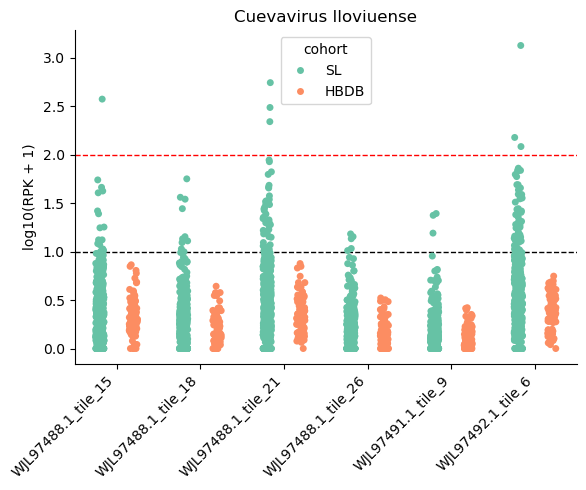

,peptide,sequence
0,BAA05016.1|protein|Orthohantavirus_hantanense|...,VSLLGGPATNRDYLRQRQVALGNMETKESKAIRQHAEAAGCSMIED
1,BAA05016.1|protein|Orthohantavirus_hantanense|...,QKVRDAEKQYEKDPDELNKRALTNREGVAVSIQAKIDELKMQLADR
2,BAA05016.1|protein|Orthohantavirus_hantanense|...,DDSSFEDVNGIRKPKHLYVSLPNAQSSMKAEEITPGRYRTAVCGLY
3,XHP16135.1|glycoprotein|Orthohantavirus_hantan...,IMSPRDKGFLCPEFPGSFRKKCNFATTPICEYDGNMVSGYKKVMAT
4,XHP16135.1|glycoprotein|Orthohantavirus_hantan...,SLNTITKYTQVSWRGKADQSQSSQNSFETVSTEVDLKGTCVLKHKM


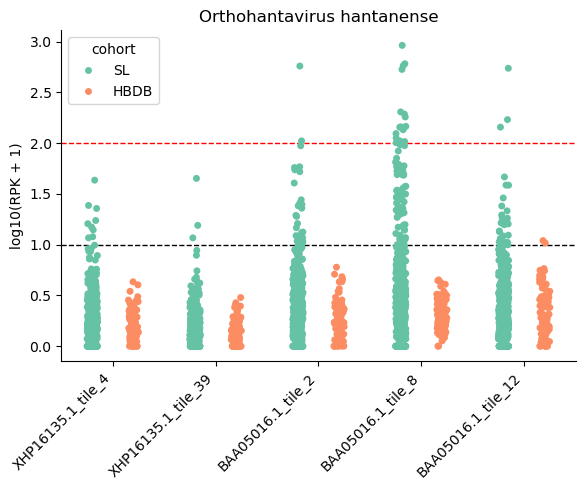

In [ ]:
top_taxa_list = top_taxa.values

for taxa in top_taxa_list: 
    table = peptide_lookup_table(taxa, level='species', cohort='SL')
    most_reactive = table.sort_values('mean_rpk', ascending=False).head(20)
    most_shared   = table[table['prevalence'] >= 0.05].sort_values('prevalence', ascending=False).head(20)
    display(table[['peptide','sequence']])

    plot_peptides(most_shared['peptide'], species=taxa)


#### here helper code to quickly look up peptide sequences

In [ ]:
peptide_to_sequence = peps_metadata.drop_duplicates('peptide').set_index('peptide')['sequence']

peptide_to_sequence.loc['']

KeyError: 'PEP00123'

### plotting viral family seroreactivity

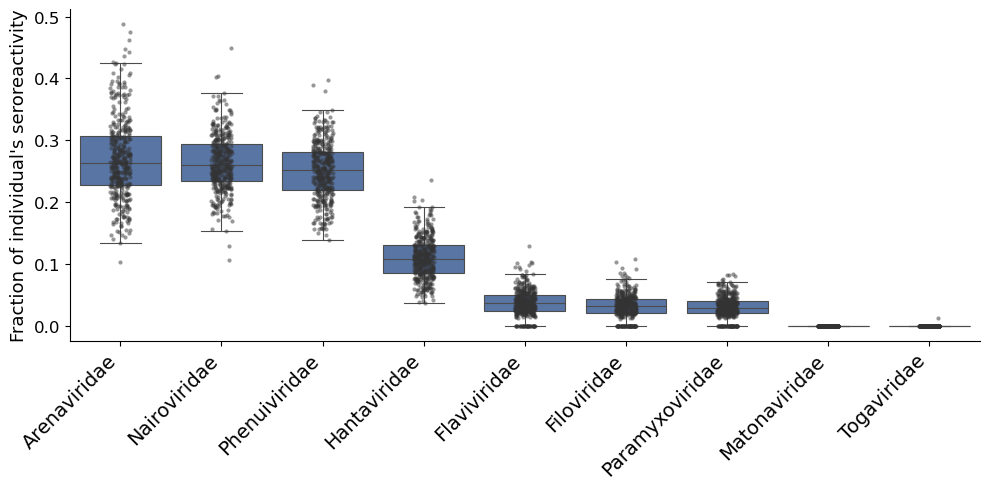

In [ ]:
#plot 1 - %seroreactivity to viral family

import matplotlib.pyplot as plt
import seaborn as sns

MIN_TOTAL_HITS = 5 #need at least 5 independent seroreactive peptides for a 'fraction' to be meaningful 

eligible_individuals = total_hits_per_individual[total_hits_per_individual >= MIN_TOTAL_HITS].index

family_df = master[
    (master['level'] == 'family') & 
    (master['category'] != 'HBDB') & 
    (master['individual'].isin(eligible_individuals))
    ].copy()


order = (
    family_df.groupby('value', observed=True)['frac_of_individual_hits_confirmed'] #groupin by family and taking the median frac of individual hits
    .median()
    .sort_values(ascending=False)
    .index
)

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(
    data=family_df, x='value', y='frac_of_individual_hits_confirmed',
    order=order, color='#4C72B0', fliersize=0, linewidth=0.8, ax=ax,
)
sns.stripplot(
    data=family_df, x='value', y='frac_of_individual_hits_confirmed',
    order=order, color='#333333', size=3, alpha=0.5, linewidth=0, ax=ax,
)
ax.set_xlabel('')
ax.tick_params(axis='y', labelsize=12)
ax.tick_params(axis='x', labelsize=14)
ax.set_ylabel("Fraction of individual's seroreactivity", fontsize=13)
plt.xticks(rotation=45, ha='right')
sns.despine()
plt.tight_layout()
plt.show()

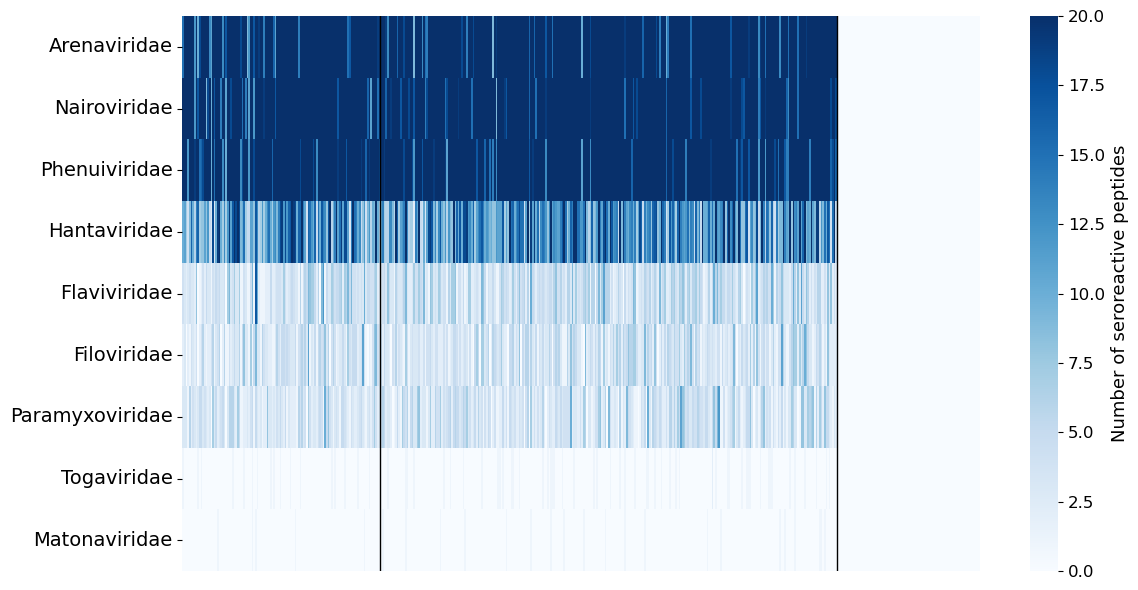

In [ ]:
#-- next plot should be a heatmap 

family_df_all = master[master['level'] == 'family'].copy()

# x-axis order: category (S, C, HBDB) then individual id within category
individual_order = (
    family_df_all[['individual', 'category']]
    .drop_duplicates()
    .sort_values(['category', 'individual'])['individual']
)

# y-axis order: families with the most total hits at top
family_order = (
    family_df_all.groupby('value', observed=True)['n_hits']
    .sum()
    .sort_values(ascending=False)
    .index
)

heatmap_df = family_df_all.pivot(index='value', columns='individual', values='n_hits')
heatmap_df = heatmap_df.loc[family_order, individual_order]

categories = (
    family_df_all[['individual', 'category']]
    .drop_duplicates()
    .set_index('individual')
    .loc[individual_order, 'category']
)
boundaries = categories.ne(categories.shift()).to_numpy().nonzero()[0]

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(
    heatmap_df,
    cmap='Blues',
    linewidths=0,          # no gridlines — they were wider than the cells themselves
    cbar_kws={'label': 'Number of seroreactive peptides'},
    ax=ax,
    vmin=0, 
    vmax=20
)
ax.collections[0].colorbar.set_label('Number of seroreactive peptides', fontsize=13)
ax.collections[0].colorbar.ax.tick_params(labelsize=12)
ax.set_xlabel('')
ax.set_ylabel('')
ax.set_xticks([])
ax.tick_params(axis='y', labelsize=14)
for b in boundaries[1:]: 
    ax.axvline(b, color='black', linewidth=1)
plt.tight_layout()

plt.show()

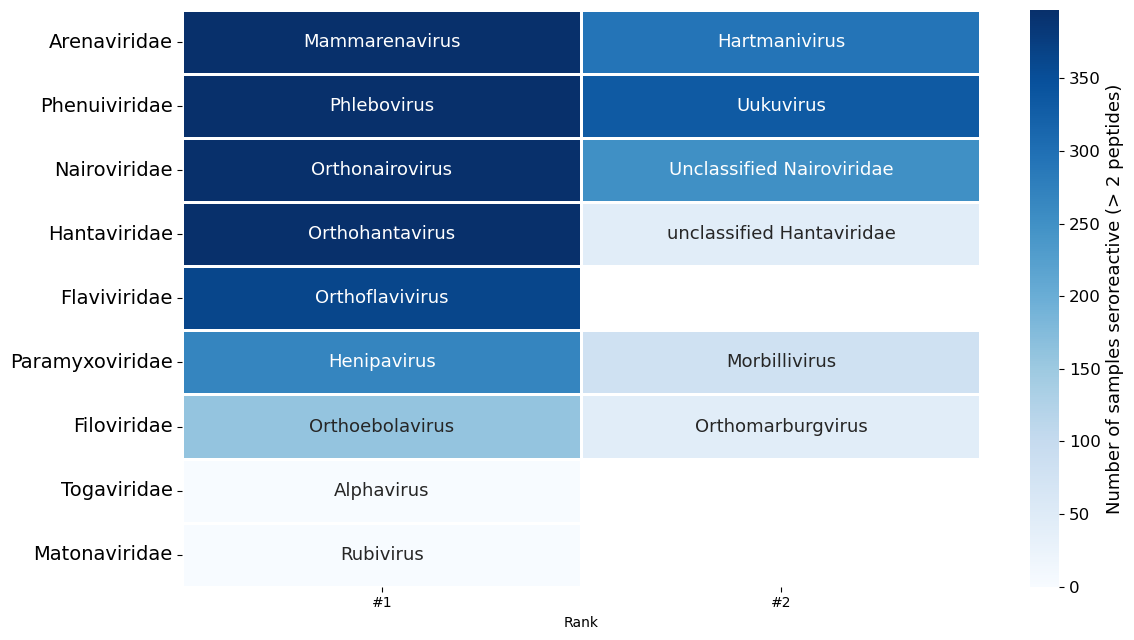

In [ ]:
GENUS_MIN_PEPTIDES = 2 #min seroreactive peptides in genus for a sample to count as "seroreactive to genus"

genus_df = master[master['level'] == 'genus'].copy()

#bring back the family each genus belongs to 
genus_to_family = hits[['genus', 
    'family']].drop_duplicates().set_index('genus')['family']
genus_df['family'] = genus_df['value'].map(genus_to_family)

#prevalence: how many individuals are seroreactive to each genus
genus_prevalence = (
    genus_df.assign(is_pos=genus_df['n_hits'] >= GENUS_MIN_PEPTIDES)
    .groupby(['family', 'value'], observed=True)['is_pos']
    .sum()
    .reset_index(name='n_samples_seroreactive')
)

top5_per_family = (
    genus_prevalence
    .sort_values('n_samples_seroreactive', ascending=False)
    .groupby('family')
    .head(2)
)

top5_per_family = top5_per_family.sort_values(['family', 'n_samples_seroreactive'], ascending=[True, False])
top5_per_family['rank'] = (
    top5_per_family.groupby('family')['n_samples_seroreactive']
    .rank(method='first', ascending=False)
    .astype(int)
)

family_order = (
    top5_per_family.groupby('family')['n_samples_seroreactive']
    .max()
    .sort_values(ascending=False)
    .index
)

value_matrix = top5_per_family.pivot(index='family', columns='rank', values='n_samples_seroreactive').loc[family_order]
label_matrix = top5_per_family.pivot(index='family', columns='rank', values='value').loc[family_order]

fig, ax = plt.subplots(figsize=(12, 0.5 * len(family_order) + 2))
sns.heatmap(
    value_matrix,
    cmap='Blues',
    linewidths=1, linecolor='white',
    annot=label_matrix, fmt='',
    annot_kws={'fontsize': 13},
    cbar_kws={'label': 'Number of samples seroreactive (> 2 peptides)'},
    ax=ax,
)
ax.collections[0].colorbar.set_label('Number of samples seroreactive (> 2 peptides)', fontsize=13)
ax.collections[0].colorbar.ax.tick_params(labelsize=12)
ax.tick_params(axis='y', labelsize=14)
ax.set_xlabel('Rank')
ax.set_ylabel('')
ax.set_xticklabels([f'#{i}' for i in value_matrix.columns])
plt.tight_layout()
plt.show()

In [ ]:
genus_prevalence.sort_values(by='n_samples_seroreactive', ascending=False).head(30)

,family,value,n_samples_seroreactive
3,Arenaviridae,Mammarenavirus,397
36,Phenuiviridae,Phlebovirus,397
23,Nairoviridae,Orthonairovirus,397
16,Hantaviridae,Orthohantavirus,396
13,Flaviviridae,Orthoflavivirus,363
39,Phenuiviridae,Uukuvirus,332
35,Phenuiviridae,Bandavirus,328
1,Arenaviridae,Hartmanivirus,293
4,Arenaviridae,Reptarenavirus,284
31,Paramyxoviridae,Henipavirus,268


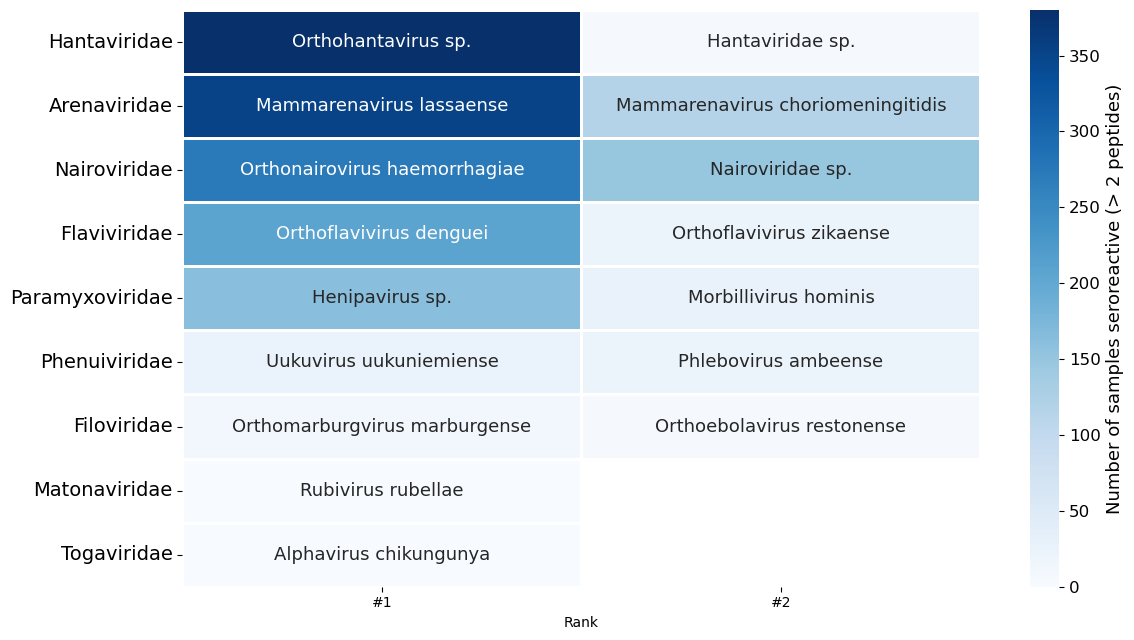

In [ ]:
GENUS_MIN_PEPTIDES = 3 #min seroreactive peptides in genus for a sample to count as "seroreactive to genus"

genus_df = master[master['level'] == 'species'].copy()

#bring back the family each genus belongs to 
genus_to_family = hits[['species', 
    'family']].drop_duplicates().set_index('species')['family']
genus_df['family'] = genus_df['value'].map(genus_to_family)

#prevalence: how many individuals are seroreactive to each genus
genus_prevalence = (
    genus_df.assign(is_pos=genus_df['n_hits'] >= GENUS_MIN_PEPTIDES)
    .groupby(['family', 'value'], observed=True)['is_pos']
    .sum()
    .reset_index(name='n_samples_seroreactive')
)

top5_per_family = (
    genus_prevalence
    .sort_values('n_samples_seroreactive', ascending=False)
    .groupby('family')
    .head(2)
)

top5_per_family = top5_per_family.sort_values(['family', 'n_samples_seroreactive'], ascending=[True, False])
top5_per_family['rank'] = (
    top5_per_family.groupby('family')['n_samples_seroreactive']
    .rank(method='first', ascending=False)
    .astype(int)
)

family_order = (
    top5_per_family.groupby('family')['n_samples_seroreactive']
    .max()
    .sort_values(ascending=False)
    .index
)

value_matrix = top5_per_family.pivot(index='family', columns='rank', values='n_samples_seroreactive').loc[family_order]
label_matrix = top5_per_family.pivot(index='family', columns='rank', values='value').loc[family_order]

fig, ax = plt.subplots(figsize=(12, 0.5 * len(family_order) + 2))
sns.heatmap(
    value_matrix,
    cmap='Blues',
    linewidths=1, linecolor='white',
    annot=label_matrix, fmt='',
    annot_kws={'fontsize': 13},
    cbar_kws={'label': 'Number of samples seroreactive (> 2 peptides)'},
    ax=ax,
)
ax.collections[0].colorbar.set_label('Number of samples seroreactive (> 2 peptides)', fontsize=13)
ax.collections[0].colorbar.ax.tick_params(labelsize=12)
ax.tick_params(axis='y', labelsize=14)
ax.set_xlabel('Rank')
ax.set_ylabel('')
ax.set_xticklabels([f'#{i}' for i in value_matrix.columns])
plt.tight_layout()
plt.show()

In [ ]:
genus_prevalence.sort_values('n_samples_seroreactive', ascending=False).head(20)

,family,value,n_samples_seroreactive
120,Hantaviridae,Orthohantavirus sp.,380
42,Arenaviridae,Mammarenavirus lassaense,353
150,Nairoviridae,Orthonairovirus haemorrhagiae,273
99,Flaviviridae,Orthoflavivirus denguei,207
196,Paramyxoviridae,Henipavirus sp.,163
136,Nairoviridae,Nairoviridae sp.,149
36,Arenaviridae,Mammarenavirus choriomeningitidis,116
73,Arenaviridae,Reptarenavirus sp.,67
146,Nairoviridae,Orthonairovirus erveense,55
47,Arenaviridae,Mammarenavirus lunaense,53


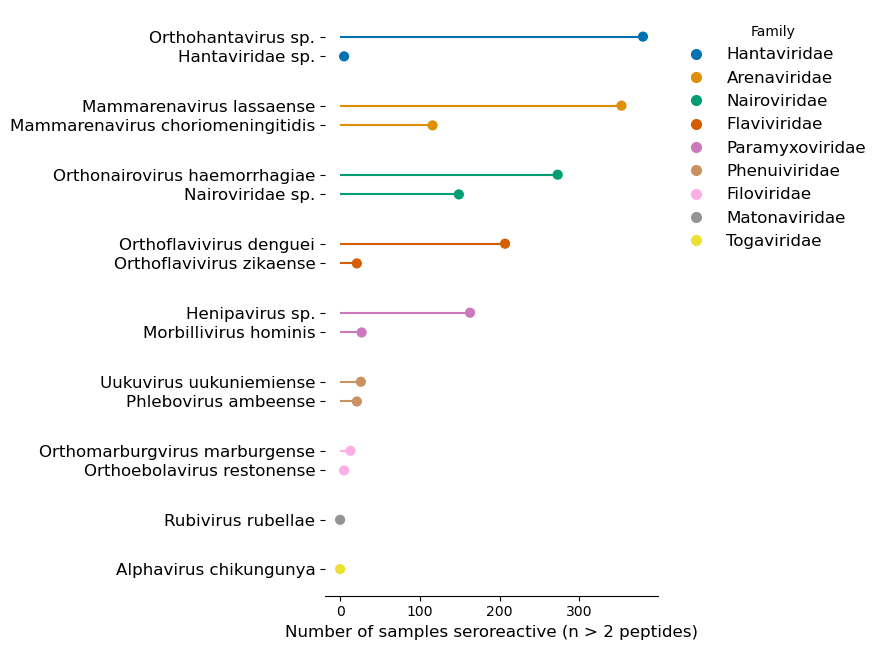

In [ ]:
top5_per_family = top5_per_family.sort_values(['family', 'n_samples_seroreactive'], ascending=[True, False])

family_order = (
    top5_per_family.groupby('family')['n_samples_seroreactive']
    .max()
    .sort_values(ascending=False)
    .index
)

# assign y-positions: genera stack within a family block, gap between blocks
rows = []
y = 0
gap = 1.5
for fam in family_order:
    sub = top5_per_family[top5_per_family['family'] == fam].sort_values('n_samples_seroreactive', ascending=False)
    for _, row in sub.iterrows():
        rows.append({'y': y, 'family': fam, 'genus': row['value'], 'n': row['n_samples_seroreactive']})
        y -= 1
    y -= gap

plot_df = pd.DataFrame(rows)
palette = dict(zip(family_order, sns.color_palette('colorblind', n_colors=len(family_order))))

fig, ax = plt.subplots(figsize=(9, 0.35 * len(plot_df) + 1))
for _, r in plot_df.iterrows():
    ax.hlines(r['y'], 0, r['n'], color=palette[r['family']], linewidth=1.5)
ax.scatter(plot_df['n'], plot_df['y'], c=plot_df['family'].map(palette), s=40, zorder=3)

ax.set_yticks(plot_df['y'])
ax.set_yticklabels(plot_df['genus'], fontsize=12)
ax.set_xlabel('Number of samples seroreactive (n > 2 peptides)', fontsize=12)
sns.despine(left=True)

handles = [plt.Line2D([0], [0], marker='o', color=palette[f], linestyle='', markersize=7) for f in family_order]
ax.legend(handles, family_order, title='Family', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False, fontsize=12)

plt.tight_layout()
plt.show()

In [ ]:
top5_per_family['fraction_seroreactive'] = top5_per_family['n_samples_seroreactive'] / df_SL_rpk.shape[1]

In [ ]:
top5_per_family

,family,value,n_samples_seroreactive,rank,fraction_seroreactive
42,Arenaviridae,Mammarenavirus lassaense,353,1,0.889169
36,Arenaviridae,Mammarenavirus choriomeningitidis,116,2,0.292191
94,Filoviridae,Orthomarburgvirus marburgense,13,1,0.032746
90,Filoviridae,Orthoebolavirus restonense,5,2,0.012594
99,Flaviviridae,Orthoflavivirus denguei,207,1,0.521411
102,Flaviviridae,Orthoflavivirus zikaense,21,2,0.052897
120,Hantaviridae,Orthohantavirus sp.,380,1,0.957179
106,Hantaviridae,Hantaviridae sp.,5,2,0.012594
126,Matonaviridae,Rubivirus rubellae,0,1,0.000000
150,Nairoviridae,Orthonairovirus haemorrhagiae,273,1,0.687657


In [ ]:
df_SL_rpk.shape

(90132, 397)

In [ ]:
SPECIES_MIN_PEPTIDES = 2

species_df = master[master['level'] == 'species'].copy()

#bring back the family each genus belongs to 
species_to_family = hits[['species', 
    'family']].drop_duplicates().set_index('species')['family']
species_df['family'] = species_df['value'].map(species_to_family)

#prevalence: how many individuals are seroreactive to each genus
species_prevalence = (
    species_df.assign(is_pos=species_df['n_hits'] >= SPECIES_MIN_PEPTIDES)
    .groupby(['family', 'value'], observed=True)['is_pos']
    .sum()
    .reset_index(name='n_samples_seroreactive')
)

top5_per_species = (
    species_prevalence
    .sort_values('n_samples_seroreactive', ascending=False)
    .groupby('family')
    .head(5)
)

In [ ]:
top5_per_species.head(3)

,family,value,n_samples_seroreactive
120,Hantaviridae,Orthohantavirus sp.,389
42,Arenaviridae,Mammarenavirus lassaense,377
150,Nairoviridae,Orthonairovirus haemorrhagiae,343


In [ ]:
#--- sum RPK and z score for peptides belonging to selected viral species, then boxplots

df_z = pd.concat([df_sl_z, df_hbdb_z], axis=1, join='inner')
z_long = (
    df_z.loc[hits['peptide']]
    .reset_index()
    .melt(id_vars='peptide', var_name='individual', value_name='zscore')
)
long = long.merge(z_long, on=['peptide', 'individual'], how='left')

/tmp/ipykernel_3546162/843256056.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sub, x='cohort', y='log10_sum_rpk', order=['SL', 'HBDB'], palette=palette, fliersize=0, linewidth=0.8, ax=ax)
/tmp/ipykernel_3546162/843256056.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sub, x='cohort', y='sum_zscore', order=['SL', 'HBDB'], palette=palette, fliersize=0, linewidth=0.8, ax=ax)
/tmp/ipykernel_3546162/843256056.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sub, x='cohort', y='log10_sum_rpk', order=['SL', 'HBDB'],

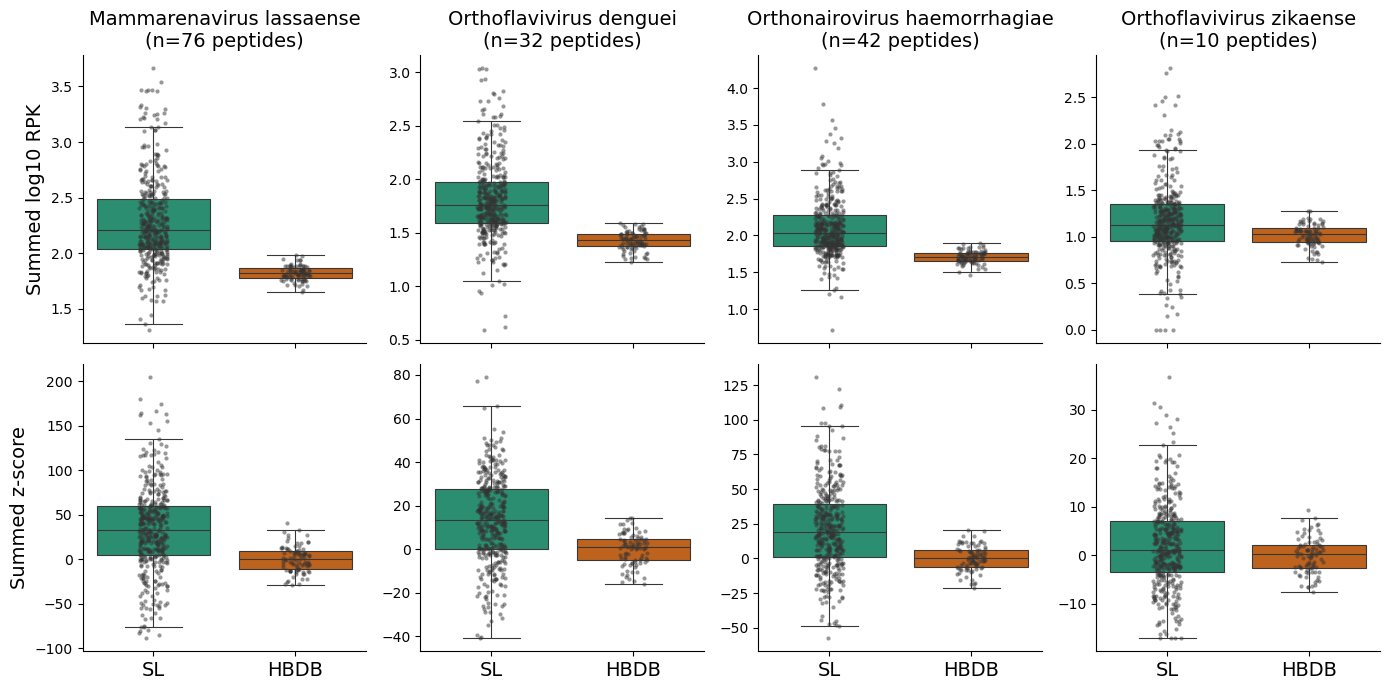

In [ ]:
import numpy as np

SELECTED_SPECIES = ['Mammarenavirus lassaense', 'Orthoflavivirus denguei', 'Orthonairovirus haemorrhagiae', 'Orthoflavivirus zikaense']  # fill in your picks

long['cohort'] = long['category'].map({'S': 'SL', 'C': 'SL', 'HBDB': 'HBDB'})

species_summary = (
    long[long['species'].isin(SELECTED_SPECIES)]
    .groupby(['species', 'individual', 'cohort'], observed=True)
    .agg(sum_rpk=('rpk', 'sum'), sum_zscore=('zscore', 'sum'))
    .reset_index()
)
species_summary['log10_sum_rpk'] = np.log10(species_summary['sum_rpk'] + 1)
species_summary['log2_sum_rpk'] = np.log2(species_summary['sum_rpk'] + 1)

palette = {'SL': '#1b9e77', 'HBDB': '#d95f02'}  

fig, axes = plt.subplots(2, len(SELECTED_SPECIES), figsize=(3.5 * len(SELECTED_SPECIES), 7), sharex=True)

n_peptides_by_species = hits.groupby('species')['peptide'].nunique()

for col, sp in enumerate(SELECTED_SPECIES):
    sub = species_summary[species_summary['species'] == sp]
    n_pep = n_peptides_by_species[sp]

    ax = axes[0, col]
    sns.boxplot(data=sub, x='cohort', y='log10_sum_rpk', order=['SL', 'HBDB'], palette=palette, fliersize=0, linewidth=0.8, ax=ax)
    sns.stripplot(data=sub, x='cohort', y='log10_sum_rpk', order=['SL', 'HBDB'], color='#333333', size=3, alpha=0.5, ax=ax)
    ax.set_title(f'{sp}\n(n={n_pep} peptides)', fontsize=14)
    ax.set_xlabel('')
    ax.set_ylabel('Summed log10 RPK' if col == 0 else '', fontsize=14)

    ax = axes[1, col]
    sns.boxplot(data=sub, x='cohort', y='sum_zscore', order=['SL', 'HBDB'], palette=palette, fliersize=0, linewidth=0.8, ax=ax)
    sns.stripplot(data=sub, x='cohort', y='sum_zscore', order=['SL', 'HBDB'], color='#333333', size=3, alpha=0.5, ax=ax)
    ax.set_xlabel('')
    ax.set_ylabel('Summed z-score' if col == 0 else '', fontsize=14)

sns.despine()
for ax in axes.flat:
    ax.tick_params(axis='x', labelsize=14)
plt.tight_layout()
plt.show()

/tmp/ipykernel_3546162/387861011.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sub, x='cohort', y='log2_sum_rpk', order=['SL', 'HBDB'], palette=palette, fliersize=0, linewidth=0.8, ax=ax)
/tmp/ipykernel_3546162/387861011.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sub, x='cohort', y='sum_zscore', order=['SL', 'HBDB'], palette=palette, fliersize=0, linewidth=0.8, ax=ax)
/tmp/ipykernel_3546162/387861011.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sub, x='cohort', y='log2_sum_rpk', order=['SL', 'HBDB'], p

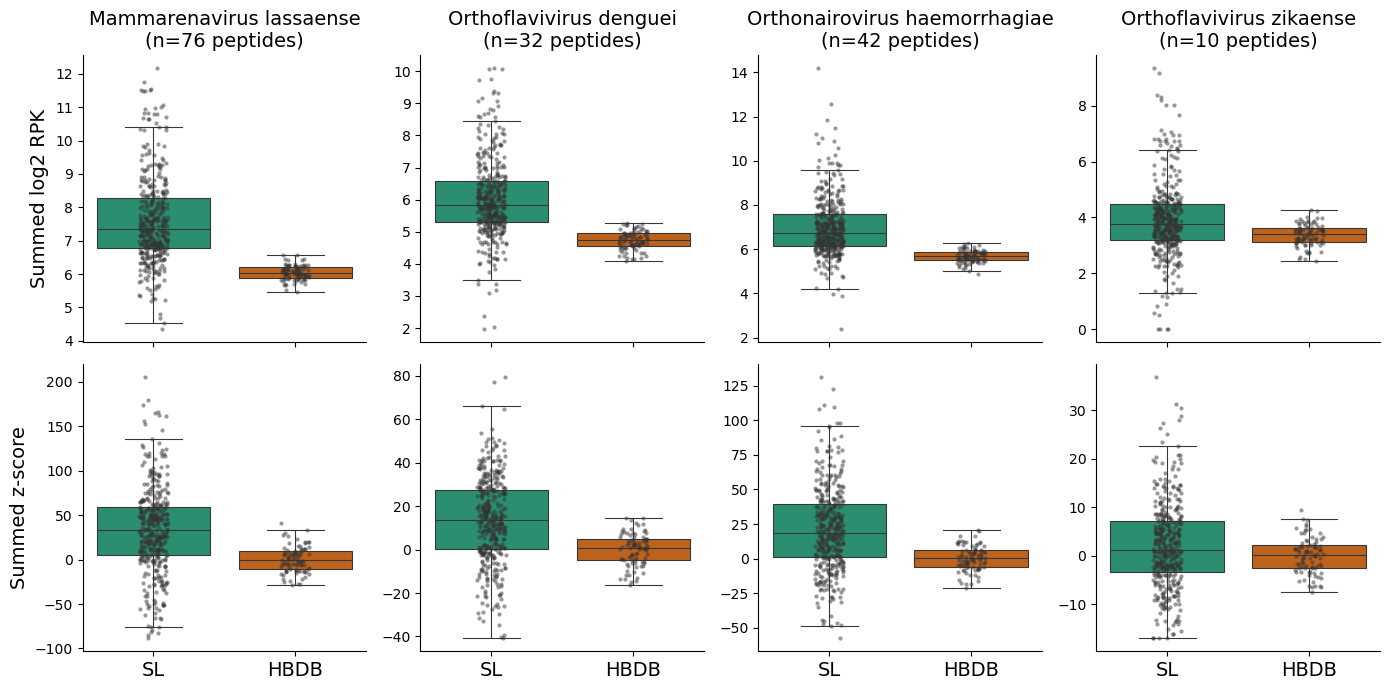

In [ ]:
palette = {'SL': '#1b9e77', 'HBDB': '#d95f02'}  

fig, axes = plt.subplots(2, len(SELECTED_SPECIES), figsize=(3.5 * len(SELECTED_SPECIES), 7), sharex=True)

n_peptides_by_species = hits.groupby('species')['peptide'].nunique()

for col, sp in enumerate(SELECTED_SPECIES):
    sub = species_summary[species_summary['species'] == sp]
    n_pep = n_peptides_by_species[sp]

    ax = axes[0, col]
    sns.boxplot(data=sub, x='cohort', y='log2_sum_rpk', order=['SL', 'HBDB'], palette=palette, fliersize=0, linewidth=0.8, ax=ax)
    sns.stripplot(data=sub, x='cohort', y='log2_sum_rpk', order=['SL', 'HBDB'], color='#333333', size=3, alpha=0.5, ax=ax)
    ax.set_title(f'{sp}\n(n={n_pep} peptides)', fontsize=14)
    ax.set_xlabel('')
    ax.set_ylabel('Summed log2 RPK' if col == 0 else '', fontsize=14)

    ax = axes[1, col]
    sns.boxplot(data=sub, x='cohort', y='sum_zscore', order=['SL', 'HBDB'], palette=palette, fliersize=0, linewidth=0.8, ax=ax)
    sns.stripplot(data=sub, x='cohort', y='sum_zscore', order=['SL', 'HBDB'], color='#333333', size=3, alpha=0.5, ax=ax)
    ax.set_xlabel('')
    ax.set_ylabel('Summed z-score' if col == 0 else '', fontsize=14)

sns.despine()
for ax in axes.flat:
    ax.tick_params(axis='x', labelsize=14)
plt.tight_layout()
plt.show()

### I now want to integrate the ELISA data provided from Tulane to see if it matches my PhIP-Seq signal

In [ ]:
elisa_data = pd.read_csv('../LASV_ELISA_Neut_forSophie_corrected.csv')

In [ ]:
import pandas as pd

def parse_sample_date(x):
    x = str(x).strip()

    #full date e.g. 5-May-22
    try: 
        return pd.to_datetime(x, format='%d-%b-%y')
    except ValueError:
        pass

    #Month-year: 22-Mar = March 2022
    try:
        return pd.to_datetime(x, format='%y-%b')
    except ValueError: 
        return pd.NaT

elisa_data['Sample_Date_parsed'] = elisa_data['Sample_Date'].apply(parse_sample_date)

#create month-year
elisa_data['Month_Year'] = elisa_data['Sample_Date_parsed'].dt.to_period('M')

In [ ]:
elisa_data['Sample'] = (
    elisa_data['Sample']
    .astype(str)
    .str.replace(r'\s+', ' ', regex=True)
    .str.strip()
)

In [ ]:
#elisa_data.to_csv('../LASV_ELISA_Neut_forSophie_corrected_w_month_year.csv')

In [ ]:
elisa_data.loc[[57, 629], 'Sample'].apply(repr)

57     'C-110-1'
629    'C-110-1'
Name: Sample, dtype: object

In [ ]:
elisa_data_first_tp = (
    elisa_data.sort_values('Sample_Date_parsed') 
    .drop_duplicates(subset='Sample', keep='first')
    .copy()
)

In [ ]:
elisa_data_first_tp.to_csv('../LASV_ELISA_Neut_forSophie_corrected_w_month_year_filtered_first_tp.csv')

In [ ]:
species_summary_lassa = species_summary.loc[species_summary['species'] == 'Mammarenavirus lassaense']

In [ ]:
species_summary_lassa['Sample'] = species_summary_lassa['individual'].astype(str).str.split('_').str[0]

/tmp/ipykernel_3546162/3358277833.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  species_summary_lassa['Sample'] = species_summary_lassa['individual'].astype(str).str.split('_').str[0]


In [ ]:
elisa_species_summary_lassa = pd.merge(species_summary_lassa, elisa_data_first_tp, on='Sample') #loosing US healthies here due to merging on 'Sample' ID

### defining seropositivity PhIP-Seq threshold based on US healthies RPK reactivity for LASV ELISA comparison

In [ ]:
#first defining threshold by which to call someone 'seropositive' -> 1std above the average summed RPK value for healthies for example

species_summary_lassa_threshold = species_summary.loc[species_summary['species']=='Mammarenavirus lassaense'].copy()

healthy = species_summary_lassa_threshold.loc[species_summary_lassa_threshold['cohort'] == 'HBDB']

threshold_rpk = (
    healthy['sum_rpk'].mean()
    + healthy['sum_rpk'].std()
)

print(threshold_rpk)

#or
threshold_rpk_max = healthy['sum_rpk'].max()

import numpy as np 

#classification using the threshold mean + 1 SD threshold
elisa_species_summary_lassa['PhIP-Seq_seropositive_1SD'] = np.where(
    elisa_species_summary_lassa['sum_rpk'] > threshold_rpk, 
    'Positive', 'Negative'
)

#classification using the maximum threshold
elisa_species_summary_lassa['PhIP-Seq_seropositive_max'] = np.where(
    elisa_species_summary_lassa['sum_rpk'] > threshold_rpk_max, 
    'Positive', 'Negative'
)

76.04775361715441


In [ ]:
healthy['individual'].nunique()

87

In [ ]:
threshold_rpk

np.float64(76.04775361715441)

In [ ]:
elisa_species_summary_lassa.to_csv('../LASV_ELISA_Neut_and_PhIP_Seq_result_corrected_w_month_year_filtered_first_tp.csv')

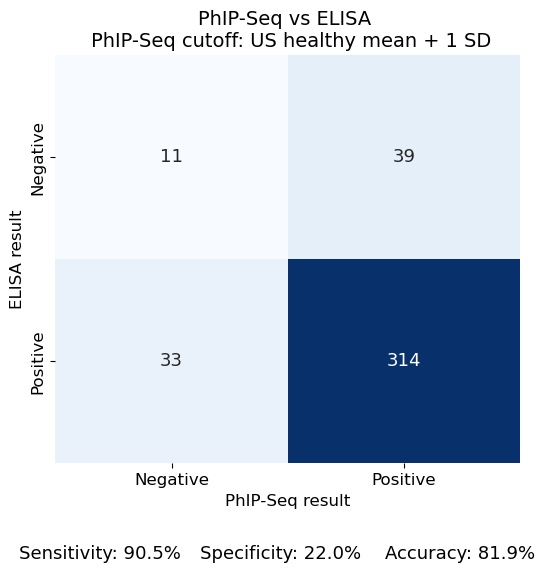

In [ ]:
#Comparing PhIP-Seq seropositivity result to ELISA using a 2x2 confusion heatmap

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, recall_score, confusion_matrix

elisa = (
    elisa_species_summary_lassa['Serology_Result_Corrected']
    == 'Positive'
)

phip_1SD = (
    elisa_species_summary_lassa['PhIP-Seq_seropositive_1SD']
    == 'Positive'
)

# Confusion matrix
tn, fp, fn, tp = confusion_matrix(elisa, phip_1SD).ravel()

#performance metrics
sensitivity = tp / (tp +fn)
specificity = tn / (tn + fp)
accuracy = (tp + tn) / (tp + tn + fp + fn)


comparison_1SD = pd.crosstab(
    elisa_species_summary_lassa['Serology_Result_Corrected'], 
    elisa_species_summary_lassa['PhIP-Seq_seropositive_1SD']
)


labels = [
    [f"{tn}", f"{fp}"], 
    [f"{fn}", f"{tp}"]
]
labels_2 = [
    [f"TN\n{tn}", f"FP\n{fp}"],
    [f"FN\n{fn}", f"TP\n{tp}"]
]

fig, ax = plt.subplots(figsize=(6, 6))

sns.heatmap(
    comparison_1SD,
    annot=labels,
    fmt='',
    cmap='Blues',
    xticklabels=['Negative', 'Positive'],
    yticklabels=['Negative', 'Positive'],
    cbar=False,
    annot_kws={'size': 13},   # TN/FP/FN/TP + numbers
    ax=ax
)

ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=12)
ax.set_xlabel('PhIP-Seq result', fontsize=12)
ax.set_ylabel('ELISA result', fontsize=12)
ax.set_title('PhIP-Seq vs ELISA \n PhIP-Seq cutoff: US healthy mean + 1 SD', fontsize=14)

# Metrics underneath with controlled horizontal spacing
fig.text(
    0.20, 0.04,
    f"Sensitivity: {sensitivity:.1%}",
    ha='center',
    fontsize=13
)

fig.text(
    0.50, 0.04,
    f"Specificity: {specificity:.1%}",
    ha='center',
    fontsize=13
)

fig.text(
    0.80, 0.04,
    f"Accuracy: {accuracy:.1%}",
    ha='center',
    fontsize=13
)

# Leave room at bottom for metrics
plt.subplots_adjust(bottom=0.2)

plt.show()

In [ ]:
from sklearn.metrics import accuracy_score, recall_score, confusion_matrix

elisa = (
    elisa_species_summary_lassa['Serology_Result_Corrected']
    == 'Positive'
)

phip_1SD = (
    elisa_species_summary_lassa['PhIP-Seq_seropositive_1SD']
    == 'Positive'
)

# Confusion matrix
tn, fp, fn, tp = confusion_matrix(elisa, phip_1SD).ravel()

accuracy = accuracy_score(elisa, phip_1SD)
sensitivity = recall_score(elisa, phip_1SD)
specificity = tn / (tn + fp)

print("Accuracy:", accuracy)
print("Sensitivity:", sensitivity)
print("Specificity:", specificity)

Accuracy: 0.818639798488665
Sensitivity: 0.9048991354466859
Specificity: 0.22


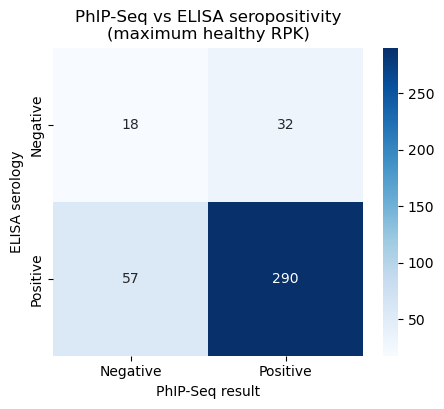

In [ ]:
comparison_max = pd.crosstab(
    elisa_species_summary_lassa['Serology_Result_Corrected'],
    elisa_species_summary_lassa['PhIP-Seq_seropositive_max']
)

plt.figure(figsize=(5, 4))
sns.heatmap(
    comparison_max,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel('PhIP-Seq result')
plt.ylabel('ELISA serology')
plt.title('PhIP-Seq vs ELISA seropositivity\n(maximum healthy RPK)')
plt.show()

In [ ]:
from sklearn.metrics import accuracy_score, recall_score, confusion_matrix

elisa = (
    elisa_species_summary_lassa['Serology_Result_Corrected']
    == 'Positive'
)

phip_1SD = (
    elisa_species_summary_lassa['PhIP-Seq_seropositive_1SD']
    == 'Positive'
)

# Confusion matrix
tn, fp, fn, tp = confusion_matrix(elisa, phip_1SD).ravel()

accuracy = accuracy_score(elisa, phip_1SD)
sensitivity = recall_score(elisa, phip_1SD)
specificity = tn / (tn + fp)

print("Accuracy:", accuracy)
print("Sensitivity:", sensitivity)
print("Specificity:", specificity)

Accuracy: 0.818639798488665
Sensitivity: 0.9048991354466859
Specificity: 0.22


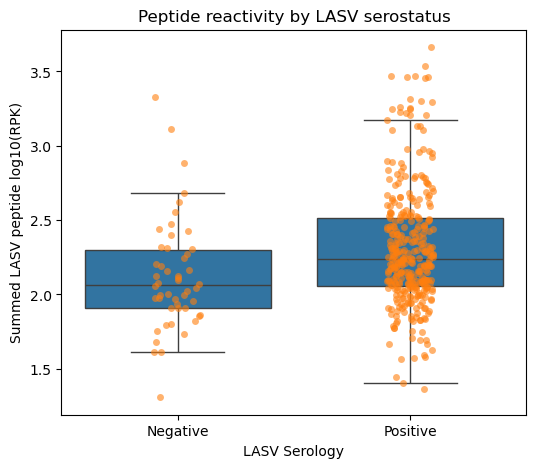

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 5))

sns.boxplot(
    data = elisa_species_summary_lassa, 
    x='Serology_Result_Corrected', 
    y='log10_sum_rpk', 
    showfliers=False
)

sns.stripplot(
    data = elisa_species_summary_lassa, 
    x='Serology_Result_Corrected', 
    y='log10_sum_rpk', 
    jitter=True,
    alpha=0.6
)

plt.xlabel('LASV Serology')
plt.ylabel('Summed LASV peptide log10(RPK)')
plt.title('Peptide reactivity by LASV serostatus')

plt.show()

### defining top and bottom dengue virus and ebolavirus zaire responders for ELISA

In [ ]:
master_denguei = master.loc[master['value'] == 'Orthoflavivirus denguei']
master_denguei_top = master_denguei.sort_values(by='sum_rpk', ascending=False).head(40)
master_denguei_bottom = master_denguei.sort_values(by='sum_rpk', ascending=True).head(40)

In [ ]:
master_ebov_zaire = master.loc[master['value'] == 'Orthoebolavirus zairense']
master_ebov_zaire_top = master_ebov_zaire.sort_values(by='sum_rpk', ascending=False).head(40)
master_ebov_zaire_bottom = master_ebov_zaire.sort_values(by='sum_rpk', ascending=True).head(40)

## Looking at seasonality for LASV

/tmp/ipykernel_3546162/1106247207.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  species_long['collection_year'] = pd.to_datetime(


0 of 76 peptides for this species have no usable collection date


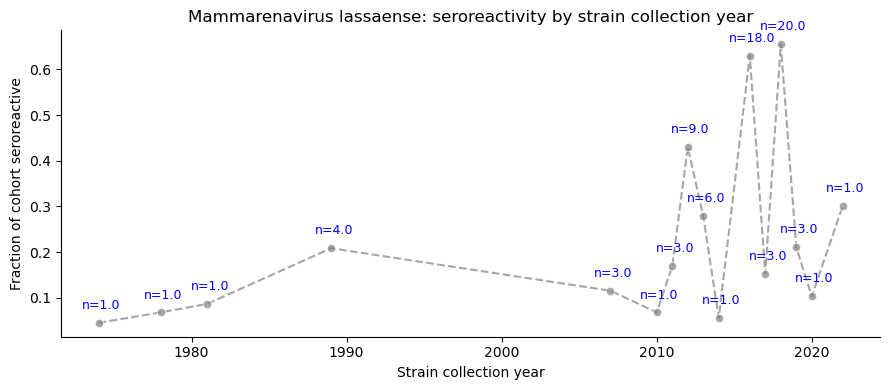

In [ ]:
## looking at seasonality 

SEASONALITY_SPECIES = 'Mammarenavirus lassaense'  # pick your species

#subset to SL 
long_sl = long.loc[long['cohort'] == 'SL'].copy()

species_long = long_sl[long_sl['species'] == SEASONALITY_SPECIES].copy()
species_long['collection_year'] = pd.to_datetime(
    species_long['collection_date_standardized'], errors='coerce'
).dt.year

n_total_peps = species_long['peptide'].nunique()
n_missing_date = species_long.loc[species_long['collection_year'].isna(), 'peptide'].nunique()
print(f'{n_missing_date} of {n_total_peps} peptides for this species have no usable collection date')

species_long = species_long.dropna(subset=['collection_year'])
species_long['collection_year'] = species_long['collection_year'].astype(int)

# per individual, per year: reactive to at least 1 peptide from a strain collected that year?
year_reactivity = (
    species_long.groupby(['collection_year', 'individual'], observed=True)['pass_z_3']
    .max()  # boolean max = "any True in this group"
    .reset_index(name='is_reactive')
)

n_individuals = long['individual'].nunique()  # denominator: whole cohort tested against this panel

fraction_by_year = (
    year_reactivity.groupby('collection_year')['is_reactive']
    .sum()
    .div(n_individuals)
    .reset_index(name='frac_cohort_reactive')
)
fraction_by_year['n_peptides'] = fraction_by_year['collection_year'].map(
    species_long.groupby('collection_year')['peptide'].nunique()
)

fig, ax = plt.subplots(figsize=(9, 4))
sns.lineplot(data=fraction_by_year, x='collection_year', y='frac_cohort_reactive', marker='o', linestyle='--', color='grey', 
             alpha=0.7, ax=ax)
for _, row in fraction_by_year.iterrows():
    ax.annotate(f"n={row['n_peptides']}", (row['collection_year'], row['frac_cohort_reactive']),
                textcoords='offset points', xytext=(2, 10), ha='center', fontsize=9, color='blue')
ax.set_xlabel('Strain collection year')
ax.set_ylabel('Fraction of cohort seroreactive')
ax.set_title(f'{SEASONALITY_SPECIES}: seroreactivity by strain collection year')
sns.despine()
plt.tight_layout()
plt.show()

### ----- OLD CODE

In [ ]:
hits

,peptide,frac_pass_z_in_SL,frac_pass_z_in_US,sequence,species,genus,subfamily,family,order,protein_name,...,HBDB-097,HBDB-098,HBDB-099,HBDB-100,HBDB-102,HBDB-106,HBDB-107,HBDB-109,HBDB-111,HBDB-115
0,XQN14281.1|polymerase|Rodent_Mammarenavirus|FK...,0.088161,0.0,MYEYDLSSGFSWVDLDVKPSIITAAELTRLKITEAGVFDDFWDLWN,Rodent mammarenavirus,Mammarenavirus,NaN,Arenaviridae,Hareavirales,RNA-dependent RNA polymerase,...,False,False,False,False,False,False,False,False,False,False
1,XQN12076.1|polymerase|Mammarenavirus_lassaense...,0.083123,0.0,IEGQFLKVDKSQLLNELNNLYADKVVAEDNIEHLIYQFKRASPILR,Mammarenavirus lassaense,Mammarenavirus,NaN,Arenaviridae,Hareavirales,RNA dependent-RNA polymerase,...,False,False,False,False,False,False,False,False,False,False
2,XQN12074.1|precursor|Mammarenavirus_juninense|...,0.050378,0.0,FVFLALAGRSCTEEAFKIGLHTEFQTVSFSMVGLFSNNPHDLPLLC,Mammarenavirus juninense,Mammarenavirus,NaN,Arenaviridae,Hareavirales,glycoprotein precursor,...,False,False,False,False,False,False,False,False,False,False
3,XQN12074.1|precursor|Mammarenavirus_juninense|...,0.068010,0.0,EFCDMLRLFDYNKNAIKTLNDETKKQVNLMGQTINALISDNLLMKN,Mammarenavirus juninense,Mammarenavirus,NaN,Arenaviridae,Hareavirales,glycoprotein precursor,...,False,False,False,False,False,False,False,False,False,False
4,XQN12073.1|polymerase|Mammarenavirus_juninense...,0.085642,0.0,SEGTKVEITKLKSKNPSVDERESLESLWAPFGVLREIKAEVSMHEV,Mammarenavirus juninense,Mammarenavirus,NaN,Arenaviridae,Hareavirales,RNA dependent-RNA polymerase,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1300,AJP33321.1|polymerase|Cedar_virus|isolate=Geel...,0.078086,0.0,GRPETTWVGNDDSFKYILEHTINRDIGLVHSDMETGIGKDNYTILN,Henipavirus sp.,Henipavirus,Orthoparamyxovirinae,Paramyxoviridae,Mononegavirales,RNA polymerase,...,False,False,False,False,False,False,False,False,False,False
1301,YP_009091833.1|nucleoprotein|Ghana_virus|isola...,0.098237,0.0,LSTAIVESNVGKQELTSATREGRFASSAPNIIEVDEESEDEQPQPR,Henipavirus sp.,Henipavirus,Orthoparamyxovirinae,Paramyxoviridae,Mononegavirales,nucleoprotein,...,False,False,False,False,False,False,False,False,False,False
1302,YP_009091834.1|phosphoprotein|Ghana_virus|isol...,0.095718,0.0,SIQTKPARNASGGDGTNPQMASPPPPPVVTNPPLKKRVPKLSEPNT,Henipavirus sp.,Henipavirus,Orthoparamyxovirinae,Paramyxoviridae,Mononegavirales,phosphoprotein,...,False,False,False,False,False,False,False,False,False,False
1303,YP_009091834.1|phosphoprotein|Ghana_virus|isol...,0.178841,0.0,TREGVIDVHLIKEDNKILNMDQDNPCSNQITSQQETGVTKRGIGEN,Henipavirus sp.,Henipavirus,Orthoparamyxovirinae,Paramyxoviridae,Mononegavirales,phosphoprotein,...,False,False,False,False,False,False,False,False,False,False


In [ ]:
#Boolean mask amd dataframes with True/False value if peptide passes z > 3 for the individual

df_SL_pass_z = (df_SL > 3)
df_hbdb_pass_z = (df_hbdb > 3)

#concatenating the boolean dataframes
df_pass_z_boolean = pd.concat([df_SL_pass_z, df_hbdb_pass_z], axis=1)

#Boolean mask and calculation of fraction of SL and US HBDB samples 'positive' for peptide (z > 3)

df_SL_pos = (df_SL > 3).sum(axis=1) / df_SL.shape[1]
df_hbdb_pos = (df_hbdb > 3).sum(axis=1) / df_hbdb.shape[1]

#generating dataframe which has the fraction of individuals seropositive for the peptide for both SL and US HC
df_fractions = pd.concat([df_SL_pos, df_hbdb_pos], axis=1, keys=['frac_pass_z_3_in_SL', 'frac_pass_z_3_in_US'])
df_fractions = df_fractions.reset_index()

# resetting index and renaming column seq_id to peptide for downstream concatenation operations
peps_metadata = peps_metadata.reset_index().rename(columns={'seq_id': 'peptide'})

NameError: name 'df_SL' is not defined

In [ ]:
#for easier downstream filtering, add the species, genus, family, protein_name an accession ID to which the peptide belongs to 

df_fractions = pd.merge(df_fractions, peps_metadata[['peptide', 'species', 'genus', 'family', 'protein_name', 'accession']], on='peptide', how='left')

#calculate the delta, so the fraction of individuals passing the threshold in SL for that peptide subtracted by the fraction of individuals passing the threshold for that peptide in US HC
df_fractions['delta'] = (
    df_fractions['frac_pass_z_3_in_SL']
    - df_fractions['frac_pass_z_3_in_US']
)

#top_peptides are the ones that have a big delta -> so often enriched in SL but NOT in US HC
top_peptides = (
    df_fractions
    .sort_values('delta', ascending=False)
)

#can sort by species
top_per_species = (
    df_fractions
    .sort_values('delta', ascending=False)
    .groupby('species')
    .head(10)
)

### filter peptides based on sensitivity and specificity

In [ ]:

#calculate the sensitivity, which corresponds to the fraction of SL which pass the z score thresh of 3 for that peptide (True positive rate)
df_fractions['sensitivity'] = df_fractions['frac_pass_z_3_in_SL']

#calculate the specificity, which corresponds to (1 - false positive rate) of US HC which pass the z score thresh of 3 for that peptide (True negative rate)
df_fractions['specificity'] = 1 - df_fractions['frac_pass_z_3_in_US']

#calculate the Youden's -> bigger Youdens means better sensitivity 
df_fractions['youden'] = (df_fractions['sensitivity'] + df_fractions['specificity'] - 1)

In [ ]:
#filter for peptides which satisfy, for example 

hits = df_fractions[
        (df_fractions['sensitivity'] >= 0.05 ) & 
        (df_fractions['specificity'] >= 0.99)
]

#overwrite wrong genus 
hits.loc[hits['genus'] == 'Arenavirus', 'genus'] = 'Mammarenavirus' 

In [ ]:
# add boolean dataframe to hits

df_pass_z_boolean = df_pass_z_boolean.reset_index()

In [ ]:
hits = pd.merge(hits, df_pass_z_boolean, on='peptide', how='left')

In [ ]:
hits['species'].nunique()

314

In [ ]:
long = hits.melt(
    id_vars=['peptide',
 'frac_pass_z_3_in_SL',
 'frac_pass_z_3_in_US',
 'species',
 'genus',
 'family',
 'protein_name',
 'accession',
 'delta',
 'sensitivity',
 'specificity',
 'youden',], 
    var_name='individual', 
    value_name='pass_z_3'
)

In [ ]:
long

,peptide,frac_pass_z_3_in_SL,frac_pass_z_3_in_US,species,genus,family,protein_name,accession,delta,sensitivity,specificity,youden,individual,pass_z_3
0,XQN14281.1|polymerase|Rodent_Mammarenavirus|FK...,0.088161,0.0,Rodent mammarenavirus,Mammarenavirus,Arenaviridae,RNA-dependent RNA polymerase,XQN14281.1,0.088161,0.088161,1.0,0.088161,C-109-3_4_E7,False
1,XQN12076.1|polymerase|Mammarenavirus_lassaense...,0.083123,0.0,Mammarenavirus lassaense,Mammarenavirus,Arenaviridae,RNA dependent-RNA polymerase,XQN12076.1,0.083123,0.083123,1.0,0.083123,C-109-3_4_E7,False
2,XQN12074.1|precursor|Mammarenavirus_juninense|...,0.050378,0.0,Mammarenavirus juninense,Mammarenavirus,Arenaviridae,glycoprotein precursor,XQN12074.1,0.050378,0.050378,1.0,0.050378,C-109-3_4_E7,False
3,XQN12074.1|precursor|Mammarenavirus_juninense|...,0.068010,0.0,Mammarenavirus juninense,Mammarenavirus,Arenaviridae,glycoprotein precursor,XQN12074.1,0.068010,0.068010,1.0,0.068010,C-109-3_4_E7,False
4,XQN12073.1|polymerase|Mammarenavirus_juninense...,0.050378,0.0,Mammarenavirus juninense,Mammarenavirus,Arenaviridae,RNA dependent-RNA polymerase,XQN12073.1,0.050378,0.050378,1.0,0.050378,C-109-3_4_E7,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
640327,AJP33321.1|polymerase|Cedar_virus|isolate=Geel...,0.078086,0.0,Henipavirus sp.,Henipavirus,Paramyxoviridae,RNA polymerase,AJP33321.1,0.078086,0.078086,1.0,0.078086,HBDB-115,False
640328,YP_009091833.1|nucleoprotein|Ghana_virus|isola...,0.098237,0.0,Henipavirus sp.,Henipavirus,Paramyxoviridae,nucleoprotein,YP_009091833.1,0.098237,0.098237,1.0,0.098237,HBDB-115,False
640329,YP_009091834.1|phosphoprotein|Ghana_virus|isol...,0.095718,0.0,Henipavirus sp.,Henipavirus,Paramyxoviridae,phosphoprotein,YP_009091834.1,0.095718,0.095718,1.0,0.095718,HBDB-115,False
640330,YP_009091834.1|phosphoprotein|Ghana_virus|isol...,0.178841,0.0,Henipavirus sp.,Henipavirus,Paramyxoviridae,phosphoprotein,YP_009091834.1,0.178841,0.178841,1.0,0.178841,HBDB-115,False


In [ ]:
#now I can count the number of True values per species / genus / family per individual

summary_count = (
    long.groupby(['family', 'individual'])['pass_z_3']
    .sum()
    .reset_index(name='n_hits')
)

summary_count_genus = (
    long.groupby(['genus', 'individual'])['pass_z_3']
    .sum()
    .reset_index(name='n_hits')
)


summary_count_species = (
    long.groupby(['species', 'individual'])['pass_z_3']
    .sum()
    .reset_index(name='n_hits')
)

In [ ]:
summary_count['category'] = 'HBDB'
summary_count.loc[summary_count['individual'].str.startswith('S-'),'category'] = 'S'
summary_count.loc[summary_count['individual'].str.startswith('C-'), 'category'] = 'C'

summary_count_genus['category'] = 'HBDB'
summary_count_genus.loc[summary_count_genus['individual'].str.startswith('S-'),'category'] = 'S'
summary_count_genus.loc[summary_count_genus['individual'].str.startswith('C-'), 'category'] = 'C'

summary_count_species['category'] = 'HBDB'
summary_count_species.loc[summary_count_species['individual'].str.startswith('S-'),'category'] = 'S'
summary_count_species.loc[summary_count_species['individual'].str.startswith('C-'), 'category'] = 'C'


In [ ]:
summary_count['category'] = pd.Categorical(
    summary_count['category'], 
    categories=['S', 'C', 'HBDB'], 
    ordered=True
)
summary_count = summary_count.sort_values(['category', 'individual'])
individual_order = summary_count['individual'].drop_duplicates()

summary_count_genus['category'] = pd.Categorical(
    summary_count_genus['category'], 
    categories=['S', 'C', 'HBDB'], 
    ordered=True
)
summary_count_genus = summary_count_genus.sort_values(['category', 'individual'])
individual_order_genus = summary_count_genus['individual'].drop_duplicates()

summary_count_species['category'] = pd.Categorical(
    summary_count_species['category'], 
    categories=['S', 'C', 'HBDB'], 
    ordered=True
)
summary_count_species = summary_count_species.sort_values(['category', 'individual'])
individual_order_species = summary_count_species['individual'].drop_duplicates()

### normalize the seroreactive peptide counts by the total number of peptide hits

In [ ]:
hits_tot_family_count = hits.groupby('family')['peptide'].count()
hits_tot_genus_count = hits.groupby('genus')['peptide'].count()

In [ ]:
summary_count['normalized'] = summary_count['n_hits'] / len(hits) * 100

summary_count['normalized_to_total_peps_in_family'] = (
    summary_count['n_hits'] / summary_count['family'].map(hits_tot_family_count) * 100
)

summary_count_genus['normalized'] = summary_count_genus['n_hits'] / len(hits) * 100

summary_count_genus['normalized_to_total_peps_in_genus'] = (
    summary_count_genus['n_hits'] / summary_count_genus['genus'].map(hits_tot_genus_count) * 100
)


In [ ]:
heatmap_df = summary_count.pivot(
    index='family', 
    columns='individual', 
    values='n_hits'
)
#rearranging the columns
heatmap_df = heatmap_df[individual_order]

heatmap_df_genus = summary_count_genus.pivot(
    index='genus', 
    columns='individual', 
    values='n_hits'
)
#rearranging the columns
heatmap_df_genus = heatmap_df_genus[individual_order_genus]

In [ ]:
#displaying normalized num hits

heatmap_df = summary_count.pivot(
    index='family', 
    columns='individual', 
    values='normalized_to_total_peps_in_family'
)
#rearranging the columns
heatmap_df = heatmap_df[individual_order]

heatmap_df_genus = summary_count_genus.pivot(
    index='genus', 
    columns='individual', 
    values='normalized_to_total_peps_in_genus'
)
#rearranging the columns
heatmap_df_genus = heatmap_df_genus[individual_order_genus]

In [ ]:
heatmap_df

individual,S-104_SA1_A3,S-105_SA1_A4,S-106_SA1_A8,S-107_SA1_A9,S-109_SA1_B1,S-110_SA1_B2,S-111_SA1_A1,S-112_SA1_B3,S-113_SA1_B4,S-114_SA1_B5,...,HBDB-097,HBDB-098,HBDB-099,HBDB-100,HBDB-102,HBDB-106,HBDB-107,HBDB-109,HBDB-111,HBDB-115
family,,,,,,,,,,,,,,,,,,,,,
Arenaviridae,4.411765,15.882353,15.294118,12.352941,16.176471,8.529412,15.588235,3.529412,10.294118,3.529412,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Filoviridae,4.255319,6.382979,0.000000,6.382979,2.127660,8.510638,6.382979,4.255319,8.510638,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Flaviviridae,7.843137,5.882353,3.921569,5.882353,7.843137,5.882353,5.882353,3.921569,15.686275,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Hantaviridae,6.097561,6.707317,4.268293,2.439024,5.487805,10.365854,6.097561,3.658537,8.536585,9.756098,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Konkoviridae,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Matonaviridae,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Nairoviridae,7.988166,9.763314,8.284024,5.621302,11.538462,9.171598,10.059172,3.550296,9.763314,4.437870,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Paramyxoviridae,6.250000,6.250000,6.250000,2.083333,12.500000,4.166667,8.333333,6.250000,4.166667,6.250000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Phenuiviridae,9.748428,11.949686,9.748428,4.088050,11.635220,9.748428,8.490566,5.974843,6.918239,6.603774,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


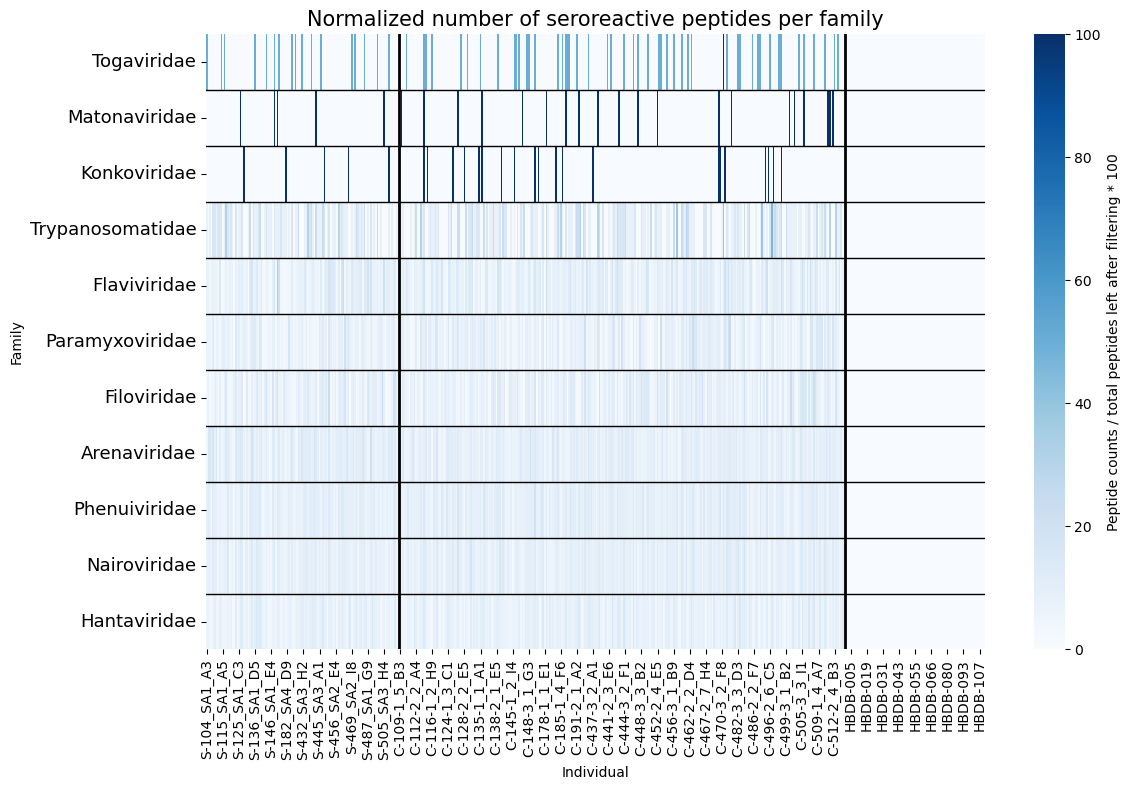

In [ ]:
#displaying normalized num hits


import seaborn as sns
import matplotlib.pyplot as plt 

plt.figure(figsize=(12,8))

#sort by maximum value in each row
heatmap_df = heatmap_df.loc[heatmap_df.max(axis=1).sort_vales(ascending=False).index]


ax = sns.heatmap(
    heatmap_df, 
    cmap='Blues', 
    cbar_kws={'label': 'Peptide counts / total peptides left after filtering * 100'}, 
)

ordered = summary_count[["individual", "category"]].drop_duplicates()

boundaries = (
    ordered["category"]
    .ne(ordered["category"].shift()) #ne is a pandas method for not equal (!=). it finds the boundaries between groups
    .to_numpy()
    .nonzero()[0][1:] #extracts the positions where the comparison is True. nonzero returns a tuple, so we take the first element
    #[1:] skips the very first True, because it isn't a real boundary. 
)

for b in boundaries:
    ax.axvline(b, color="black", lw=2)

for y in range(1, len(heatmap_df)): #counts number of rows
    ax.axhline(y, color='black', linewidth=1)

plt.xlabel('Individual')
plt.ylabel('Family')
plt.yticks(fontsize=13)
plt.title('Normalized number of seroreactive peptides per family', fontsize=15)
plt.tight_layout()
plt.show()

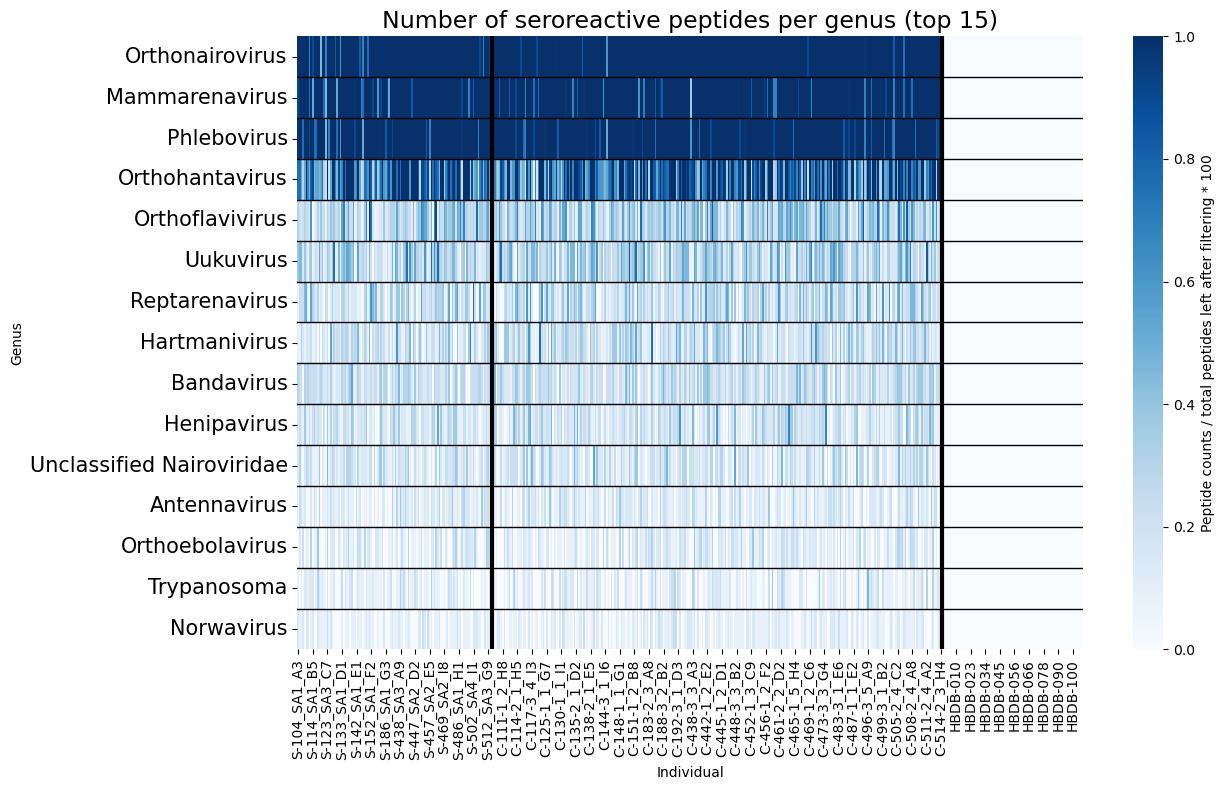

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt 

plt.figure(figsize=(13,8))

#sort highest to lowest in heatmap
heatmap_df_genus = heatmap_df_genus.loc[heatmap_df_genus.mean(axis=1).sort_values(ascending=False).index]


ax = sns.heatmap(
    heatmap_df_genus.head(15), 
    cmap='Blues', 
    cbar_kws={'label': 'Peptide counts / total peptides left after filtering * 100'},
    vmin=0, 
    vmax=1
)

ordered = summary_count_genus[["individual", "category"]].drop_duplicates()

boundaries = (
    ordered["category"]
    .ne(ordered["category"].shift()) #ne is a pandas method for not equal (!=). it finds the boundaries between groups
    .to_numpy()
    .nonzero()[0][1:] #extracts the positions where the comparison is True. nonzero returns a tuple, so we take the first element
    #[1:] skips the very first True, because it isn't a real boundary. 
)

for b in boundaries:
    ax.axvline(b, color="black", lw=3)


for y in range(1, len(heatmap_df_genus.head(15))): #counts number of rows
    ax.axhline(y, color='black', linewidth=1)

plt.xlabel('Individual')
plt.ylabel('Genus')
plt.yticks(fontsize=15)
plt.title('Number of seroreactive peptides per genus (top 15)', fontsize=17)
plt.tight_layout()
plt.show()

### finding individuals to test with ELISA for DENV and Ebolavirus zaire

In [ ]:
master_denguei = master.loc[master['value'] == 'Orthoflavivirus denguei']

master_denguei_top = master_denguei.sort_values(by='sum_rpk', ascending=False).head(40)

master_denguei_bottom = master_denguei.sort_values(by='sum_rpk', ascending=True).head(40)

In [ ]:
master_denguei_bottom

,level,value,individual,category,n_hits,mean_rpk,sum_rpk,max_rpk,n_peptides_for_taxon,frac_of_individual_hits,frac_of_total_taxon_hits,is_seropositive,frac_of_individual_hits_confirmed
81749,species,Orthoflavivirus denguei,S-448_SA2_C2,S,0,0.090956,2.910581,2.328465,32,0.000000,0.00000,False,0.000000
81406,species,Orthoflavivirus denguei,C-181-3_2_I9,C,0,0.097648,3.124731,2.343549,32,0.000000,0.00000,False,0.000000
81352,species,Orthoflavivirus denguei,C-128-2_2_E5,C,0,0.131777,4.216872,3.116818,32,0.000000,0.00000,False,0.000000
81695,species,Orthoflavivirus denguei,S-124_SA1_C2,S,1,0.237885,7.612312,4.498184,32,0.012821,0.03125,False,0.000000
81416,species,Orthoflavivirus denguei,C-188-2_5_C2,C,0,0.252723,8.087144,3.516150,32,0.000000,0.00000,False,0.000000
81382,species,Orthoflavivirus denguei,C-145-1_2_I4,C,1,0.292307,9.353835,2.707689,32,0.016949,0.03125,False,0.000000
81536,species,Orthoflavivirus denguei,C-488-2_3_F7,C,0,0.294338,9.418818,1.842812,32,0.000000,0.00000,False,0.000000
81719,species,Orthoflavivirus denguei,S-150_SA1_E9,S,1,0.321836,10.298758,4.681253,32,0.016129,0.03125,False,0.000000
81794,species,Orthoflavivirus denguei,S-513_SA3_I2,S,1,0.384299,12.297575,9.061371,32,0.013699,0.03125,False,0.000000
81724,species,Orthoflavivirus denguei,S-180_SA1_G5,S,1,0.413338,13.226832,5.840419,32,0.010989,0.03125,False,0.000000


In [ ]:
master_denguei_top

,level,value,individual,category,n_hits,mean_rpk,sum_rpk,max_rpk,n_peptides_for_taxon,frac_of_individual_hits,frac_of_total_taxon_hits,is_seropositive,frac_of_individual_hits_confirmed
81386,species,Orthoflavivirus denguei,C-146-2_1_F7,C,5,34.039925,1089.277598,473.289847,32,0.042373,0.15625,True,0.042373
81784,species,Orthoflavivirus denguei,S-502_SA4_I1,S,2,33.945879,1086.268125,1060.263219,32,0.022472,0.06250,True,0.022472
81720,species,Orthoflavivirus denguei,S-151_SA1_F1,S,11,33.689831,1078.074599,685.340651,32,0.065089,0.34375,True,0.065089
81790,species,Orthoflavivirus denguei,S-509_SA3_H6,S,3,26.819029,858.208928,835.064133,32,0.035294,0.09375,True,0.035294
81488,species,Orthoflavivirus denguei,C-461-1_3_F1,C,4,26.761557,856.369835,749.132414,32,0.028169,0.12500,True,0.028169
81357,species,Orthoflavivirus denguei,C-133-2_1_H1,C,6,20.918784,669.401087,612.358540,32,0.053097,0.18750,True,0.053097
81562,species,Orthoflavivirus denguei,C-505-3_3_I1,C,9,19.945029,638.240926,371.449356,32,0.049724,0.28125,True,0.049724
81567,species,Orthoflavivirus denguei,C-507-2_3_H3,C,8,19.800533,633.617050,449.296403,32,0.056738,0.25000,True,0.056738
81755,species,Orthoflavivirus denguei,S-454_SA2_I5,S,5,17.794685,569.429916,518.599634,32,0.054348,0.15625,True,0.054348
81437,species,Orthoflavivirus denguei,C-439-2_2_B9,C,5,16.947366,542.315726,301.356418,32,0.054348,0.15625,True,0.054348


In [ ]:
def species_reactivity(species):
    for species in species:
        subset = master.loc[master['value'] == species]
        top_responders = subset.sort_values(by='sum_rpk', ascending=False).head(20)
        bottom_responders = subset.sort_values(by='sum_rpk', ascending=True).head(20)
    print('top_responders', top_responders, 'bottom_responders', bottom_responders)

In [ ]:
species_reactivity('Orthoflavivirus denguei')

top_responders Empty DataFrame
Columns: [level, value, individual, category, n_hits, mean_rpk, sum_rpk, max_rpk, n_peptides_for_taxon, frac_of_individual_hits, frac_of_total_taxon_hits, is_seropositive, frac_of_individual_hits_confirmed]
Index: [] bottom_responders Empty DataFrame
Columns: [level, value, individual, category, n_hits, mean_rpk, sum_rpk, max_rpk, n_peptides_for_taxon, frac_of_individual_hits, frac_of_total_taxon_hits, is_seropositive, frac_of_individual_hits_confirmed]
Index: []
top_responders Empty DataFrame
Columns: [level, value, individual, category, n_hits, mean_rpk, sum_rpk, max_rpk, n_peptides_for_taxon, frac_of_individual_hits, frac_of_total_taxon_hits, is_seropositive, frac_of_individual_hits_confirmed]
Index: [] bottom_responders Empty DataFrame
Columns: [level, value, individual, category, n_hits, mean_rpk, sum_rpk, max_rpk, n_peptides_for_taxon, frac_of_individual_hits, frac_of_total_taxon_hits, is_seropositive, frac_of_individual_hits_confirmed]
Index: []
to

## now look at individual species within those genuses

### select some viral species of each genus of interest to look into

Genuses of interest: 
Bandavirus
Henipavirus
Orthoebolavirus
Orthoflavivirus
Orthohantavirus
Orthonairovirus
Phlebovirus
Unclassified Nairoviridae
Uukuvirus


In [ ]:
species_most_pep_counts = {'Alphavirus': 'Alphavirus chikungunya',
                           'Bandavirus': 'Bandavirus bhanjanagarense', 
                           'Henipavirus': 'Henipavirus sp.', 
                           'Mammarenavirus': 'Mammarenavirus lassaense', 
                           #'Morbillivirus': 'Measles morbillivirus', 
                           #'Norwavirus': 'Norwavirus sp.', 
                           'Orthoebolavirus': 'Orthoebolavirus bundibugyoense', 
                           'Orthoebolavirus': 'Orthoebolavirus zairense', 
                           'Orthoflavivirus': 'Orthoflavivirus denguei', 
                           'Orthohantavirus': 'Orthohantavirus sp.', 
                           'Orthomarburgvirus': 'Orthomarburgvirus marburgense', 
                           'Orthonairovirus': 'Orthonairovirus haemorrhagiae', 
                           #'Orthorubulavirus': 'Mumps orthorubulavirus', 
                           #'Parahenipavirus': 'Parahenipavirus sp.', 
                           'Phlebovirus': 'Phlebovirus candiruense', 
                           #'Pidchovirus': 'Pidchovirus pidgei', 
                           #'Plasmodium': 'Plasmodium falciparum', 
                           #'Unclassified Nairovidiae': 'Nairoviridae sp.', 
                           'Uukuvirus': 'Uukuvirus uukuniemiense', 
                           'HIV': 'HIV-1'
                           
                           
                           }

In [ ]:
summary_count_species

filtered = summary_count_species[
    summary_count_species['species'].isin(species_most_pep_counts.values())
]

In [ ]:
filtered['normalized'] = filtered['n_hits'] / len(hits) * 100

/tmp/ipykernel_2986727/3975831384.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered['normalized'] = filtered['n_hits'] / len(hits) * 100


In [ ]:
heatmap_df_sp_filtered = filtered.pivot(
    index='species', 
    columns='individual', 
    values='n_hits'
)
#rearranging the columns
heatmap_df_sp_filtered = heatmap_df_sp_filtered[individual_order_species]

In [ ]:
#use the normalized version

heatmap_df_sp_filtered = filtered.pivot(
    index='species', 
    columns='individual', 
    values='normalized'
)
#rearranging the columns
heatmap_df_sp_filtered = heatmap_df_sp_filtered[individual_order_species]

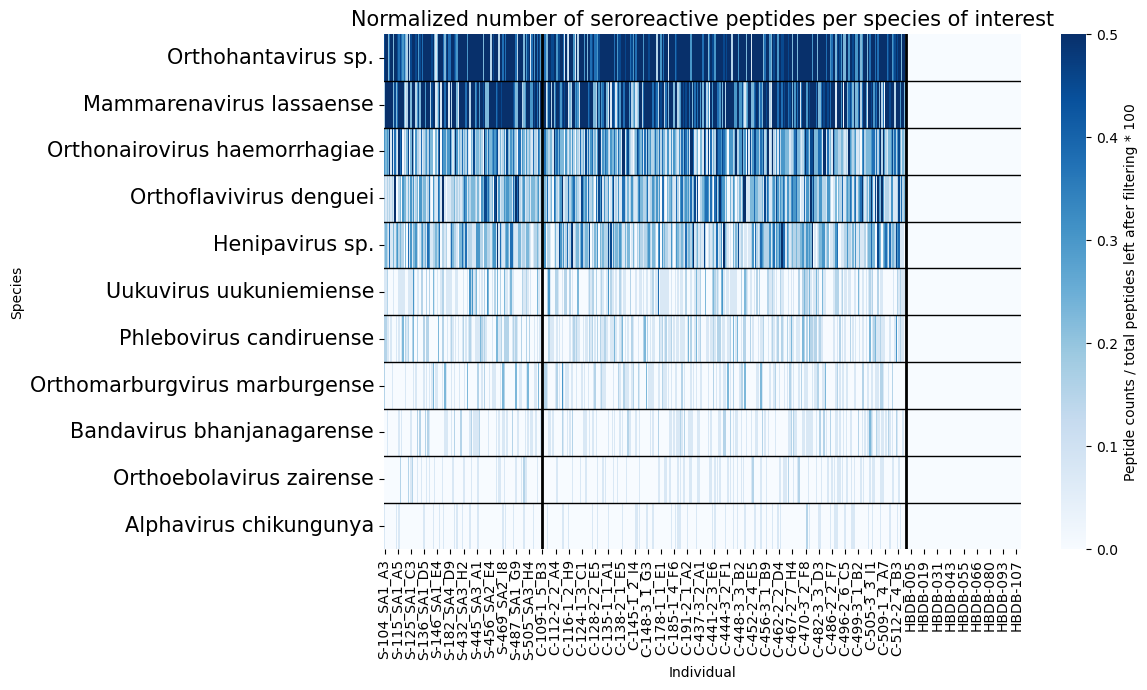

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt 

plt.figure(figsize=(12,7))

heatmap_df_sp_filtered = heatmap_df_sp_filtered.loc[heatmap_df_sp_filtered.mean(axis=1).sort_values(ascending=False).index]

ax = sns.heatmap(
    heatmap_df_sp_filtered , 
    cmap='Blues', 
    cbar_kws={'label': 'Peptide counts / total peptides left after filtering * 100'}, 
    vmin=0, 
    vmax=0.5
)

ordered = summary_count_genus[["individual", "category"]].drop_duplicates()

boundaries = (
    ordered["category"]
    .ne(ordered["category"].shift()) #ne is a pandas method for not equal (!=). it finds the boundaries between groups
    .to_numpy()
    .nonzero()[0][1:] #extracts the positions where the comparison is True. nonzero returns a tuple, so we take the first element
    #[1:] skips the very first True, because it isn't a real boundary. 
)

for b in boundaries:
    ax.axvline(b, color="black", lw=2)


for l in range(1,len(heatmap_df_sp_filtered)):
    ax.axhline(l, color="black", lw=1)

plt.xlabel('Individual')
plt.ylabel('Species')
plt.yticks(fontsize=15)
plt.title('Normalized number of seroreactive peptides per species of interest', fontsize=15)
plt.tight_layout()
plt.show()

### now look at the rpk enrichment of these species 

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np


def species_boxplot(data,  metadata, species:str, agg = "mean", dtype = "z_score"):
    """
    Parameters:
    - data: Pandas DataFrame containing the z score data 
    - x_var: column name 

    """
    species_peps = metadata[metadata['species'] == species]
    df_subset = data.loc[species_peps.index]
    
    #define group Sierra Leone (SL) vs HBDB
    sl_cols = [c for c in df_subset.columns if c.startswith(("C", "S"))]
    hbdb_cols = [c for c in df_subset.columns if c.startswith("HBDB")]

    #with the agg function, each individual (column) gets one value. returns a Series, so a single vector

    if agg == 'mean':
        sl_summary = df_subset[sl_cols].mean(axis=0, skipna=True)
        hbdb_summary=df_subset[hbdb_cols].mean(axis=0, skipna=True)

    elif agg == 'median':
        sl_summary = df_subset[sl_cols].median(axis=0, skipna=True)
        hbdb_summary=df_subset[hbdb_cols].median(axis=0, skipna=True)

    elif agg == 'max':
        sl_summary = df_subset[sl_cols].max(axis=0, skipna=True)
        hbdb_summary=df_subset[hbdb_cols].max(axis=0, skipna=True)

    elif agg == 'sum':
        sl_summary = df_subset[sl_cols].sum(axis=0, skipna=True)
        hbdb_summary=df_subset[hbdb_cols].sum(axis=0, skipna=True)

    else:
        raise ValueError("agg must be one of: 'mean', 'median' 'max', 'sum'")
 
    plot_df = pd.DataFrame({
        "value": pd.concat([sl_summary, hbdb_summary], axis=0).values,
        "group": ["SL"] * len(sl_summary.index)+ ["HBDB"] * len(hbdb_summary.index),
        "individual": list(sl_summary.index) +list(hbdb_summary.index)
    })

    
    print(df_subset.columns.tolist())
    
    sns.boxplot(data = plot_df, x = "group", y = "value")
    sns.stripplot(data=plot_df, x="group", y="value", color="black", alpha=0.6, jitter=True)
    plt.title(f"{species} peptides \n {agg} enrichment per individual", fontsize=13)
    plt.ylabel(f'{agg} {dtype} score')

    plt.savefig(f'./.png/{species}_max_{dtype}_enrichment_sl_hbdb_boxplot.png', dpi=300, bbox_inches='tight')
    plt.show()




In [ ]:
df_concat_rpk = df_concat_rpk.set_index('peptide')
df_concat_rpk_hits = df_concat_rpk.loc[hits['peptide']]

In [ ]:
df_concat_rpk_hits_log = np.log2(df_concat_rpk_hits+1)

In [ ]:
species_list = list(species_most_pep_counts.values())
peps_metadata = peps_metadata.set_index('peptide')

In [ ]:
peps_metadata_hits = peps_metadata.loc[hits['peptide']]

In [ ]:
df_concat_hits = df_concat.loc[hits['peptide']]

## select most seroreactive individuals for Tulane to orthogonally validate with ELISAs

In [ ]:
ebov_list = ['Orthoebolavirus zairense']
marburg_list = ['Orthomarburgvirus marburgense']
denv_list = ['Orthoflavivirus denguei']
cchfv_list = ['Orthonairovirus haemorrhagiae']
lasv_list = ['Mammarenavirus lassaense']

In [ ]:
import pandas as pd
peps_metadata_hits_hanta = peps_metadata_hits[peps_metadata_hits['species'].isin(['Orthohantavirus sp.'])]
peps_metadata_hits_ebov = peps_metadata_hits[peps_metadata_hits['species'].isin(ebov_list)]
peps_metadata_hits_marburg = peps_metadata_hits[peps_metadata_hits['species'].isin(marburg_list)]
peps_metadata_hits_denv = peps_metadata_hits[peps_metadata_hits['species'].isin(denv_list)]
peps_metadata_hits_cchfv = peps_metadata_hits[peps_metadata_hits['species'].isin(cchfv_list)]
peps_metadata_hits_lasv = peps_metadata_hits[peps_metadata_hits['species'].isin(lasv_list)]

In [ ]:
peps_metadata_hits.groupby('species').size().sort_values(ascending=False)

species
Orthohantavirus sp.              104
Mammarenavirus lassaense          77
Orthonairovirus haemorrhagiae     40
Orthoflavivirus denguei           32
Henipavirus sp.                   30
                                ... 
Tick phlebovirus                   1
Aershan mammarenavirus             1
Uukuvirus kabutoense               1
Yunnan shrew mammarenavirus 1      1
Zika virus vector pZIKV-ICD        1
Length: 314, dtype: int64

In [ ]:
#ebolavirus zairense top and poor responders for Tulane to orthogonally validate

import re 
df_concat_rpk_hits_log_SL_cols = df_concat_rpk_hits_log.filter(regex=('(C-|S-)'), axis=1)

ebov_descending = df_concat_rpk_hits_log_SL_cols.loc[peps_metadata_hits_ebov.index].sum(axis=0).sort_values(ascending=False)
ebov_us = df_hbdb_rpk.loc[peps_metadata_hits_ebov.index].sum(axis=0).sort_values(ascending=False)
ebov_descending_top_50 = ebov_descending.iloc[0:50]
ebov_descending_tail_30 = ebov_descending.iloc[-30:]

ebov = pd.DataFrame(pd.concat([ebov_us, ebov_descending_top_50, ebov_descending_tail_30])).reset_index()
ebov['category'] = 'US'
ebov.loc[ebov['index'].isin(ebov_descending_tail_30.index), 'category'] = 'tail'
ebov.loc[ebov['index'].isin(ebov_descending_top_50.index), 'category'] = 'top'


#DENV top and poor responders for Tulane to orthogonally validate with ELISA

denv_descending = df_concat_rpk_hits_log_SL_cols.loc[peps_metadata_hits_denv.index].sum(axis=0).sort_values(ascending=False)
us_denv = df_hbdb_rpk.loc[peps_metadata_hits_denv.index].sum(axis=0).sort_values(ascending=False)

denv_descending_top_50 = denv_descending.iloc[0:50]
denv_descending_tail_30 = denv_descending.iloc[-30:]

denv = pd.DataFrame(pd.concat([us_denv, denv_descending_top_50, denv_descending_tail_30])).reset_index()
denv['category'] = 'US'
denv.loc[denv['index'].isin(denv_descending_tail_30.index), 'category'] = 'tail'
denv.loc[denv['index'].isin(denv_descending_top_50.index), 'category'] = 'top'

#SSHFV top and poor responders for Tulane to orthogonally validate with ELISA

cchfv_descending = df_concat_rpk_hits_log_SL_cols.loc[peps_metadata_hits_cchfv.index].sum(axis=0).sort_values(ascending=False)
us_cchfv= df_hbdb_rpk.loc[peps_metadata_hits_cchfv.index].sum(axis=0).sort_values(ascending=False)

cchfv_descending_top_50 = cchfv_descending.iloc[0:50]
cchfv_descending_tail_30 = cchfv_descending.iloc[-30:]

cc = pd.DataFrame(pd.concat([us_cchfv, cchfv_descending_top_50, cchfv_descending_tail_30])).reset_index()
cc['category'] = 'US'
cc.loc[cc['index'].isin(cchfv_descending_tail_30.index), 'category'] = 'tail'
cc.loc[cc['index'].isin(cchfv_descending_top_50.index), 'category'] = 'top'


#LASV top and poor responders for Tulane to orthogonally validate with ELISA

lasv_descending = df_concat_rpk_hits_log_SL_cols.loc[peps_metadata_hits_lasv.index].sum(axis=0).sort_values(ascending=False)

us_lasv= df_hbdb_rpk.loc[peps_metadata_hits_lasv.index].sum(axis=0).sort_values(ascending=False)

lasv_descending_top_50 = lasv_descending.iloc[0:50]
lasv_descending_tail_30 = lasv_descending.iloc[-30:]

l = pd.DataFrame(pd.concat([us_lasv, lasv_descending_top_50, lasv_descending_tail_30])).reset_index()
l['category'] = 'US'
l.loc[l['index'].isin(lasv_descending_tail_30.index), 'category'] = 'tail'
l.loc[l['index'].isin(lasv_descending_top_50.index), 'category'] = 'top'


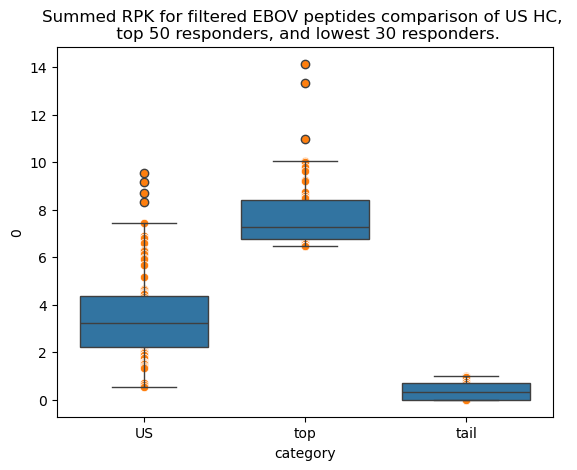

In [ ]:
import matplotlib.pyplot as plt 
import seaborn as sns
sns.boxplot(data=ebov, x='category', y=0)

sns.scatterplot(data=ebov, x='category', y=0)

plt.title('Summed RPK for filtered EBOV peptides comparison of US HC, \n top 50 responders, and lowest 30 responders.')
plt.show()

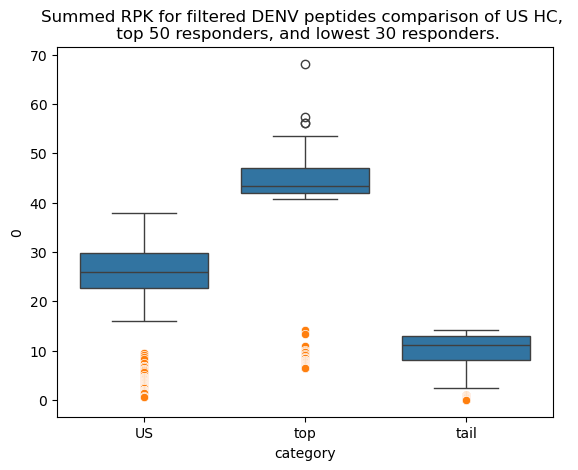

In [ ]:
import matplotlib.pyplot as plt 
import seaborn as sns
sns.boxplot(data=denv, x='category', y=0)

sns.scatterplot(data=ebov, x='category', y=0)

plt.title('Summed RPK for filtered DENV peptides comparison of US HC, \n top 50 responders, and lowest 30 responders.')
plt.show()

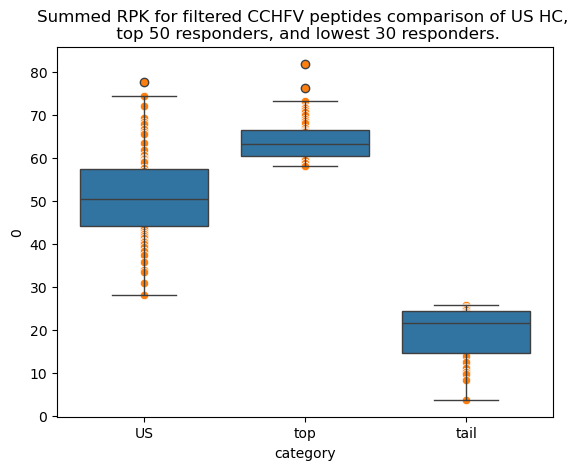

In [ ]:
import matplotlib.pyplot as plt 
import seaborn as sns
sns.boxplot(data=cc, x='category', y=0)

sns.scatterplot(data=cc, x='category', y=0)

plt.title('Summed RPK for filtered CCHFV peptides comparison of US HC, \n top 50 responders, and lowest 30 responders.')
plt.show()

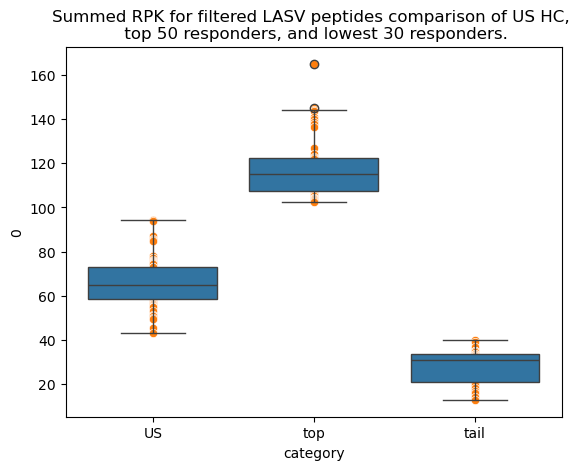

In [ ]:
import matplotlib.pyplot as plt 
import seaborn as sns
sns.boxplot(data=l, x='category', y=0)

sns.scatterplot(data=l, x='category', y=0)

plt.title('Summed RPK for filtered LASV peptides comparison of US HC, \n top 50 responders, and lowest 30 responders.')
plt.show()

In [ ]:
peps_metadata_hits.loc[peps_metadata_hits['species'] == 'Orthonairovirus haemorrhagiae']

,sequence,accession,protein_name,gene,segment,order,family,subfamily,genus,species,isolate,taxonomy_lineage,collection_date,geo_loc_name,host,protein_std,fragment,collection_date_standardized
peptide,,,,,,,,,,,,,,,,,,
XQQ58340.1|polymerase|Orthonairovirus_haemorrhagiae|isolate=CCHFV_6_161|Hyalomma_anatolicum|Tajikistan|26-May-2023|segment=L|strain=?|tile_41,AGTATKTPVSTKDVLETWERMKEHIVNRPTGLTLPASLEQAMRKGL,XQQ58340.1,RNA-dependent RNA polymerase,NaN,L,Hareavirales,Nairoviridae,NaN,Orthonairovirus,Orthonairovirus haemorrhagiae,CCHFV_6_161,Viruses;Riboviria;Orthornavirae;Negarnaviricot...,26-May-23,Tajikistan,Hyalomma anatolicum,polymerase,41,5/26/23
XQQ58340.1|polymerase|Orthonairovirus_haemorrhagiae|isolate=CCHFV_6_161|Hyalomma_anatolicum|Tajikistan|26-May-2023|segment=L|strain=?|tile_101,RNLLKTTSDDGLTNPHLKETILNVGLDCLTNMRNLDGKPINEGSNL,XQQ58340.1,RNA-dependent RNA polymerase,NaN,L,Hareavirales,Nairoviridae,NaN,Orthonairovirus,Orthonairovirus haemorrhagiae,CCHFV_6_161,Viruses;Riboviria;Orthornavirae;Negarnaviricot...,26-May-23,Tajikistan,Hyalomma anatolicum,polymerase,101,5/26/23
XQQ58340.1|polymerase|Orthonairovirus_haemorrhagiae|isolate=CCHFV_6_161|Hyalomma_anatolicum|Tajikistan|26-May-2023|segment=L|strain=?|tile_119,SRTSSTVEDSSSVSDTTVASHDSGSSSSSFSFELNRPLSETELQFI,XQQ58340.1,RNA-dependent RNA polymerase,NaN,L,Hareavirales,Nairoviridae,NaN,Orthonairovirus,Orthonairovirus haemorrhagiae,CCHFV_6_161,Viruses;Riboviria;Orthornavirae;Negarnaviricot...,26-May-23,Tajikistan,Hyalomma anatolicum,polymerase,119,5/26/23
XQQ58330.1|precursor|Orthonairovirus_haemorrhagiae|isolate=CCHFV_B.D.33|Homo_sapiens|Tajikistan|04-Jul-2017|segment=M|strain=?|tile_58,CKLQSCTHGVPGDLQVYHIGNLLKGDKINGHMIHKIEPHFNTSWMS,XQQ58330.1,glycoprotein precursor,NaN,M,Hareavirales,Nairoviridae,NaN,Orthonairovirus,Orthonairovirus haemorrhagiae,CCHFV_C16,Viruses;Riboviria;Orthornavirae;Negarnaviricot...,4-Jul-17,Tajikistan,Homo sapiens,glycoprotein,58,7/4/17
XPD10979.1|polymerase|Orthonairovirus_haemorrhagiae|isolate=622-STV-TI-2021|tick|Russia|2021|segment=L|strain=?|tile_117,PTYSGLVSSAVALEDAEVIARAAQTLSMNSVSMQSSSLTTLDGLGR,XPD10979.1,RNA-dependent RNA polymerase,NaN,L,Hareavirales,Nairoviridae,NaN,Orthonairovirus,Orthonairovirus haemorrhagiae,622-STV-TI-2021,Viruses;Riboviria;Orthornavirae;Negarnaviricot...,2021,Russia,tick,polymerase,117,2021
XPD10977.1|protein|Orthonairovirus_haemorrhagiae|isolate=622-STV-TI-2021|tick|Russia|2021|segment=S|strain=?|tile_11,VATGLAKLAETEGKGIFEEARKTVDALKDYLDRHKEEVDKTNADNM,XPD10977.1,nucleocapsid protein,NaN,S,Hareavirales,Nairoviridae,NaN,Orthonairovirus,Orthonairovirus haemorrhagiae,622-STV-TI-2021,Viruses;Riboviria;Orthornavirae;Negarnaviricot...,2021,Russia,tick,nucleoprotein,11,2021
XPD10970.1|glycoprotein|Orthonairovirus_haemorrhagiae|isolate=372-ARM-TI-2022|tick|Armenia|2022|segment=M|strain=?|tile_28,VKLSRGSEVVLDACDSSCEVMIPKGTGDILVDCSGGQQHFLKDNLI,XPD10970.1,envelope glycoprotein,NaN,M,Hareavirales,Nairoviridae,NaN,Orthonairovirus,Orthonairovirus haemorrhagiae,372-ARM-TI-2022,Viruses;Riboviria;Orthornavirae;Negarnaviricot...,2022,Armenia,tick,glycoprotein,28,2022
XMH26469.1|precursor|Orthonairovirus_haemorrhagiae|isolate=?|Rhipicephalus_senegalensis|Senegal|Aug-2022|segment=M|strain=ARD401180|tile_4,SEGSGEVYTSPPITTGSLPLPETTPELPATTGTDTSSASDVDSSTQ,XMH26469.1,glycoprotein precursor,NaN,M,Hareavirales,Nairoviridae,NaN,Orthonairovirus,Orthonairovirus haemorrhagiae,NaN,Viruses;Riboviria;Orthornavirae;Negarnaviricot...,22-Aug,Senegal,Rhipicephalus senegalensis,glycoprotein,4,2022-08
XMH26469.1|precursor|Orthonairovirus_haemorrhagiae|isolate=?|Rhipicephalus_senegalensis|Senegal|Aug-2022|segment=M|strain=ARD401180|tile_10,LTQSATPGPMTSPTQIVHLQSATPITVQDTSPSPTNRSKRNLEMEI,XMH26469.1,glycoprotein precursor,NaN,M,Hareavirales,Nairoviridae,NaN,Orthonairovirus,Orthonairovirus haemorrhagiae,NaN,Viruses;Riboviria;Orthornavirae;Negarnaviricot...,22-Aug,Senegal,Rhipicephalus senegalensis,glycoprotein,10,2022-08


### for those top and tail responders, look at the reactivity on a whole-peptide belonging to that species level (so not filtered to top peptides, sanity check). also include US healthies in the sanity check. 

#### start with EBOV zaire

In [ ]:
#looking at ebov zaire responders
peps_metadata_ebov = peps_metadata[peps_metadata['species'].isin(ebov_list)]
df_concat_rpk_ebov = df_concat_rpk.loc[peps_metadata_ebov.index]
top_ebov = df_concat_rpk_ebov[ebov_descending_top_50.index]
bottom_ebov = df_concat_rpk_ebov[ebov_descending_tail_30.index]
us_ebov = df_concat_rpk_ebov.filter(regex='HBDB-', axis=1)

In [ ]:
#log transform for plotting
top_ebov = np.log2(top_ebov +1)
bottom_ebov = np.log2(bottom_ebov +1)
us_ebov = np.log2(us_ebov +1)

In [ ]:
df_concat_rpk_ebov = df_concat.loc[peps_metadata_ebov.index]
top_ebov = df_concat_rpk_ebov[ebov_descending_top_50.index]
bottom_ebov = df_concat_rpk_ebov[ebov_descending_tail_30.index]
us_ebov = df_concat_rpk_ebov.filter(regex='HBDB-', axis=1)

In [ ]:
top_ebov.max(axis=0).sort_values(ascending=False).head(8)

S-502_SA4_I1    119.250744
C-445-1_2_D1     38.870016
C-452-1_3_C9     34.301551
C-485-2_2_H6     20.984519
S-126_SA1_C4     19.886639
C-128-2_2_E5     18.000945
C-437-1_2_H2     17.002945
C-443-1_3_G2     13.460114
dtype: float64

In [ ]:
bottom_ebov.max(axis=0).sort_values(ascending=False).head(8)

C-145-1_2_I4    14.643686
C-510-3_3_I4    13.978151
C-434-2_2_B7    13.041445
S-450_SA3_G1    13.011023
S-180_SA1_G5    12.150336
C-443-2_2_G9    11.594475
S-448_SA2_C2    10.870260
C-447-3_1_C8    10.781048
dtype: float64

In [ ]:
us_ebov.max(axis=0).sort_values(ascending=False).head(8)

HBDB-034    35.121718
HBDB-028    26.986761
HBDB-045    20.141838
HBDB-054    19.452411
HBDB-074    18.555081
HBDB-023    16.873129
HBDB-062    16.675546
HBDB-050    16.649822
dtype: float64

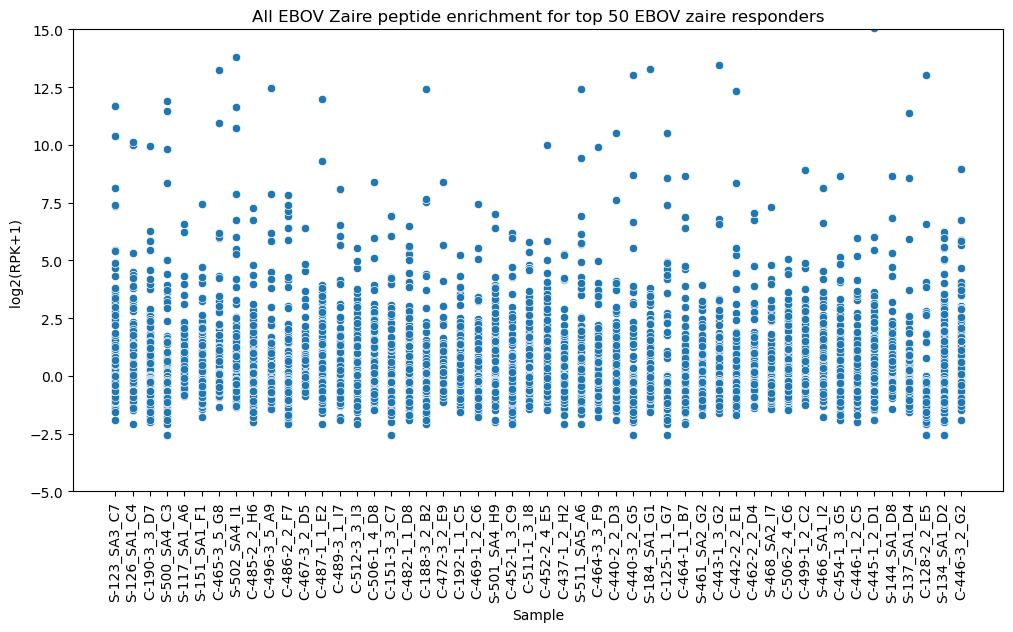

In [ ]:
import matplotlib.pyplot as plt


top_ebov_long = top_ebov.reset_index().melt(
    id_vars='peptide', 
    var_name='sample_ID', 
    value_name='raw_RPK'
)

plt.figure(figsize=(12,6))
sns.scatterplot(
    data=top_ebov_long, 
    x='sample_ID', 
    y='raw_RPK', 
)

plt.ylim(-5, 15)
plt.xticks(rotation=90)
plt.xlabel("Sample")
plt.title("All EBOV Zaire peptide enrichment for top 50 EBOV zaire responders")
plt.ylabel("log2(RPK+1) ")
plt.show()

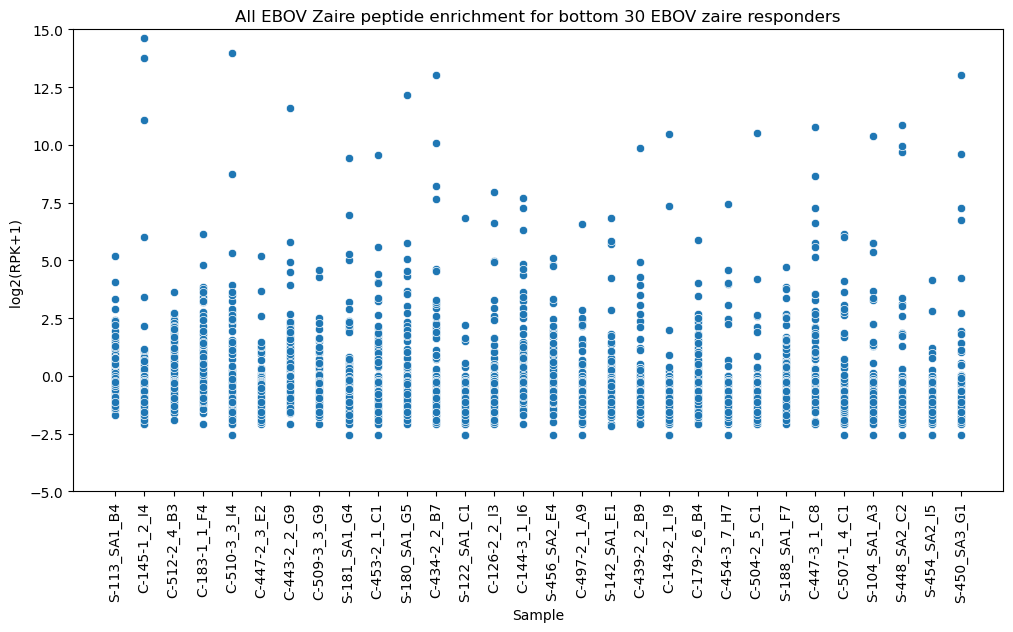

In [ ]:
import matplotlib.pyplot as plt


bottom_ebov_long = bottom_ebov.reset_index().melt(
    id_vars='peptide', 
    var_name='sample_ID', 
    value_name='raw_RPK'
)

plt.figure(figsize=(12,6))
sns.scatterplot(
    data=bottom_ebov_long, 
    x='sample_ID', 
    y='raw_RPK'
)

plt.xticks(rotation=90)
plt.xlabel("Sample")
plt.title("All EBOV Zaire peptide enrichment for bottom 30 EBOV zaire responders")
plt.ylabel("log2(RPK+1) ")
plt.ylim(-5, 15)
plt.show()

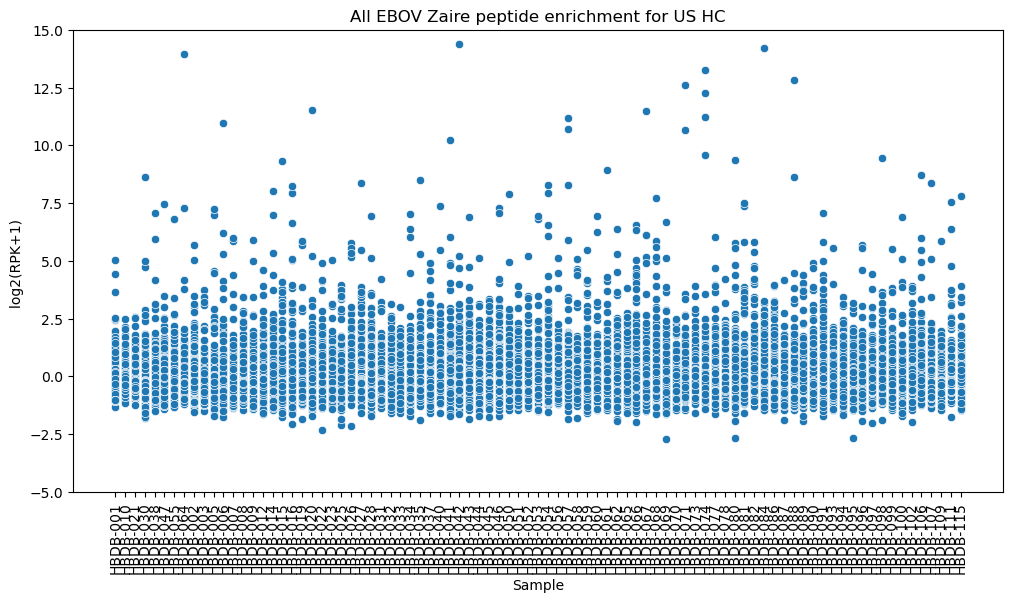

In [ ]:
import matplotlib.pyplot as plt


us_ebov_long = us_ebov.reset_index().melt(
    id_vars='peptide', 
    var_name='sample_ID', 
    value_name='raw_RPK'
)

plt.figure(figsize=(12,6))
sns.scatterplot(
    data=us_ebov_long, 
    x='sample_ID', 
    y='raw_RPK'
)

plt.xticks(rotation=90)
plt.xlabel("Sample")
plt.title("All EBOV Zaire peptide enrichment for US HC")
plt.ylabel("log2(RPK+1) ")
plt.ylim(-5, 15)
plt.show()

#### now for DENV

In [ ]:
#looking at denv responders
peps_metadata_denv = peps_metadata[peps_metadata['species'].isin(lasv_list)]
df_concat_rpk_denv = df_concat.loc[peps_metadata_denv.index]
top_denv = df_concat_rpk_denv[lasv_descending_top_50.index]
bottom_denv = df_concat_rpk_denv[lasv_descending_tail_30.index]
us_denv= df_concat_rpk_denv.filter(regex='HBDB-', axis=1)

In [ ]:
#log transform for plotting
top_denv= np.log2(top_denv +1)
bottom_denv= np.log2(bottom_denv +1)
us_denv = np.log2(us_denv +1)

/data1/sporak/anaconda3/envs/align3/lib/python3.10/site-packages/pandas/core/internals/blocks.py:395: RuntimeWarning: invalid value encountered in log2
  result = func(self.values, **kwargs)


In [ ]:
top_denv.max(axis=0).sort_values(ascending=False).head(5)

C-512-1_5_C9    7.101363
S-111_SA1_A1    6.538408
S-105_SA1_A4    6.397059
C-149-1_2_B1    5.965635
C-190-1_1_G4    5.942787
dtype: float64

In [ ]:
bottom_denv.max(axis=0).sort_values(ascending=False).head(5)

C-497-2_1_A9    7.866445
S-188_SA1_F7    5.580163
C-454-3_7_H7    5.529708
S-500_SA4_C3    5.512519
S-450_SA3_G1    5.508520
dtype: float64

In [ ]:
us_denv.max(axis=0).sort_values(ascending=False).head(10)

HBDB-028    8.281962
HBDB-065    7.169740
HBDB-097    6.042278
HBDB-010    5.622695
HBDB-046    5.527314
HBDB-032    5.463029
HBDB-050    5.370572
HBDB-045    5.320015
HBDB-070    5.266758
HBDB-043    5.250846
dtype: float64

## boxplots showing max seroreactivity for each individual to a given viral species. Peptides displayed are peptides kept after rigorous sensitivity and specificity filtering. 

['C-109-3_4_E7', 'C-111-3_3_I6', 'C-112-1_3_B3', 'C-130-2_3_C3', 'C-135-2_1_D2', 'C-140-1_1_A7', 'C-144-2_2_B5', 'C-147-2_1_F5', 'C-150-2_1_H3', 'C-183-1_1_F4', 'C-192-3_1_D3', 'C-434-3_5_E2', 'C-438-1_3_A4', 'C-441-3_2_G4', 'C-444-2_2_E4', 'C-464-3_3_F9', 'C-467-3_2_D5', 'C-470-3_2_F8', 'C-475-2_2_F5', 'C-483-1_1_D9', 'C-484-2_3_D4', 'C-485-3_2_H3', 'C-489-2_3_D5', 'C-499-3_1_B2', 'C-505-2_4_C2', 'C-508-2_4_A8', 'S-107_SA1_A9', 'S-113_SA1_B4', 'S-114_SA1_B5', 'S-115_SA1_A5', 'S-125_SA1_C3', 'S-126_SA1_C4', 'S-148_SA1_E7', 'S-186_SA1_G3', 'S-463_SA2_F8', 'S-488_SA1_H2', 'S-502_SA4_I1', 'S-509_SA3_H6', 'C-109-1_5_B3', 'C-114-3_3_B6', 'C-115-3_1_D6', 'C-122-2_3_B8', 'C-137-3_2_A9', 'C-139-2_6_D5', 'C-145-2_2_A6', 'C-145-3_1_E4', 'C-148-3_1_G3', 'C-178-1_1_E1', 'C-191-3_1_A3', 'C-448-1_1_I4', 'C-449-3_7_E4', 'C-462-2_2_D4', 'C-462-3_2_I6', 'C-465-3_5_G8', 'C-467-1_2_D6', 'C-467-2_7_H4', 'C-472-3_2_E9', 'C-475-1_3_G6', 'C-497-3_1_A5', 'C-499-1_2_C2', 'C-506-2_4_C6', 'C-507-3_4_B8', 'C-510-

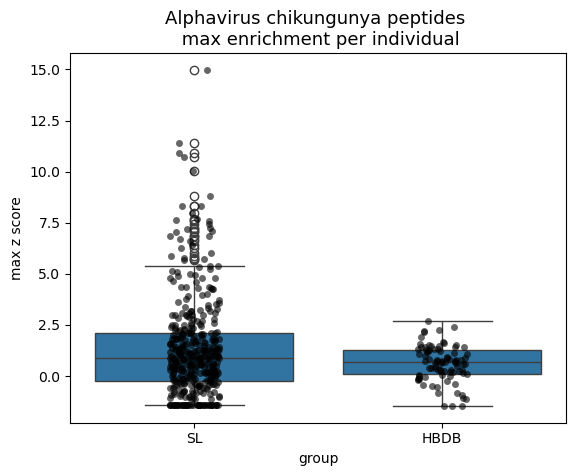

['C-109-3_4_E7', 'C-111-3_3_I6', 'C-112-1_3_B3', 'C-130-2_3_C3', 'C-135-2_1_D2', 'C-140-1_1_A7', 'C-144-2_2_B5', 'C-147-2_1_F5', 'C-150-2_1_H3', 'C-183-1_1_F4', 'C-192-3_1_D3', 'C-434-3_5_E2', 'C-438-1_3_A4', 'C-441-3_2_G4', 'C-444-2_2_E4', 'C-464-3_3_F9', 'C-467-3_2_D5', 'C-470-3_2_F8', 'C-475-2_2_F5', 'C-483-1_1_D9', 'C-484-2_3_D4', 'C-485-3_2_H3', 'C-489-2_3_D5', 'C-499-3_1_B2', 'C-505-2_4_C2', 'C-508-2_4_A8', 'S-107_SA1_A9', 'S-113_SA1_B4', 'S-114_SA1_B5', 'S-115_SA1_A5', 'S-125_SA1_C3', 'S-126_SA1_C4', 'S-148_SA1_E7', 'S-186_SA1_G3', 'S-463_SA2_F8', 'S-488_SA1_H2', 'S-502_SA4_I1', 'S-509_SA3_H6', 'C-109-1_5_B3', 'C-114-3_3_B6', 'C-115-3_1_D6', 'C-122-2_3_B8', 'C-137-3_2_A9', 'C-139-2_6_D5', 'C-145-2_2_A6', 'C-145-3_1_E4', 'C-148-3_1_G3', 'C-178-1_1_E1', 'C-191-3_1_A3', 'C-448-1_1_I4', 'C-449-3_7_E4', 'C-462-2_2_D4', 'C-462-3_2_I6', 'C-465-3_5_G8', 'C-467-1_2_D6', 'C-467-2_7_H4', 'C-472-3_2_E9', 'C-475-1_3_G6', 'C-497-3_1_A5', 'C-499-1_2_C2', 'C-506-2_4_C6', 'C-507-3_4_B8', 'C-510-

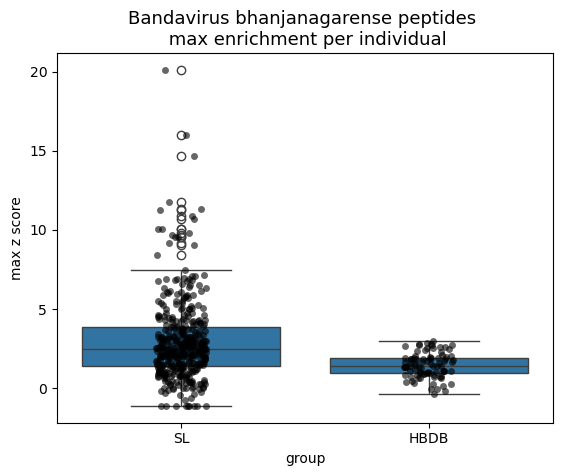

['C-109-3_4_E7', 'C-111-3_3_I6', 'C-112-1_3_B3', 'C-130-2_3_C3', 'C-135-2_1_D2', 'C-140-1_1_A7', 'C-144-2_2_B5', 'C-147-2_1_F5', 'C-150-2_1_H3', 'C-183-1_1_F4', 'C-192-3_1_D3', 'C-434-3_5_E2', 'C-438-1_3_A4', 'C-441-3_2_G4', 'C-444-2_2_E4', 'C-464-3_3_F9', 'C-467-3_2_D5', 'C-470-3_2_F8', 'C-475-2_2_F5', 'C-483-1_1_D9', 'C-484-2_3_D4', 'C-485-3_2_H3', 'C-489-2_3_D5', 'C-499-3_1_B2', 'C-505-2_4_C2', 'C-508-2_4_A8', 'S-107_SA1_A9', 'S-113_SA1_B4', 'S-114_SA1_B5', 'S-115_SA1_A5', 'S-125_SA1_C3', 'S-126_SA1_C4', 'S-148_SA1_E7', 'S-186_SA1_G3', 'S-463_SA2_F8', 'S-488_SA1_H2', 'S-502_SA4_I1', 'S-509_SA3_H6', 'C-109-1_5_B3', 'C-114-3_3_B6', 'C-115-3_1_D6', 'C-122-2_3_B8', 'C-137-3_2_A9', 'C-139-2_6_D5', 'C-145-2_2_A6', 'C-145-3_1_E4', 'C-148-3_1_G3', 'C-178-1_1_E1', 'C-191-3_1_A3', 'C-448-1_1_I4', 'C-449-3_7_E4', 'C-462-2_2_D4', 'C-462-3_2_I6', 'C-465-3_5_G8', 'C-467-1_2_D6', 'C-467-2_7_H4', 'C-472-3_2_E9', 'C-475-1_3_G6', 'C-497-3_1_A5', 'C-499-1_2_C2', 'C-506-2_4_C6', 'C-507-3_4_B8', 'C-510-

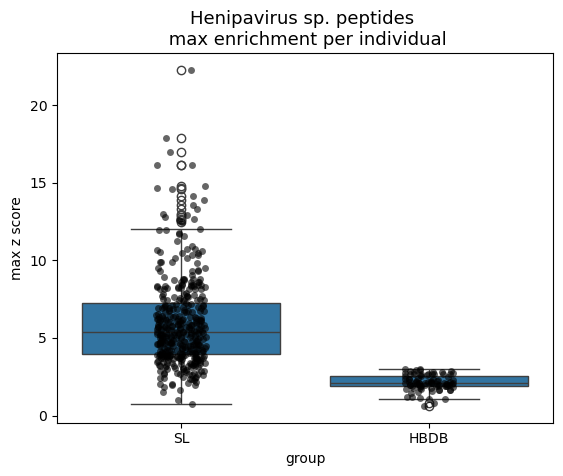

['C-109-3_4_E7', 'C-111-3_3_I6', 'C-112-1_3_B3', 'C-130-2_3_C3', 'C-135-2_1_D2', 'C-140-1_1_A7', 'C-144-2_2_B5', 'C-147-2_1_F5', 'C-150-2_1_H3', 'C-183-1_1_F4', 'C-192-3_1_D3', 'C-434-3_5_E2', 'C-438-1_3_A4', 'C-441-3_2_G4', 'C-444-2_2_E4', 'C-464-3_3_F9', 'C-467-3_2_D5', 'C-470-3_2_F8', 'C-475-2_2_F5', 'C-483-1_1_D9', 'C-484-2_3_D4', 'C-485-3_2_H3', 'C-489-2_3_D5', 'C-499-3_1_B2', 'C-505-2_4_C2', 'C-508-2_4_A8', 'S-107_SA1_A9', 'S-113_SA1_B4', 'S-114_SA1_B5', 'S-115_SA1_A5', 'S-125_SA1_C3', 'S-126_SA1_C4', 'S-148_SA1_E7', 'S-186_SA1_G3', 'S-463_SA2_F8', 'S-488_SA1_H2', 'S-502_SA4_I1', 'S-509_SA3_H6', 'C-109-1_5_B3', 'C-114-3_3_B6', 'C-115-3_1_D6', 'C-122-2_3_B8', 'C-137-3_2_A9', 'C-139-2_6_D5', 'C-145-2_2_A6', 'C-145-3_1_E4', 'C-148-3_1_G3', 'C-178-1_1_E1', 'C-191-3_1_A3', 'C-448-1_1_I4', 'C-449-3_7_E4', 'C-462-2_2_D4', 'C-462-3_2_I6', 'C-465-3_5_G8', 'C-467-1_2_D6', 'C-467-2_7_H4', 'C-472-3_2_E9', 'C-475-1_3_G6', 'C-497-3_1_A5', 'C-499-1_2_C2', 'C-506-2_4_C6', 'C-507-3_4_B8', 'C-510-

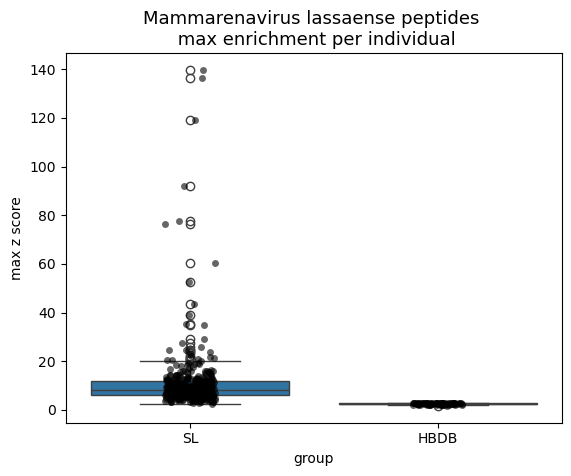

['C-109-3_4_E7', 'C-111-3_3_I6', 'C-112-1_3_B3', 'C-130-2_3_C3', 'C-135-2_1_D2', 'C-140-1_1_A7', 'C-144-2_2_B5', 'C-147-2_1_F5', 'C-150-2_1_H3', 'C-183-1_1_F4', 'C-192-3_1_D3', 'C-434-3_5_E2', 'C-438-1_3_A4', 'C-441-3_2_G4', 'C-444-2_2_E4', 'C-464-3_3_F9', 'C-467-3_2_D5', 'C-470-3_2_F8', 'C-475-2_2_F5', 'C-483-1_1_D9', 'C-484-2_3_D4', 'C-485-3_2_H3', 'C-489-2_3_D5', 'C-499-3_1_B2', 'C-505-2_4_C2', 'C-508-2_4_A8', 'S-107_SA1_A9', 'S-113_SA1_B4', 'S-114_SA1_B5', 'S-115_SA1_A5', 'S-125_SA1_C3', 'S-126_SA1_C4', 'S-148_SA1_E7', 'S-186_SA1_G3', 'S-463_SA2_F8', 'S-488_SA1_H2', 'S-502_SA4_I1', 'S-509_SA3_H6', 'C-109-1_5_B3', 'C-114-3_3_B6', 'C-115-3_1_D6', 'C-122-2_3_B8', 'C-137-3_2_A9', 'C-139-2_6_D5', 'C-145-2_2_A6', 'C-145-3_1_E4', 'C-148-3_1_G3', 'C-178-1_1_E1', 'C-191-3_1_A3', 'C-448-1_1_I4', 'C-449-3_7_E4', 'C-462-2_2_D4', 'C-462-3_2_I6', 'C-465-3_5_G8', 'C-467-1_2_D6', 'C-467-2_7_H4', 'C-472-3_2_E9', 'C-475-1_3_G6', 'C-497-3_1_A5', 'C-499-1_2_C2', 'C-506-2_4_C6', 'C-507-3_4_B8', 'C-510-

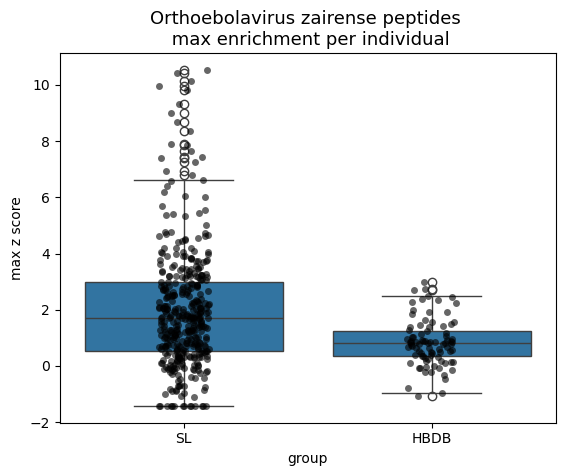

['C-109-3_4_E7', 'C-111-3_3_I6', 'C-112-1_3_B3', 'C-130-2_3_C3', 'C-135-2_1_D2', 'C-140-1_1_A7', 'C-144-2_2_B5', 'C-147-2_1_F5', 'C-150-2_1_H3', 'C-183-1_1_F4', 'C-192-3_1_D3', 'C-434-3_5_E2', 'C-438-1_3_A4', 'C-441-3_2_G4', 'C-444-2_2_E4', 'C-464-3_3_F9', 'C-467-3_2_D5', 'C-470-3_2_F8', 'C-475-2_2_F5', 'C-483-1_1_D9', 'C-484-2_3_D4', 'C-485-3_2_H3', 'C-489-2_3_D5', 'C-499-3_1_B2', 'C-505-2_4_C2', 'C-508-2_4_A8', 'S-107_SA1_A9', 'S-113_SA1_B4', 'S-114_SA1_B5', 'S-115_SA1_A5', 'S-125_SA1_C3', 'S-126_SA1_C4', 'S-148_SA1_E7', 'S-186_SA1_G3', 'S-463_SA2_F8', 'S-488_SA1_H2', 'S-502_SA4_I1', 'S-509_SA3_H6', 'C-109-1_5_B3', 'C-114-3_3_B6', 'C-115-3_1_D6', 'C-122-2_3_B8', 'C-137-3_2_A9', 'C-139-2_6_D5', 'C-145-2_2_A6', 'C-145-3_1_E4', 'C-148-3_1_G3', 'C-178-1_1_E1', 'C-191-3_1_A3', 'C-448-1_1_I4', 'C-449-3_7_E4', 'C-462-2_2_D4', 'C-462-3_2_I6', 'C-465-3_5_G8', 'C-467-1_2_D6', 'C-467-2_7_H4', 'C-472-3_2_E9', 'C-475-1_3_G6', 'C-497-3_1_A5', 'C-499-1_2_C2', 'C-506-2_4_C6', 'C-507-3_4_B8', 'C-510-

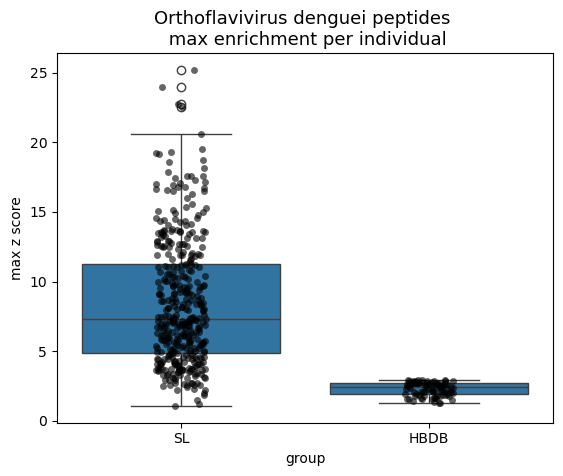

['C-109-3_4_E7', 'C-111-3_3_I6', 'C-112-1_3_B3', 'C-130-2_3_C3', 'C-135-2_1_D2', 'C-140-1_1_A7', 'C-144-2_2_B5', 'C-147-2_1_F5', 'C-150-2_1_H3', 'C-183-1_1_F4', 'C-192-3_1_D3', 'C-434-3_5_E2', 'C-438-1_3_A4', 'C-441-3_2_G4', 'C-444-2_2_E4', 'C-464-3_3_F9', 'C-467-3_2_D5', 'C-470-3_2_F8', 'C-475-2_2_F5', 'C-483-1_1_D9', 'C-484-2_3_D4', 'C-485-3_2_H3', 'C-489-2_3_D5', 'C-499-3_1_B2', 'C-505-2_4_C2', 'C-508-2_4_A8', 'S-107_SA1_A9', 'S-113_SA1_B4', 'S-114_SA1_B5', 'S-115_SA1_A5', 'S-125_SA1_C3', 'S-126_SA1_C4', 'S-148_SA1_E7', 'S-186_SA1_G3', 'S-463_SA2_F8', 'S-488_SA1_H2', 'S-502_SA4_I1', 'S-509_SA3_H6', 'C-109-1_5_B3', 'C-114-3_3_B6', 'C-115-3_1_D6', 'C-122-2_3_B8', 'C-137-3_2_A9', 'C-139-2_6_D5', 'C-145-2_2_A6', 'C-145-3_1_E4', 'C-148-3_1_G3', 'C-178-1_1_E1', 'C-191-3_1_A3', 'C-448-1_1_I4', 'C-449-3_7_E4', 'C-462-2_2_D4', 'C-462-3_2_I6', 'C-465-3_5_G8', 'C-467-1_2_D6', 'C-467-2_7_H4', 'C-472-3_2_E9', 'C-475-1_3_G6', 'C-497-3_1_A5', 'C-499-1_2_C2', 'C-506-2_4_C6', 'C-507-3_4_B8', 'C-510-

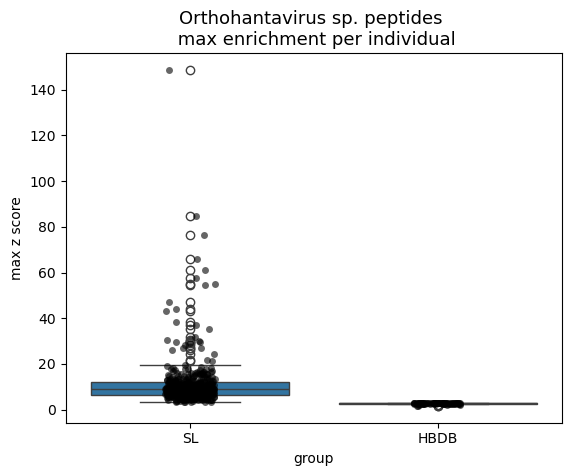

['C-109-3_4_E7', 'C-111-3_3_I6', 'C-112-1_3_B3', 'C-130-2_3_C3', 'C-135-2_1_D2', 'C-140-1_1_A7', 'C-144-2_2_B5', 'C-147-2_1_F5', 'C-150-2_1_H3', 'C-183-1_1_F4', 'C-192-3_1_D3', 'C-434-3_5_E2', 'C-438-1_3_A4', 'C-441-3_2_G4', 'C-444-2_2_E4', 'C-464-3_3_F9', 'C-467-3_2_D5', 'C-470-3_2_F8', 'C-475-2_2_F5', 'C-483-1_1_D9', 'C-484-2_3_D4', 'C-485-3_2_H3', 'C-489-2_3_D5', 'C-499-3_1_B2', 'C-505-2_4_C2', 'C-508-2_4_A8', 'S-107_SA1_A9', 'S-113_SA1_B4', 'S-114_SA1_B5', 'S-115_SA1_A5', 'S-125_SA1_C3', 'S-126_SA1_C4', 'S-148_SA1_E7', 'S-186_SA1_G3', 'S-463_SA2_F8', 'S-488_SA1_H2', 'S-502_SA4_I1', 'S-509_SA3_H6', 'C-109-1_5_B3', 'C-114-3_3_B6', 'C-115-3_1_D6', 'C-122-2_3_B8', 'C-137-3_2_A9', 'C-139-2_6_D5', 'C-145-2_2_A6', 'C-145-3_1_E4', 'C-148-3_1_G3', 'C-178-1_1_E1', 'C-191-3_1_A3', 'C-448-1_1_I4', 'C-449-3_7_E4', 'C-462-2_2_D4', 'C-462-3_2_I6', 'C-465-3_5_G8', 'C-467-1_2_D6', 'C-467-2_7_H4', 'C-472-3_2_E9', 'C-475-1_3_G6', 'C-497-3_1_A5', 'C-499-1_2_C2', 'C-506-2_4_C6', 'C-507-3_4_B8', 'C-510-

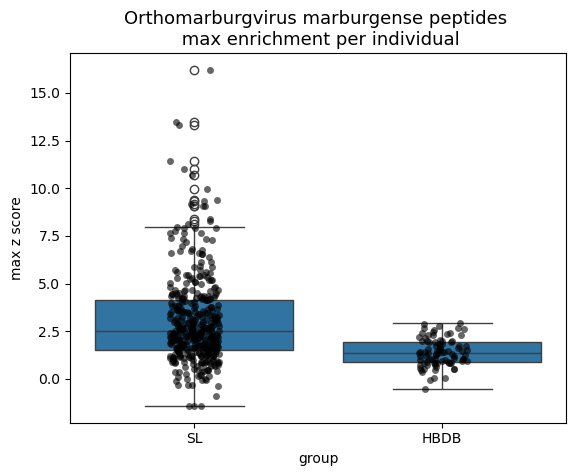

['C-109-3_4_E7', 'C-111-3_3_I6', 'C-112-1_3_B3', 'C-130-2_3_C3', 'C-135-2_1_D2', 'C-140-1_1_A7', 'C-144-2_2_B5', 'C-147-2_1_F5', 'C-150-2_1_H3', 'C-183-1_1_F4', 'C-192-3_1_D3', 'C-434-3_5_E2', 'C-438-1_3_A4', 'C-441-3_2_G4', 'C-444-2_2_E4', 'C-464-3_3_F9', 'C-467-3_2_D5', 'C-470-3_2_F8', 'C-475-2_2_F5', 'C-483-1_1_D9', 'C-484-2_3_D4', 'C-485-3_2_H3', 'C-489-2_3_D5', 'C-499-3_1_B2', 'C-505-2_4_C2', 'C-508-2_4_A8', 'S-107_SA1_A9', 'S-113_SA1_B4', 'S-114_SA1_B5', 'S-115_SA1_A5', 'S-125_SA1_C3', 'S-126_SA1_C4', 'S-148_SA1_E7', 'S-186_SA1_G3', 'S-463_SA2_F8', 'S-488_SA1_H2', 'S-502_SA4_I1', 'S-509_SA3_H6', 'C-109-1_5_B3', 'C-114-3_3_B6', 'C-115-3_1_D6', 'C-122-2_3_B8', 'C-137-3_2_A9', 'C-139-2_6_D5', 'C-145-2_2_A6', 'C-145-3_1_E4', 'C-148-3_1_G3', 'C-178-1_1_E1', 'C-191-3_1_A3', 'C-448-1_1_I4', 'C-449-3_7_E4', 'C-462-2_2_D4', 'C-462-3_2_I6', 'C-465-3_5_G8', 'C-467-1_2_D6', 'C-467-2_7_H4', 'C-472-3_2_E9', 'C-475-1_3_G6', 'C-497-3_1_A5', 'C-499-1_2_C2', 'C-506-2_4_C6', 'C-507-3_4_B8', 'C-510-

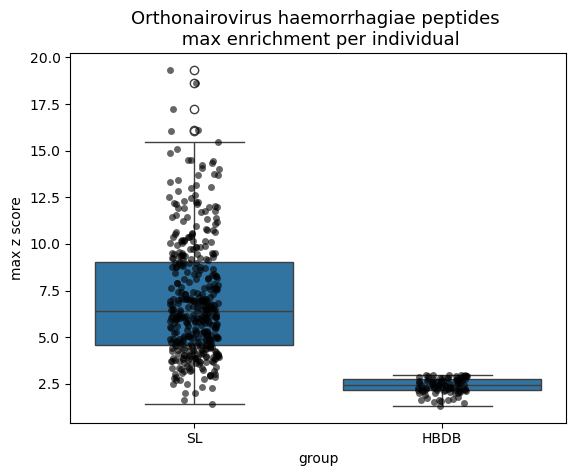

['C-109-3_4_E7', 'C-111-3_3_I6', 'C-112-1_3_B3', 'C-130-2_3_C3', 'C-135-2_1_D2', 'C-140-1_1_A7', 'C-144-2_2_B5', 'C-147-2_1_F5', 'C-150-2_1_H3', 'C-183-1_1_F4', 'C-192-3_1_D3', 'C-434-3_5_E2', 'C-438-1_3_A4', 'C-441-3_2_G4', 'C-444-2_2_E4', 'C-464-3_3_F9', 'C-467-3_2_D5', 'C-470-3_2_F8', 'C-475-2_2_F5', 'C-483-1_1_D9', 'C-484-2_3_D4', 'C-485-3_2_H3', 'C-489-2_3_D5', 'C-499-3_1_B2', 'C-505-2_4_C2', 'C-508-2_4_A8', 'S-107_SA1_A9', 'S-113_SA1_B4', 'S-114_SA1_B5', 'S-115_SA1_A5', 'S-125_SA1_C3', 'S-126_SA1_C4', 'S-148_SA1_E7', 'S-186_SA1_G3', 'S-463_SA2_F8', 'S-488_SA1_H2', 'S-502_SA4_I1', 'S-509_SA3_H6', 'C-109-1_5_B3', 'C-114-3_3_B6', 'C-115-3_1_D6', 'C-122-2_3_B8', 'C-137-3_2_A9', 'C-139-2_6_D5', 'C-145-2_2_A6', 'C-145-3_1_E4', 'C-148-3_1_G3', 'C-178-1_1_E1', 'C-191-3_1_A3', 'C-448-1_1_I4', 'C-449-3_7_E4', 'C-462-2_2_D4', 'C-462-3_2_I6', 'C-465-3_5_G8', 'C-467-1_2_D6', 'C-467-2_7_H4', 'C-472-3_2_E9', 'C-475-1_3_G6', 'C-497-3_1_A5', 'C-499-1_2_C2', 'C-506-2_4_C6', 'C-507-3_4_B8', 'C-510-

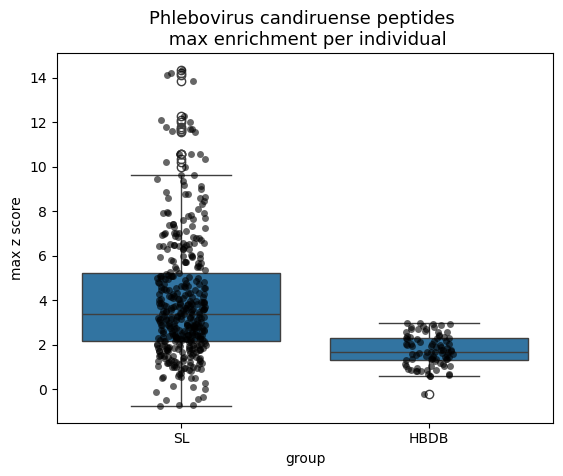

['C-109-3_4_E7', 'C-111-3_3_I6', 'C-112-1_3_B3', 'C-130-2_3_C3', 'C-135-2_1_D2', 'C-140-1_1_A7', 'C-144-2_2_B5', 'C-147-2_1_F5', 'C-150-2_1_H3', 'C-183-1_1_F4', 'C-192-3_1_D3', 'C-434-3_5_E2', 'C-438-1_3_A4', 'C-441-3_2_G4', 'C-444-2_2_E4', 'C-464-3_3_F9', 'C-467-3_2_D5', 'C-470-3_2_F8', 'C-475-2_2_F5', 'C-483-1_1_D9', 'C-484-2_3_D4', 'C-485-3_2_H3', 'C-489-2_3_D5', 'C-499-3_1_B2', 'C-505-2_4_C2', 'C-508-2_4_A8', 'S-107_SA1_A9', 'S-113_SA1_B4', 'S-114_SA1_B5', 'S-115_SA1_A5', 'S-125_SA1_C3', 'S-126_SA1_C4', 'S-148_SA1_E7', 'S-186_SA1_G3', 'S-463_SA2_F8', 'S-488_SA1_H2', 'S-502_SA4_I1', 'S-509_SA3_H6', 'C-109-1_5_B3', 'C-114-3_3_B6', 'C-115-3_1_D6', 'C-122-2_3_B8', 'C-137-3_2_A9', 'C-139-2_6_D5', 'C-145-2_2_A6', 'C-145-3_1_E4', 'C-148-3_1_G3', 'C-178-1_1_E1', 'C-191-3_1_A3', 'C-448-1_1_I4', 'C-449-3_7_E4', 'C-462-2_2_D4', 'C-462-3_2_I6', 'C-465-3_5_G8', 'C-467-1_2_D6', 'C-467-2_7_H4', 'C-472-3_2_E9', 'C-475-1_3_G6', 'C-497-3_1_A5', 'C-499-1_2_C2', 'C-506-2_4_C6', 'C-507-3_4_B8', 'C-510-

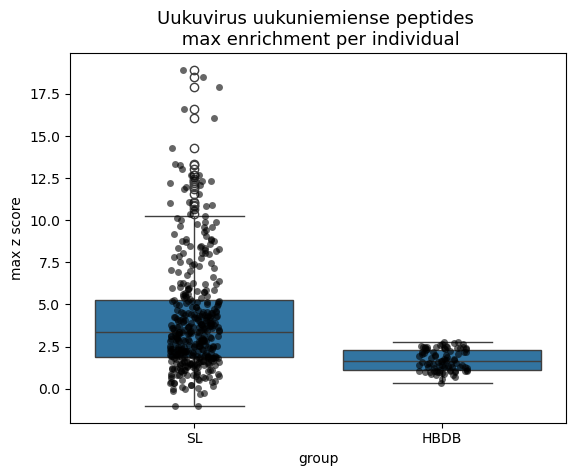

['C-109-3_4_E7', 'C-111-3_3_I6', 'C-112-1_3_B3', 'C-130-2_3_C3', 'C-135-2_1_D2', 'C-140-1_1_A7', 'C-144-2_2_B5', 'C-147-2_1_F5', 'C-150-2_1_H3', 'C-183-1_1_F4', 'C-192-3_1_D3', 'C-434-3_5_E2', 'C-438-1_3_A4', 'C-441-3_2_G4', 'C-444-2_2_E4', 'C-464-3_3_F9', 'C-467-3_2_D5', 'C-470-3_2_F8', 'C-475-2_2_F5', 'C-483-1_1_D9', 'C-484-2_3_D4', 'C-485-3_2_H3', 'C-489-2_3_D5', 'C-499-3_1_B2', 'C-505-2_4_C2', 'C-508-2_4_A8', 'S-107_SA1_A9', 'S-113_SA1_B4', 'S-114_SA1_B5', 'S-115_SA1_A5', 'S-125_SA1_C3', 'S-126_SA1_C4', 'S-148_SA1_E7', 'S-186_SA1_G3', 'S-463_SA2_F8', 'S-488_SA1_H2', 'S-502_SA4_I1', 'S-509_SA3_H6', 'C-109-1_5_B3', 'C-114-3_3_B6', 'C-115-3_1_D6', 'C-122-2_3_B8', 'C-137-3_2_A9', 'C-139-2_6_D5', 'C-145-2_2_A6', 'C-145-3_1_E4', 'C-148-3_1_G3', 'C-178-1_1_E1', 'C-191-3_1_A3', 'C-448-1_1_I4', 'C-449-3_7_E4', 'C-462-2_2_D4', 'C-462-3_2_I6', 'C-465-3_5_G8', 'C-467-1_2_D6', 'C-467-2_7_H4', 'C-472-3_2_E9', 'C-475-1_3_G6', 'C-497-3_1_A5', 'C-499-1_2_C2', 'C-506-2_4_C6', 'C-507-3_4_B8', 'C-510-

ValueError: List of boxplot statistics and `positions` values must have same the length

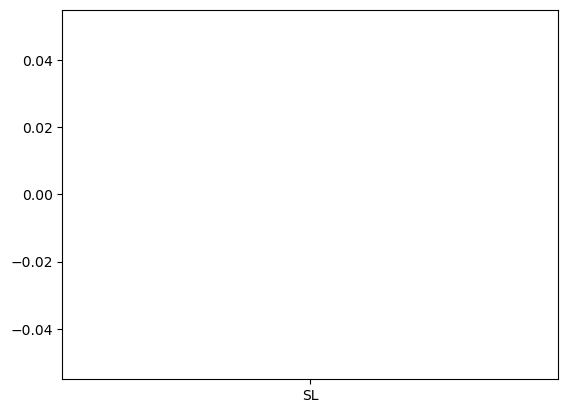

In [ ]:
for sp in species_list:
    species_boxplot(data=df_concat_hits, metadata=peps_metadata_hits, species=sp, agg='max', dtype='z')

['C-109-3_4_E7', 'C-111-3_3_I6', 'C-112-1_3_B3', 'C-130-2_3_C3', 'C-135-2_1_D2', 'C-140-1_1_A7', 'C-144-2_2_B5', 'C-147-2_1_F5', 'C-150-2_1_H3', 'C-183-1_1_F4', 'C-192-3_1_D3', 'C-434-3_5_E2', 'C-438-1_3_A4', 'C-441-3_2_G4', 'C-444-2_2_E4', 'C-464-3_3_F9', 'C-467-3_2_D5', 'C-470-3_2_F8', 'C-475-2_2_F5', 'C-483-1_1_D9', 'C-484-2_3_D4', 'C-485-3_2_H3', 'C-489-2_3_D5', 'C-499-3_1_B2', 'C-505-2_4_C2', 'C-508-2_4_A8', 'S-107_SA1_A9', 'S-113_SA1_B4', 'S-114_SA1_B5', 'S-115_SA1_A5', 'S-125_SA1_C3', 'S-126_SA1_C4', 'S-148_SA1_E7', 'S-186_SA1_G3', 'S-463_SA2_F8', 'S-488_SA1_H2', 'S-502_SA4_I1', 'S-509_SA3_H6', 'C-109-1_5_B3', 'C-114-3_3_B6', 'C-115-3_1_D6', 'C-122-2_3_B8', 'C-137-3_2_A9', 'C-139-2_6_D5', 'C-145-2_2_A6', 'C-145-3_1_E4', 'C-148-3_1_G3', 'C-178-1_1_E1', 'C-191-3_1_A3', 'C-448-1_1_I4', 'C-449-3_7_E4', 'C-462-2_2_D4', 'C-462-3_2_I6', 'C-465-3_5_G8', 'C-467-1_2_D6', 'C-467-2_7_H4', 'C-472-3_2_E9', 'C-475-1_3_G6', 'C-497-3_1_A5', 'C-499-1_2_C2', 'C-506-2_4_C6', 'C-507-3_4_B8', 'C-510-

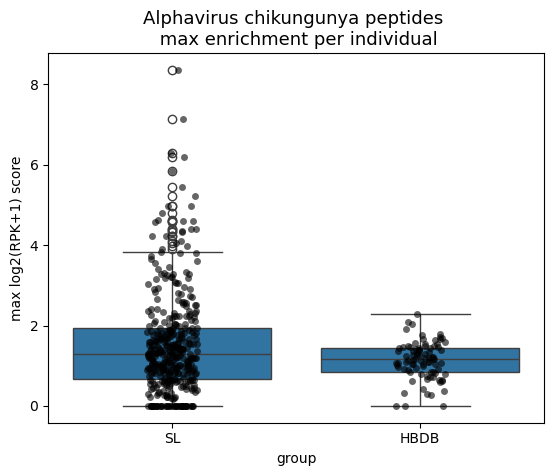

['C-109-3_4_E7', 'C-111-3_3_I6', 'C-112-1_3_B3', 'C-130-2_3_C3', 'C-135-2_1_D2', 'C-140-1_1_A7', 'C-144-2_2_B5', 'C-147-2_1_F5', 'C-150-2_1_H3', 'C-183-1_1_F4', 'C-192-3_1_D3', 'C-434-3_5_E2', 'C-438-1_3_A4', 'C-441-3_2_G4', 'C-444-2_2_E4', 'C-464-3_3_F9', 'C-467-3_2_D5', 'C-470-3_2_F8', 'C-475-2_2_F5', 'C-483-1_1_D9', 'C-484-2_3_D4', 'C-485-3_2_H3', 'C-489-2_3_D5', 'C-499-3_1_B2', 'C-505-2_4_C2', 'C-508-2_4_A8', 'S-107_SA1_A9', 'S-113_SA1_B4', 'S-114_SA1_B5', 'S-115_SA1_A5', 'S-125_SA1_C3', 'S-126_SA1_C4', 'S-148_SA1_E7', 'S-186_SA1_G3', 'S-463_SA2_F8', 'S-488_SA1_H2', 'S-502_SA4_I1', 'S-509_SA3_H6', 'C-109-1_5_B3', 'C-114-3_3_B6', 'C-115-3_1_D6', 'C-122-2_3_B8', 'C-137-3_2_A9', 'C-139-2_6_D5', 'C-145-2_2_A6', 'C-145-3_1_E4', 'C-148-3_1_G3', 'C-178-1_1_E1', 'C-191-3_1_A3', 'C-448-1_1_I4', 'C-449-3_7_E4', 'C-462-2_2_D4', 'C-462-3_2_I6', 'C-465-3_5_G8', 'C-467-1_2_D6', 'C-467-2_7_H4', 'C-472-3_2_E9', 'C-475-1_3_G6', 'C-497-3_1_A5', 'C-499-1_2_C2', 'C-506-2_4_C6', 'C-507-3_4_B8', 'C-510-

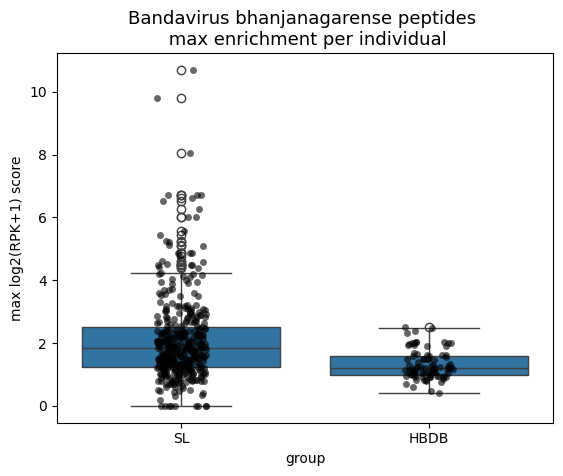

['C-109-3_4_E7', 'C-111-3_3_I6', 'C-112-1_3_B3', 'C-130-2_3_C3', 'C-135-2_1_D2', 'C-140-1_1_A7', 'C-144-2_2_B5', 'C-147-2_1_F5', 'C-150-2_1_H3', 'C-183-1_1_F4', 'C-192-3_1_D3', 'C-434-3_5_E2', 'C-438-1_3_A4', 'C-441-3_2_G4', 'C-444-2_2_E4', 'C-464-3_3_F9', 'C-467-3_2_D5', 'C-470-3_2_F8', 'C-475-2_2_F5', 'C-483-1_1_D9', 'C-484-2_3_D4', 'C-485-3_2_H3', 'C-489-2_3_D5', 'C-499-3_1_B2', 'C-505-2_4_C2', 'C-508-2_4_A8', 'S-107_SA1_A9', 'S-113_SA1_B4', 'S-114_SA1_B5', 'S-115_SA1_A5', 'S-125_SA1_C3', 'S-126_SA1_C4', 'S-148_SA1_E7', 'S-186_SA1_G3', 'S-463_SA2_F8', 'S-488_SA1_H2', 'S-502_SA4_I1', 'S-509_SA3_H6', 'C-109-1_5_B3', 'C-114-3_3_B6', 'C-115-3_1_D6', 'C-122-2_3_B8', 'C-137-3_2_A9', 'C-139-2_6_D5', 'C-145-2_2_A6', 'C-145-3_1_E4', 'C-148-3_1_G3', 'C-178-1_1_E1', 'C-191-3_1_A3', 'C-448-1_1_I4', 'C-449-3_7_E4', 'C-462-2_2_D4', 'C-462-3_2_I6', 'C-465-3_5_G8', 'C-467-1_2_D6', 'C-467-2_7_H4', 'C-472-3_2_E9', 'C-475-1_3_G6', 'C-497-3_1_A5', 'C-499-1_2_C2', 'C-506-2_4_C6', 'C-507-3_4_B8', 'C-510-

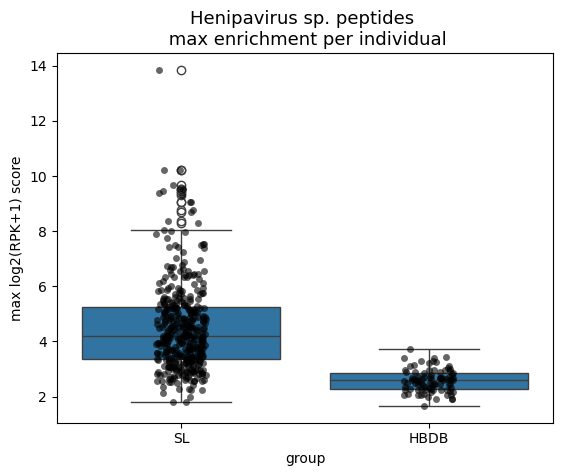

['C-109-3_4_E7', 'C-111-3_3_I6', 'C-112-1_3_B3', 'C-130-2_3_C3', 'C-135-2_1_D2', 'C-140-1_1_A7', 'C-144-2_2_B5', 'C-147-2_1_F5', 'C-150-2_1_H3', 'C-183-1_1_F4', 'C-192-3_1_D3', 'C-434-3_5_E2', 'C-438-1_3_A4', 'C-441-3_2_G4', 'C-444-2_2_E4', 'C-464-3_3_F9', 'C-467-3_2_D5', 'C-470-3_2_F8', 'C-475-2_2_F5', 'C-483-1_1_D9', 'C-484-2_3_D4', 'C-485-3_2_H3', 'C-489-2_3_D5', 'C-499-3_1_B2', 'C-505-2_4_C2', 'C-508-2_4_A8', 'S-107_SA1_A9', 'S-113_SA1_B4', 'S-114_SA1_B5', 'S-115_SA1_A5', 'S-125_SA1_C3', 'S-126_SA1_C4', 'S-148_SA1_E7', 'S-186_SA1_G3', 'S-463_SA2_F8', 'S-488_SA1_H2', 'S-502_SA4_I1', 'S-509_SA3_H6', 'C-109-1_5_B3', 'C-114-3_3_B6', 'C-115-3_1_D6', 'C-122-2_3_B8', 'C-137-3_2_A9', 'C-139-2_6_D5', 'C-145-2_2_A6', 'C-145-3_1_E4', 'C-148-3_1_G3', 'C-178-1_1_E1', 'C-191-3_1_A3', 'C-448-1_1_I4', 'C-449-3_7_E4', 'C-462-2_2_D4', 'C-462-3_2_I6', 'C-465-3_5_G8', 'C-467-1_2_D6', 'C-467-2_7_H4', 'C-472-3_2_E9', 'C-475-1_3_G6', 'C-497-3_1_A5', 'C-499-1_2_C2', 'C-506-2_4_C6', 'C-507-3_4_B8', 'C-510-

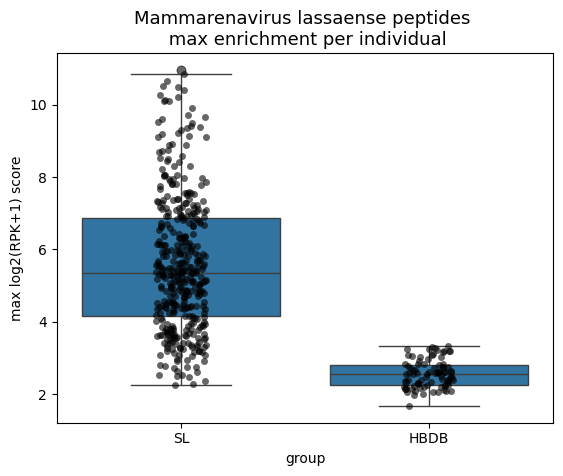

['C-109-3_4_E7', 'C-111-3_3_I6', 'C-112-1_3_B3', 'C-130-2_3_C3', 'C-135-2_1_D2', 'C-140-1_1_A7', 'C-144-2_2_B5', 'C-147-2_1_F5', 'C-150-2_1_H3', 'C-183-1_1_F4', 'C-192-3_1_D3', 'C-434-3_5_E2', 'C-438-1_3_A4', 'C-441-3_2_G4', 'C-444-2_2_E4', 'C-464-3_3_F9', 'C-467-3_2_D5', 'C-470-3_2_F8', 'C-475-2_2_F5', 'C-483-1_1_D9', 'C-484-2_3_D4', 'C-485-3_2_H3', 'C-489-2_3_D5', 'C-499-3_1_B2', 'C-505-2_4_C2', 'C-508-2_4_A8', 'S-107_SA1_A9', 'S-113_SA1_B4', 'S-114_SA1_B5', 'S-115_SA1_A5', 'S-125_SA1_C3', 'S-126_SA1_C4', 'S-148_SA1_E7', 'S-186_SA1_G3', 'S-463_SA2_F8', 'S-488_SA1_H2', 'S-502_SA4_I1', 'S-509_SA3_H6', 'C-109-1_5_B3', 'C-114-3_3_B6', 'C-115-3_1_D6', 'C-122-2_3_B8', 'C-137-3_2_A9', 'C-139-2_6_D5', 'C-145-2_2_A6', 'C-145-3_1_E4', 'C-148-3_1_G3', 'C-178-1_1_E1', 'C-191-3_1_A3', 'C-448-1_1_I4', 'C-449-3_7_E4', 'C-462-2_2_D4', 'C-462-3_2_I6', 'C-465-3_5_G8', 'C-467-1_2_D6', 'C-467-2_7_H4', 'C-472-3_2_E9', 'C-475-1_3_G6', 'C-497-3_1_A5', 'C-499-1_2_C2', 'C-506-2_4_C6', 'C-507-3_4_B8', 'C-510-

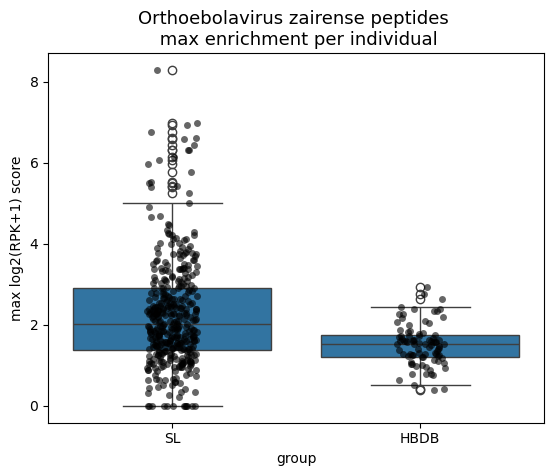

['C-109-3_4_E7', 'C-111-3_3_I6', 'C-112-1_3_B3', 'C-130-2_3_C3', 'C-135-2_1_D2', 'C-140-1_1_A7', 'C-144-2_2_B5', 'C-147-2_1_F5', 'C-150-2_1_H3', 'C-183-1_1_F4', 'C-192-3_1_D3', 'C-434-3_5_E2', 'C-438-1_3_A4', 'C-441-3_2_G4', 'C-444-2_2_E4', 'C-464-3_3_F9', 'C-467-3_2_D5', 'C-470-3_2_F8', 'C-475-2_2_F5', 'C-483-1_1_D9', 'C-484-2_3_D4', 'C-485-3_2_H3', 'C-489-2_3_D5', 'C-499-3_1_B2', 'C-505-2_4_C2', 'C-508-2_4_A8', 'S-107_SA1_A9', 'S-113_SA1_B4', 'S-114_SA1_B5', 'S-115_SA1_A5', 'S-125_SA1_C3', 'S-126_SA1_C4', 'S-148_SA1_E7', 'S-186_SA1_G3', 'S-463_SA2_F8', 'S-488_SA1_H2', 'S-502_SA4_I1', 'S-509_SA3_H6', 'C-109-1_5_B3', 'C-114-3_3_B6', 'C-115-3_1_D6', 'C-122-2_3_B8', 'C-137-3_2_A9', 'C-139-2_6_D5', 'C-145-2_2_A6', 'C-145-3_1_E4', 'C-148-3_1_G3', 'C-178-1_1_E1', 'C-191-3_1_A3', 'C-448-1_1_I4', 'C-449-3_7_E4', 'C-462-2_2_D4', 'C-462-3_2_I6', 'C-465-3_5_G8', 'C-467-1_2_D6', 'C-467-2_7_H4', 'C-472-3_2_E9', 'C-475-1_3_G6', 'C-497-3_1_A5', 'C-499-1_2_C2', 'C-506-2_4_C6', 'C-507-3_4_B8', 'C-510-

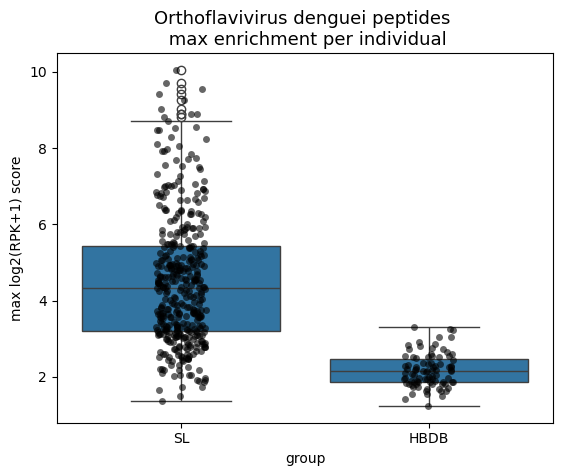

['C-109-3_4_E7', 'C-111-3_3_I6', 'C-112-1_3_B3', 'C-130-2_3_C3', 'C-135-2_1_D2', 'C-140-1_1_A7', 'C-144-2_2_B5', 'C-147-2_1_F5', 'C-150-2_1_H3', 'C-183-1_1_F4', 'C-192-3_1_D3', 'C-434-3_5_E2', 'C-438-1_3_A4', 'C-441-3_2_G4', 'C-444-2_2_E4', 'C-464-3_3_F9', 'C-467-3_2_D5', 'C-470-3_2_F8', 'C-475-2_2_F5', 'C-483-1_1_D9', 'C-484-2_3_D4', 'C-485-3_2_H3', 'C-489-2_3_D5', 'C-499-3_1_B2', 'C-505-2_4_C2', 'C-508-2_4_A8', 'S-107_SA1_A9', 'S-113_SA1_B4', 'S-114_SA1_B5', 'S-115_SA1_A5', 'S-125_SA1_C3', 'S-126_SA1_C4', 'S-148_SA1_E7', 'S-186_SA1_G3', 'S-463_SA2_F8', 'S-488_SA1_H2', 'S-502_SA4_I1', 'S-509_SA3_H6', 'C-109-1_5_B3', 'C-114-3_3_B6', 'C-115-3_1_D6', 'C-122-2_3_B8', 'C-137-3_2_A9', 'C-139-2_6_D5', 'C-145-2_2_A6', 'C-145-3_1_E4', 'C-148-3_1_G3', 'C-178-1_1_E1', 'C-191-3_1_A3', 'C-448-1_1_I4', 'C-449-3_7_E4', 'C-462-2_2_D4', 'C-462-3_2_I6', 'C-465-3_5_G8', 'C-467-1_2_D6', 'C-467-2_7_H4', 'C-472-3_2_E9', 'C-475-1_3_G6', 'C-497-3_1_A5', 'C-499-1_2_C2', 'C-506-2_4_C6', 'C-507-3_4_B8', 'C-510-

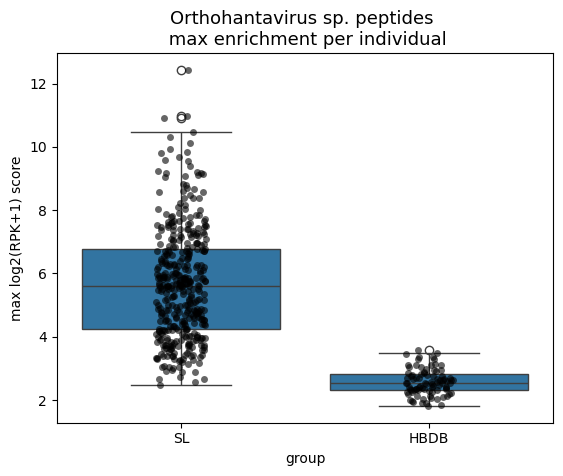

['C-109-3_4_E7', 'C-111-3_3_I6', 'C-112-1_3_B3', 'C-130-2_3_C3', 'C-135-2_1_D2', 'C-140-1_1_A7', 'C-144-2_2_B5', 'C-147-2_1_F5', 'C-150-2_1_H3', 'C-183-1_1_F4', 'C-192-3_1_D3', 'C-434-3_5_E2', 'C-438-1_3_A4', 'C-441-3_2_G4', 'C-444-2_2_E4', 'C-464-3_3_F9', 'C-467-3_2_D5', 'C-470-3_2_F8', 'C-475-2_2_F5', 'C-483-1_1_D9', 'C-484-2_3_D4', 'C-485-3_2_H3', 'C-489-2_3_D5', 'C-499-3_1_B2', 'C-505-2_4_C2', 'C-508-2_4_A8', 'S-107_SA1_A9', 'S-113_SA1_B4', 'S-114_SA1_B5', 'S-115_SA1_A5', 'S-125_SA1_C3', 'S-126_SA1_C4', 'S-148_SA1_E7', 'S-186_SA1_G3', 'S-463_SA2_F8', 'S-488_SA1_H2', 'S-502_SA4_I1', 'S-509_SA3_H6', 'C-109-1_5_B3', 'C-114-3_3_B6', 'C-115-3_1_D6', 'C-122-2_3_B8', 'C-137-3_2_A9', 'C-139-2_6_D5', 'C-145-2_2_A6', 'C-145-3_1_E4', 'C-148-3_1_G3', 'C-178-1_1_E1', 'C-191-3_1_A3', 'C-448-1_1_I4', 'C-449-3_7_E4', 'C-462-2_2_D4', 'C-462-3_2_I6', 'C-465-3_5_G8', 'C-467-1_2_D6', 'C-467-2_7_H4', 'C-472-3_2_E9', 'C-475-1_3_G6', 'C-497-3_1_A5', 'C-499-1_2_C2', 'C-506-2_4_C6', 'C-507-3_4_B8', 'C-510-

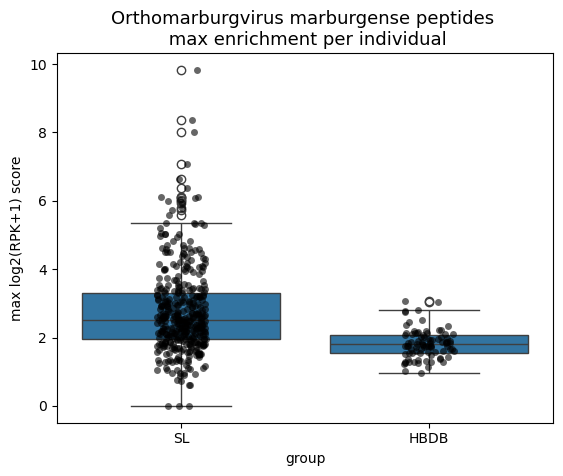

['C-109-3_4_E7', 'C-111-3_3_I6', 'C-112-1_3_B3', 'C-130-2_3_C3', 'C-135-2_1_D2', 'C-140-1_1_A7', 'C-144-2_2_B5', 'C-147-2_1_F5', 'C-150-2_1_H3', 'C-183-1_1_F4', 'C-192-3_1_D3', 'C-434-3_5_E2', 'C-438-1_3_A4', 'C-441-3_2_G4', 'C-444-2_2_E4', 'C-464-3_3_F9', 'C-467-3_2_D5', 'C-470-3_2_F8', 'C-475-2_2_F5', 'C-483-1_1_D9', 'C-484-2_3_D4', 'C-485-3_2_H3', 'C-489-2_3_D5', 'C-499-3_1_B2', 'C-505-2_4_C2', 'C-508-2_4_A8', 'S-107_SA1_A9', 'S-113_SA1_B4', 'S-114_SA1_B5', 'S-115_SA1_A5', 'S-125_SA1_C3', 'S-126_SA1_C4', 'S-148_SA1_E7', 'S-186_SA1_G3', 'S-463_SA2_F8', 'S-488_SA1_H2', 'S-502_SA4_I1', 'S-509_SA3_H6', 'C-109-1_5_B3', 'C-114-3_3_B6', 'C-115-3_1_D6', 'C-122-2_3_B8', 'C-137-3_2_A9', 'C-139-2_6_D5', 'C-145-2_2_A6', 'C-145-3_1_E4', 'C-148-3_1_G3', 'C-178-1_1_E1', 'C-191-3_1_A3', 'C-448-1_1_I4', 'C-449-3_7_E4', 'C-462-2_2_D4', 'C-462-3_2_I6', 'C-465-3_5_G8', 'C-467-1_2_D6', 'C-467-2_7_H4', 'C-472-3_2_E9', 'C-475-1_3_G6', 'C-497-3_1_A5', 'C-499-1_2_C2', 'C-506-2_4_C6', 'C-507-3_4_B8', 'C-510-

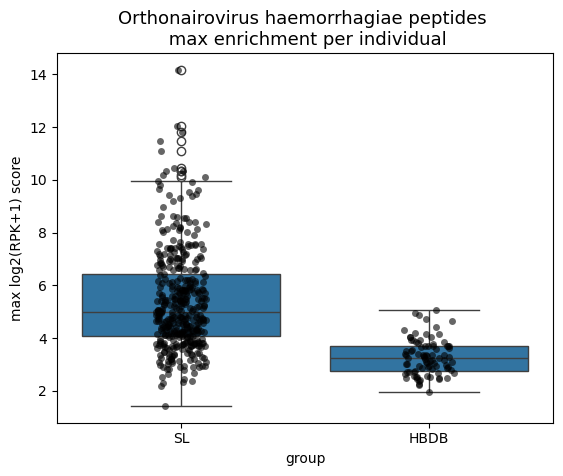

['C-109-3_4_E7', 'C-111-3_3_I6', 'C-112-1_3_B3', 'C-130-2_3_C3', 'C-135-2_1_D2', 'C-140-1_1_A7', 'C-144-2_2_B5', 'C-147-2_1_F5', 'C-150-2_1_H3', 'C-183-1_1_F4', 'C-192-3_1_D3', 'C-434-3_5_E2', 'C-438-1_3_A4', 'C-441-3_2_G4', 'C-444-2_2_E4', 'C-464-3_3_F9', 'C-467-3_2_D5', 'C-470-3_2_F8', 'C-475-2_2_F5', 'C-483-1_1_D9', 'C-484-2_3_D4', 'C-485-3_2_H3', 'C-489-2_3_D5', 'C-499-3_1_B2', 'C-505-2_4_C2', 'C-508-2_4_A8', 'S-107_SA1_A9', 'S-113_SA1_B4', 'S-114_SA1_B5', 'S-115_SA1_A5', 'S-125_SA1_C3', 'S-126_SA1_C4', 'S-148_SA1_E7', 'S-186_SA1_G3', 'S-463_SA2_F8', 'S-488_SA1_H2', 'S-502_SA4_I1', 'S-509_SA3_H6', 'C-109-1_5_B3', 'C-114-3_3_B6', 'C-115-3_1_D6', 'C-122-2_3_B8', 'C-137-3_2_A9', 'C-139-2_6_D5', 'C-145-2_2_A6', 'C-145-3_1_E4', 'C-148-3_1_G3', 'C-178-1_1_E1', 'C-191-3_1_A3', 'C-448-1_1_I4', 'C-449-3_7_E4', 'C-462-2_2_D4', 'C-462-3_2_I6', 'C-465-3_5_G8', 'C-467-1_2_D6', 'C-467-2_7_H4', 'C-472-3_2_E9', 'C-475-1_3_G6', 'C-497-3_1_A5', 'C-499-1_2_C2', 'C-506-2_4_C6', 'C-507-3_4_B8', 'C-510-

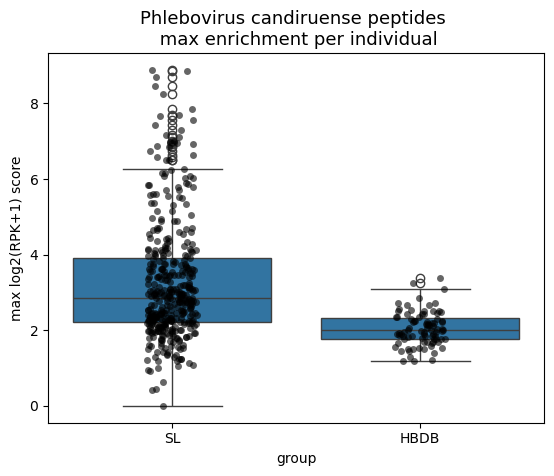

['C-109-3_4_E7', 'C-111-3_3_I6', 'C-112-1_3_B3', 'C-130-2_3_C3', 'C-135-2_1_D2', 'C-140-1_1_A7', 'C-144-2_2_B5', 'C-147-2_1_F5', 'C-150-2_1_H3', 'C-183-1_1_F4', 'C-192-3_1_D3', 'C-434-3_5_E2', 'C-438-1_3_A4', 'C-441-3_2_G4', 'C-444-2_2_E4', 'C-464-3_3_F9', 'C-467-3_2_D5', 'C-470-3_2_F8', 'C-475-2_2_F5', 'C-483-1_1_D9', 'C-484-2_3_D4', 'C-485-3_2_H3', 'C-489-2_3_D5', 'C-499-3_1_B2', 'C-505-2_4_C2', 'C-508-2_4_A8', 'S-107_SA1_A9', 'S-113_SA1_B4', 'S-114_SA1_B5', 'S-115_SA1_A5', 'S-125_SA1_C3', 'S-126_SA1_C4', 'S-148_SA1_E7', 'S-186_SA1_G3', 'S-463_SA2_F8', 'S-488_SA1_H2', 'S-502_SA4_I1', 'S-509_SA3_H6', 'C-109-1_5_B3', 'C-114-3_3_B6', 'C-115-3_1_D6', 'C-122-2_3_B8', 'C-137-3_2_A9', 'C-139-2_6_D5', 'C-145-2_2_A6', 'C-145-3_1_E4', 'C-148-3_1_G3', 'C-178-1_1_E1', 'C-191-3_1_A3', 'C-448-1_1_I4', 'C-449-3_7_E4', 'C-462-2_2_D4', 'C-462-3_2_I6', 'C-465-3_5_G8', 'C-467-1_2_D6', 'C-467-2_7_H4', 'C-472-3_2_E9', 'C-475-1_3_G6', 'C-497-3_1_A5', 'C-499-1_2_C2', 'C-506-2_4_C6', 'C-507-3_4_B8', 'C-510-

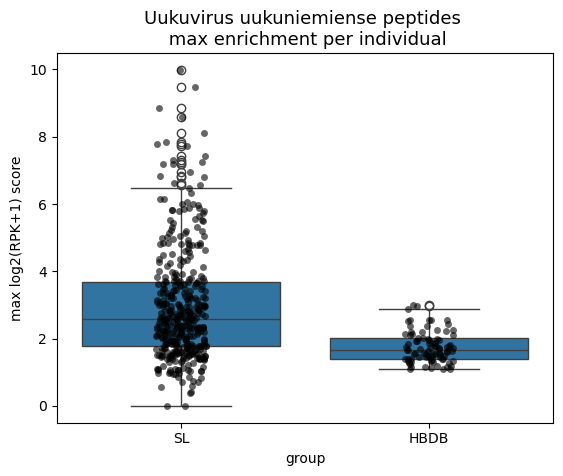

In [ ]:
for sp in species_list:
    species_boxplot(data=df_concat_rpk_hits_log, metadata=peps_metadata_hits, species=sp, agg='max', dtype='log2(RPK+1)')

### look to which proteins these seroreactive peptides belong to 

In [ ]:
species_list

['Alphavirus chikungunya',
 'Bandavirus bhanjanagarense',
 'Henipavirus sp.',
 'Mammarenavirus lassaense',
 'Orthoebolavirus zairense',
 'Orthoflavivirus denguei',
 'Orthohantavirus sp.',
 'Orthomarburgvirus marburgense',
 'Orthonairovirus haemorrhagiae',
 'Phlebovirus candiruense',
 'Uukuvirus uukuniemiense']

In [ ]:
long_z_scores_species_interest = long_z_scores.loc[long_z_scores['species'].isin(species_list)]

In [ ]:
long_z_scores_species_interest

,peptide,frac_pass_z_3_in_SL,frac_pass_z_3_in_US,species,genus,family,protein_name,accession,delta,sensitivity,specificity,youden,individual,z_score
1,XQN12076.1|polymerase|Mammarenavirus_lassaense...,0.083123,0.0,Mammarenavirus lassaense,Mammarenavirus,Arenaviridae,RNA dependent-RNA polymerase,XQN12076.1,0.083123,0.083123,1.0,0.083123,C-109-3_4_E7,False
41,WPS90786.1|polymerase|Mammarenavirus_lassaense...,0.178841,0.0,Mammarenavirus lassaense,Mammarenavirus,Arenaviridae,polymerase,WPS90786.1,0.178841,0.178841,1.0,0.178841,C-109-3_4_E7,False
42,WPS90786.1|polymerase|Mammarenavirus_lassaense...,0.052897,0.0,Mammarenavirus lassaense,Mammarenavirus,Arenaviridae,polymerase,WPS90786.1,0.052897,0.052897,1.0,0.052897,C-109-3_4_E7,True
49,UTE79751.1|polymerase|Mammarenavirus_lassaense...,0.125945,0.0,Mammarenavirus lassaense,Mammarenavirus,Arenaviridae,RNA-directed RNA polymerase,UTE79751.1,0.125945,0.125945,1.0,0.125945,C-109-3_4_E7,False
50,USR47367.1|polymerase|Mammarenavirus_lassaense...,0.123426,0.0,Mammarenavirus lassaense,Mammarenavirus,Arenaviridae,RNA-directed RNA polymerase,USR47367.1,0.123426,0.123426,1.0,0.123426,C-109-3_4_E7,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
87158962,AJP33321.1|polymerase|Cedar_virus|isolate=Geel...,0.078086,0.0,Henipavirus sp.,Henipavirus,Paramyxoviridae,RNA polymerase,AJP33321.1,0.078086,0.078086,1.0,0.078086,HBDB-115,-0.430114
87158963,YP_009091833.1|nucleoprotein|Ghana_virus|isola...,0.098237,0.0,Henipavirus sp.,Henipavirus,Paramyxoviridae,nucleoprotein,YP_009091833.1,0.098237,0.098237,1.0,0.098237,HBDB-115,-1.734502
87158964,YP_009091834.1|phosphoprotein|Ghana_virus|isol...,0.095718,0.0,Henipavirus sp.,Henipavirus,Paramyxoviridae,phosphoprotein,YP_009091834.1,0.095718,0.095718,1.0,0.095718,HBDB-115,-1.913462
87158965,YP_009091834.1|phosphoprotein|Ghana_virus|isol...,0.178841,0.0,Henipavirus sp.,Henipavirus,Paramyxoviridae,phosphoprotein,YP_009091834.1,0.178841,0.178841,1.0,0.178841,HBDB-115,0.89503


In [ ]:
long_z_scores_species_interest.groupby(['species', 'protein_name'])['frac_pass_z_3_in_SL'].mean()

species                        protein_name                       
Alphavirus chikungunya         nonstructural polyprotein              0.060453
                               structural polyprotein                 0.115869
Bandavirus bhanjanagarense     RNA-dependent RNA polymerase           0.070529
                               glycoprotein precursor                 0.079345
                               nonstructural protein                  0.057935
Henipavirus sp.                RNA polymerase                         0.069689
                               attachment glycoprotein                0.062972
                               fusion protein                         0.059194
                               nucleoprotein                          0.098237
                               phosphoprotein                         0.089495
                               phosphoprotein P                       0.062972
Mammarenavirus lassaense       L polymerase                     

In [ ]:
summary_proteins = long_z_scores_species_interest.groupby('species

SyntaxError: unterminated string literal (detected at line 1) (1854137879.py, line 1)

In [ ]:
summary_count_species

filtered = summary_count_species[
    summary_count_species['species'].isin(species_most_pep_counts.values())
]

In [ ]:
max_per_genus.sort_values(by='count', ascending=False)

,genus,species,count
142,Orthohantavirus,Orthohantavirus sp.,167464
63,Mammarenavirus,Mammarenavirus lassaense,128744
172,Orthonairovirus,Orthonairovirus haemorrhagiae,86152
32,Henipavirus,Henipavirus sp.,72600
118,Orthoflavivirus,Orthoflavivirus denguei,63888
335,Reptarenavirus,Reptarenavirus sp.,33880
353,Unclassified Nairoviridae,Nairoviridae sp.,32912
352,Trypanosoma,Trypanosoma cruzi,30008
104,Morbillivirus,Measles morbillivirus,18876
148,Orthomarburgvirus,Orthomarburgvirus marburgense,17908


In [ ]:
z_matrix = pd.concat([df_SL, df_hbdb], axis=1)

In [ ]:
z_matrix_hits = z_matrix.loc[hits['peptide']]

Text(0.5, 1.0, 'Scatterplot of fraction of peptides passing z-score > 3')

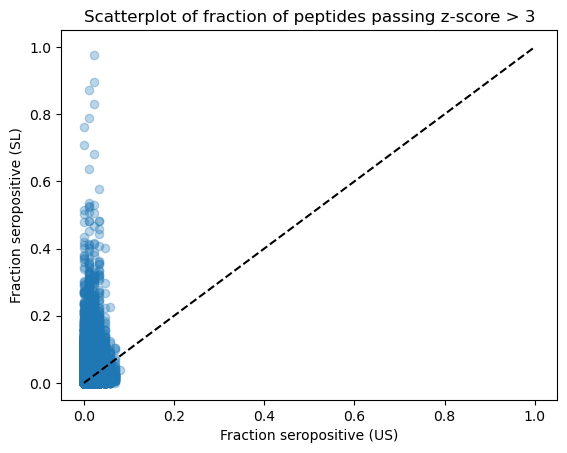

In [ ]:
#scatter plot

# x = fraction seropositive in US
# y = fraction seropositive in SL 

import matplotlib.pyplot as plt

plt.scatter(df_fractions['frac_pass_z_3_in_US'], df_fractions['frac_pass_z_3_in_SL'], alpha=0.3)

plt.plot([0,1], [0,1], 'k--')

plt.xlabel("Fraction seropositive (US)")
plt.ylabel('Fraction seropositive (SL)')
plt.title('Scatterplot of fraction of peptides passing z-score > 3')

In [ ]:
#now collapse on a species level and calculate the mean, max, median fraction of seropositive individuals for SL vs US
summary = (
    hits
    .groupby('species')
    .agg(
        max_frac_sl_seropos=('frac_pass_z_3_in_SL', 'max'),
        mean_frac_sl_seropos=('frac_pass_z_3_in_SL', 'mean'), 
        median_frac_sl_seropos=('frac_pass_z_3_in_SL', 'median'),


        max_frac_us_seropos=('frac_pass_z_3_in_US', 'max'),
        mean_frac_us_seropos=('frac_pass_z_3_in_US', 'mean'), 
        median_frac_us_seropos=('frac_pass_z_3_in_US', 'median')
       
    )
).reset_index()

summary_df = pd.DataFrame(summary)

In [ ]:
#repeat and collapse on a genus level

summary_genus = (
    hits
    .groupby('genus')
    .agg(
        max_frac_sl_seropos=('frac_pass_z_3_in_SL', 'max'),
        mean_frac_sl_seropos=('frac_pass_z_3_in_SL', 'mean'), 
        median_frac_sl_seropos=('frac_pass_z_3_in_SL', 'median'),


        max_frac_us_seropos=('frac_pass_z_3_in_US', 'max'),
        mean_frac_us_seropos=('frac_pass_z_3_in_US', 'mean'), 
        median_frac_us_seropos=('frac_pass_z_3_in_US', 'median')
       
    )
).reset_index()

summary_df_genus = pd.DataFrame(summary_genus)

In [ ]:
#repeat and collapse on a family level

summary_family = (
    hits
    .groupby('family')
    .agg(
        max_frac_sl_seropos=('frac_pass_z_3_in_SL', 'max'),
        mean_frac_sl_seropos=('frac_pass_z_3_in_SL', 'mean'), 
        median_frac_sl_seropos=('frac_pass_z_3_in_SL', 'median'),


        max_frac_us_seropos=('frac_pass_z_3_in_US', 'max'),
        mean_frac_us_seropos=('frac_pass_z_3_in_US', 'mean'), 
        median_frac_us_seropos=('frac_pass_z_3_in_US', 'median')
       
    )
).reset_index()

summary_df_family = pd.DataFrame(summary_family)

In [ ]:
summary_df = summary_df.sort_values(by=['max_frac_sl_seropos', 'max_frac_us_seropos'], ascending=[False, True])

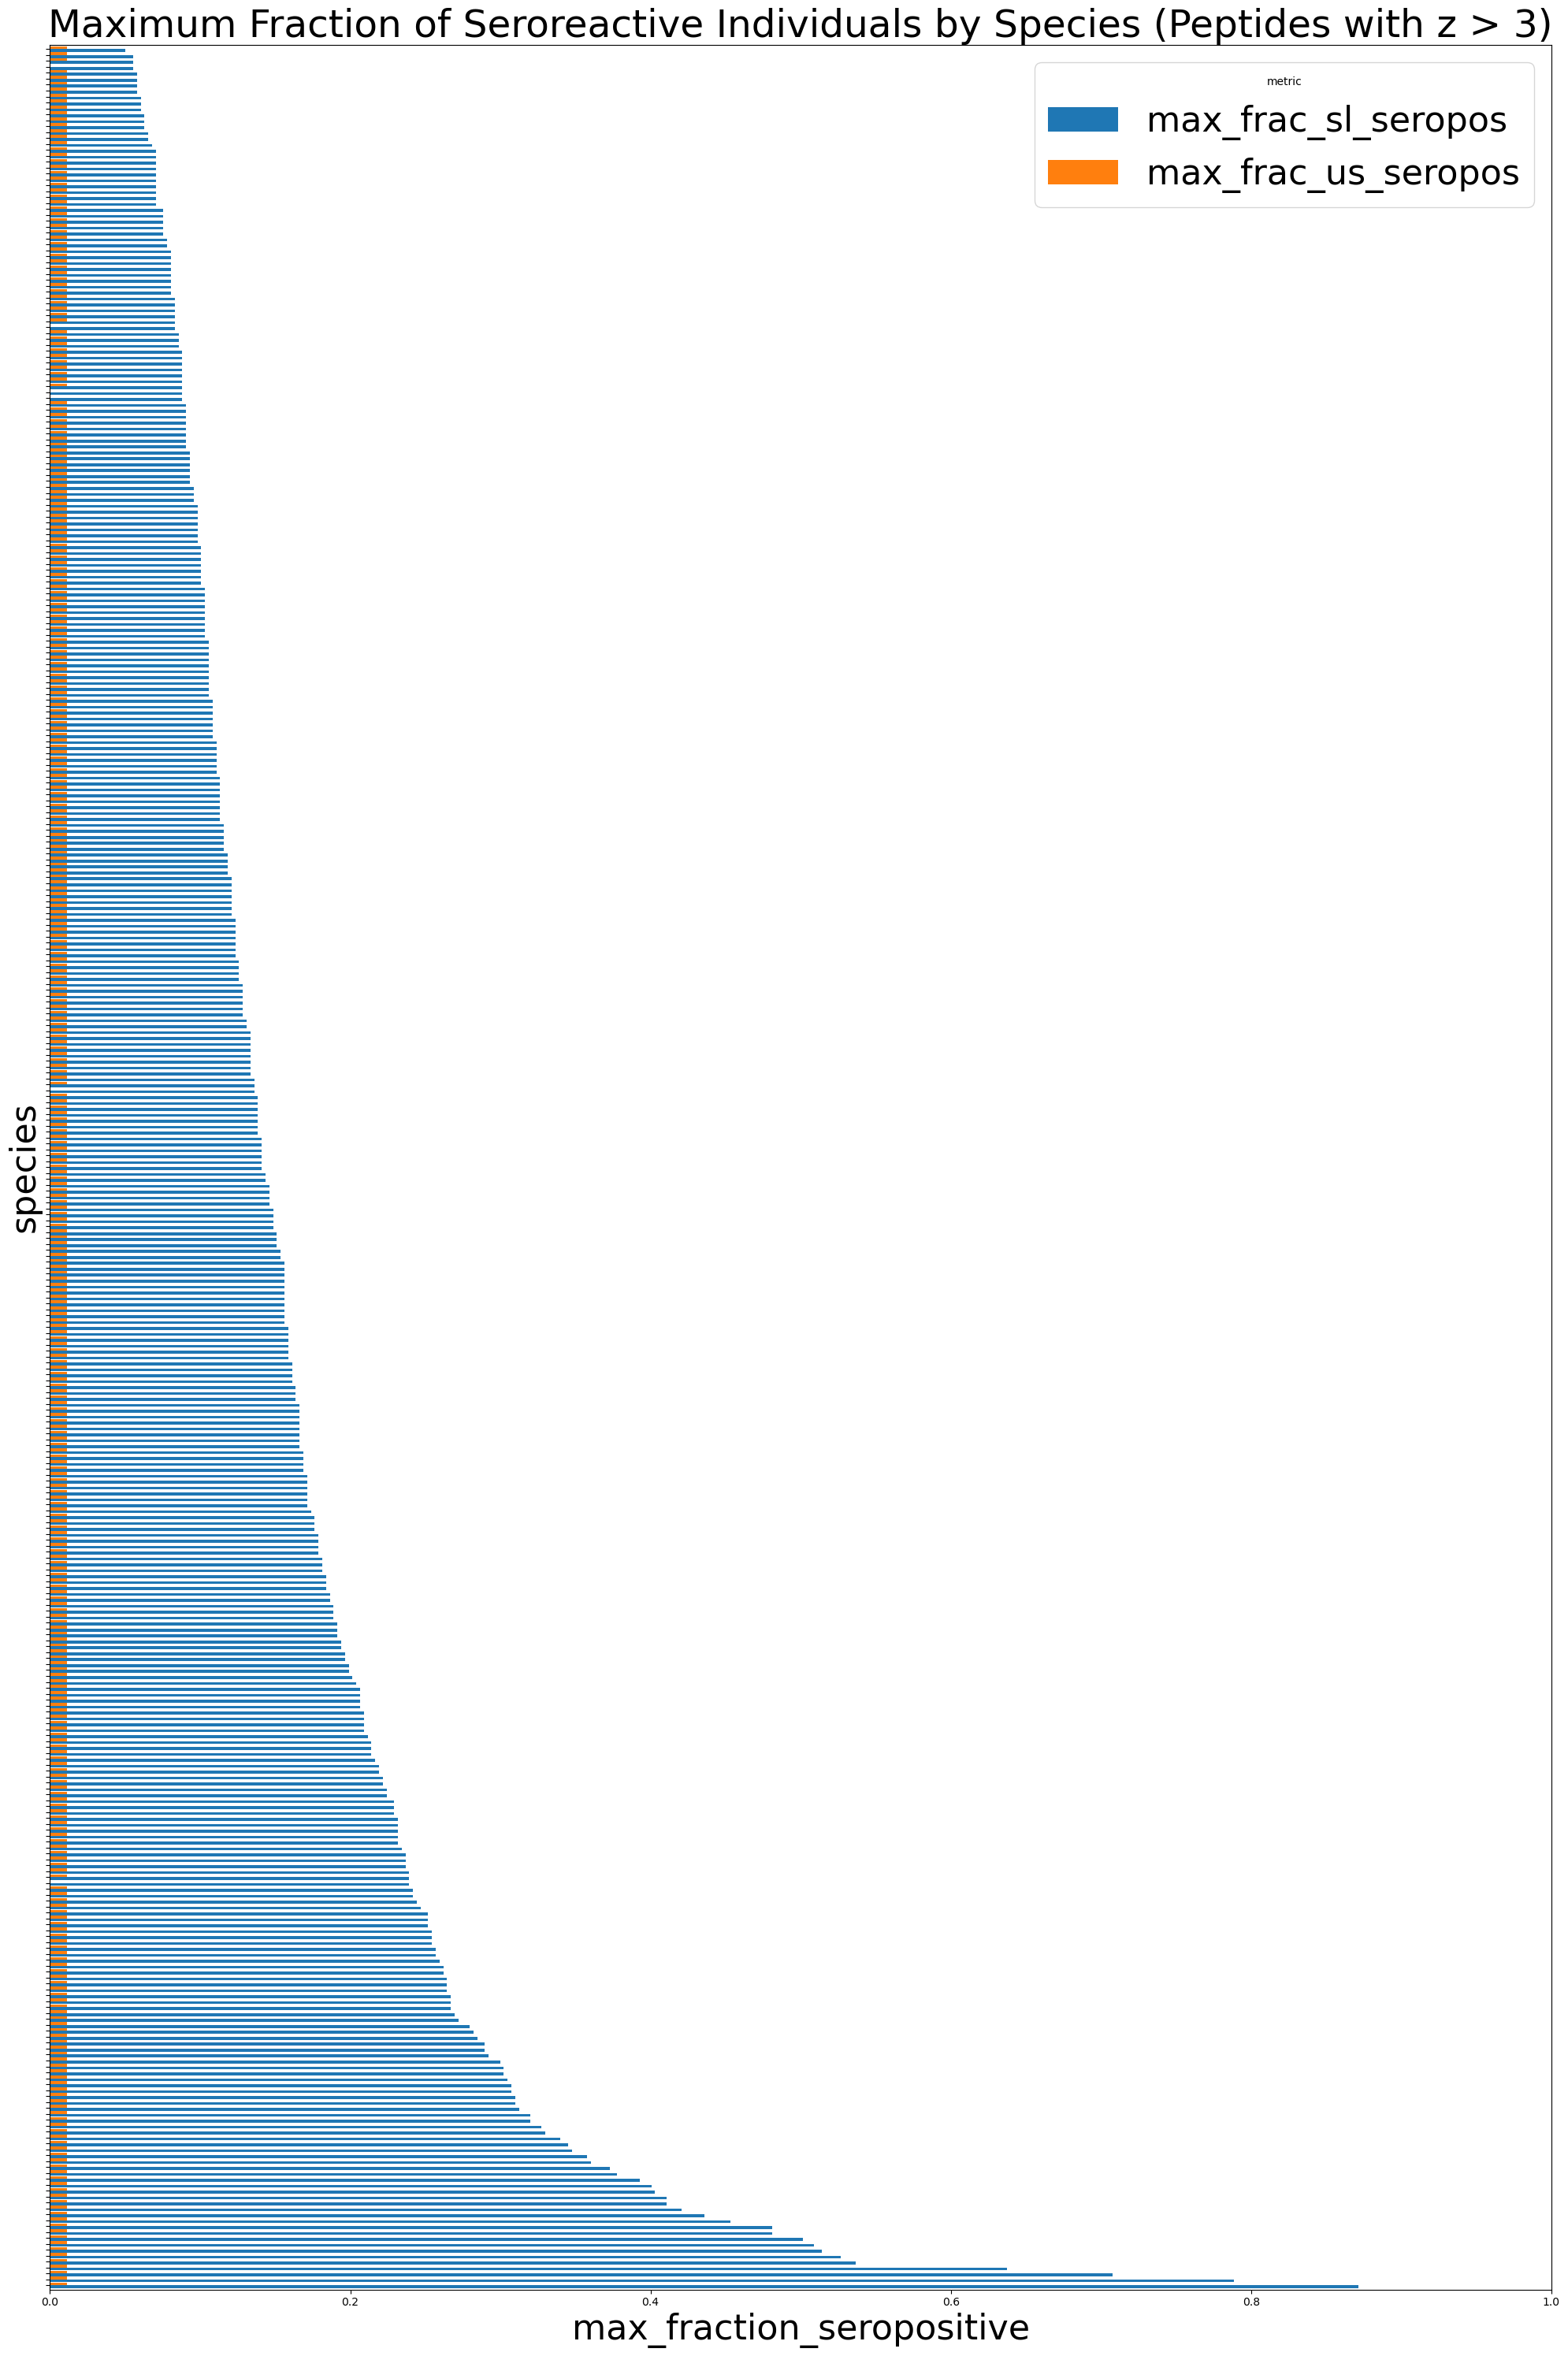

In [ ]:
#using horizontal grouped bar chart: one row per species

import pandas as pd
import matplotlib.pyplot as plt

df = summary_df.set_index('species')

ax = df[['max_frac_sl_seropos', 'max_frac_us_seropos']].plot(
    kind='barh', 
    figsize=(20, 30), 
    width=0.95
)

ax.tick_params(labelleft=False)
ax.set_xlim(0,1)
ax.set_xlabel('max_fraction_seropositive', fontsize=32)
ax.set_ylabel('species', fontsize=32)
ax.legend(title='metric', loc='upper right', fontsize=32)
plt.title('Maximum Fraction of Seroreactive Individuals by Species (Peptides with z > 3)', fontsize=35)
plt.tight_layout()
plt.show()

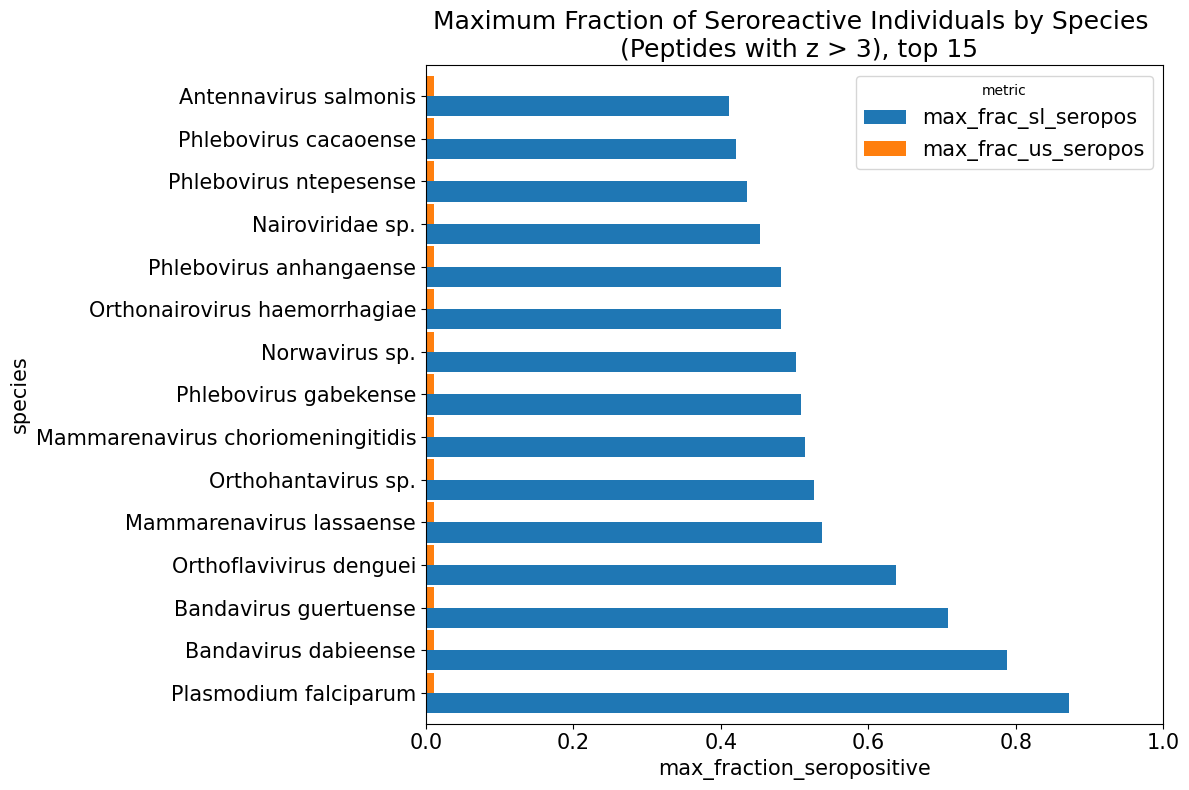

In [ ]:
#using horizontal grouped bar chart: one row per species

import pandas as pd
import matplotlib.pyplot as plt

df = summary_df.set_index('species').head(15)

ax = df[['max_frac_sl_seropos', 'max_frac_us_seropos']].plot(
    kind='barh', 
    figsize=(12, 8), 
    width=0.95
)

ax.tick_params(labelleft=True, labelsize=15)
ax.set_xlim(0,1)
ax.set_xlabel('max_fraction_seropositive', fontsize=15)
ax.set_ylabel('species', fontsize=15)
ax.legend(title='metric', loc='upper right', fontsize=15)
plt.title('Maximum Fraction of Seroreactive Individuals by Species \n (Peptides with z > 3), top 15', fontsize=18)
plt.tight_layout()
plt.show()

# Sensitivity analysis for each peptide -> choosing the right threshold

In [ ]:
import numpy as np
import pandas as pd

#parameters to tune
thresholds = np.arange(3.0, 50.0, 1.0)   # candidate z-score thresholds for each peptide
max_healthy_positive_rate = 0.01        # 0.00 = no healthy positives allowed; try 0.01 if too strict -> 1% is allowed

# build peptide to species map
species_map = (
    peps_metadata[['peptide', 'species']]
    .drop_duplicates()
    .set_index('peptide')['species']
)

# Keep only peptides present in all three objects
common_peps = df_SL.index.intersection(df_hbdb.index).intersection(species_map.index)

df_SL2 = df_SL.loc[common_peps].copy()
df_hbdb2 = df_hbdb.loc[common_peps].copy()
species_map2 = species_map.loc[common_peps]

#choose a right threshold for each peptide using HC 
peptide_thresholds = {}
peptide_summary = []

for pep in common_peps:
    diseased_row = df_SL2.loc[pep]
    healthy_row = df_hbdb2.loc[pep]

    chosen_t = None
    chosen_hpr = None
    chosen_dpr = None

    # choose the lowest threshold that keeps healthy positive rate <= target
    for t in thresholds:
        healthy_pos_rate = (healthy_row > t).mean()
        diseased_pos_rate = (diseased_row > t).mean()

        if healthy_pos_rate <= max_healthy_positive_rate:
            chosen_t = t
            chosen_hpr = healthy_pos_rate
            chosen_dpr = diseased_pos_rate
            break

    # if nothing meets the healthy constraint, fall back to the highest threshold
    if chosen_t is None:
        chosen_t = thresholds[-1]
        chosen_hpr = (healthy_row > chosen_t).mean()
        chosen_dpr = (diseased_row > chosen_t).mean()

    peptide_thresholds[pep] = chosen_t
    peptide_summary.append({
        'peptide': pep,
        'species': species_map2.loc[pep],
        'threshold': chosen_t,
        'healthy_positive_rate': chosen_hpr,
        'exposed_positive_rate': chosen_dpr,
        'delta': chosen_dpr - chosen_hpr
    })

peptide_thresholds_df = pd.DataFrame(peptide_summary)

#convert each peptide into positive/negative calls using its own threshold
thr_vec = pd.Series(peptide_thresholds).reindex(df_SL2.index).to_numpy()[:, None]
sl_pos = (df_SL2.to_numpy() > thr_vec)      # shape: peptides x diseased samples
hb_pos = (df_hbdb2.to_numpy() > thr_vec)     # shape: peptides x healthy samples


# build sample-level species reactivity table 

species_sample_rows = []

species_to_peptides = species_map2.groupby(species_map2).groups

diseased_samples = df_SL2.columns
healthy_samples = df_hbdb2.columns

for species, peps in species_to_peptides.items():
    peps = list(peps)
    idx = df_SL2.index.get_indexer(peps)
    idx = idx[idx >= 0]

    if len(idx) == 0:
        continue

    n_peptides = len(idx)

    # counts per sample
    sl_counts = sl_pos[idx, :].sum(axis=0)
    hb_counts = hb_pos[idx, :].sum(axis=0)

    # diseased rows
    for sample, n_reactive in zip(diseased_samples, sl_counts):
        species_sample_rows.append({
            'sample': sample,
            'group': 'diseased',
            'species': species,
            'n_peptides': n_peptides,
            'n_reactive_peptides': int(n_reactive),
            'fraction_reactive_peptides': n_reactive / n_peptides
        })

    # healthy rows
    for sample, n_reactive in zip(healthy_samples, hb_counts):
        species_sample_rows.append({
            'sample': sample,
            'group': 'healthy',
            'species': species,
            'n_peptides': n_peptides,
            'n_reactive_peptides': int(n_reactive),
            'fraction_reactive_peptides': n_reactive / n_peptides
        })

species_sample_df = pd.DataFrame(species_sample_rows)

# Summarize species-level enrichment
species_summary = (
    species_sample_df
    .groupby('species', as_index=False)
    .agg(
        n_peptides=('n_peptides', 'first'),
        mean_reactive_diseased=('n_reactive_peptides', lambda x: x[species_sample_df.loc[x.index, 'group'].eq('diseased')].mean()),
        mean_reactive_healthy=('n_reactive_peptides', lambda x: x[species_sample_df.loc[x.index, 'group'].eq('healthy')].mean()),
        median_reactive_diseased=('n_reactive_peptides', lambda x: x[species_sample_df.loc[x.index, 'group'].eq('diseased')].median()),
        median_reactive_healthy=('n_reactive_peptides', lambda x: x[species_sample_df.loc[x.index, 'group'].eq('healthy')].median()),
        mean_fraction_diseased=('fraction_reactive_peptides', lambda x: x[species_sample_df.loc[x.index, 'group'].eq('diseased')].mean()),
        mean_fraction_healthy=('fraction_reactive_peptides', lambda x: x[species_sample_df.loc[x.index, 'group'].eq('healthy')].mean()),
    )
)

species_summary['diff_mean_fraction'] = (
    species_summary['mean_fraction_diseased'] - species_summary['mean_fraction_healthy']
)

species_summary['fold_enrichment'] = (
    species_summary['mean_fraction_diseased'] / (species_summary['mean_fraction_healthy'] + 1e-9)
)

species_summary = species_summary.sort_values(
    ['diff_mean_fraction', 'mean_fraction_diseased'],
    ascending=[False, False]
)

display(species_summary.head(50))


KeyError: "['peptide'] not in index"

In [ ]:
best_species.head(60)

,species,n_peptides,n_positive_cutoff,diseased_positive_rate,healthy_positive_rate,specificity,avg_positive_peptides_diseased,avg_positive_peptides_healthy,gap
66,Henipavirus sp.,2091,2,1.000000,0.0,1.0,21.365239,0.022989,1.000000
100,Mammarenavirus choriomeningitidis,2267,2,1.000000,0.0,1.0,18.863980,0.034483,1.000000
109,Mammarenavirus lassaense,4479,3,1.000000,0.0,1.0,49.332494,0.045977,1.000000
130,Mammarenavirus sp.,949,1,1.000000,0.0,1.0,8.735516,0.000000,1.000000
167,Orthoflavivirus denguei,2050,2,1.000000,0.0,1.0,23.032746,0.011494,1.000000
180,Orthohantavirus sp.,6731,2,1.000000,0.0,1.0,63.881612,0.137931,1.000000
197,Orthonairovirus haemorrhagiae,2524,2,1.000000,0.0,1.0,28.949622,0.057471,1.000000
151,Nairoviridae sp.,1137,2,0.997481,0.0,1.0,12.045340,0.011494,0.997481
324,Reptarenavirus sp.,1537,2,0.997481,0.0,1.0,12.697733,0.022989,0.997481
193,Orthonairovirus erveense,1134,2,0.994962,0.0,1.0,11.539043,0.011494,0.994962


In [ ]:
#add peptide metadata 
peps_metadata = peps_metadata.reset_index()
peps_metadata = peps_metadata.rename(columns={'seq_id': 'peptide'})

In [ ]:
import numpy as np 
import pandas as pd

#build peptide to species mapping
species_map = (
    peps_metadata[['peptide', 'species']]
    .drop_duplicates()
    .set_index('peptide')['species']
)

#make sure peptide names match the z-score matrix index
common_peps = df_SL.index.intersection(species_map.index)
df_SL2 = df_SL.loc[common_peps].copy()
df_hbdb2 = df_hbdb.loc[df_hbdb.index.intersection(species_map.index)].copy()
species_map2 = species_map.loc[common_peps]

#Threshold grid to test 
thresholds = np.arange(3.0, 50.0, 1.0) #start, stop, step

results = []

#loop over species
for species, peptides in species_map2.groupby(species_map2):
    peptides = peptides.index.tolist()

    sl_sub = df_SL2.loc[peptides]
    hb_sub = df_hbdb2.loc[peptides]

    for t in thresholds:
        #sample-level seropositivity: 
        #a sample is seropositive if ANY peptide in that species has z > threshold
        diseased_pos = (sl_sub > t).any(axis=0)
        healthy_pos = (hb_sub > t).any(axis=0)

        sensitivity = diseased_pos.mean() #TP / all diseased
        specificity = 1 - healthy_pos.mean()
        youden_j = sensitivity + specificity - 1
        balanced_accuracy = (sensitivity + specificity) / 2 

        results.append({
            'species': species,
            'threshold': t, 
            'n_peptides': len(peptides), 
            'sensitivity': sensitivity, 
            'specificity': specificity, 
            'youden_j': youden_j, 
            'balanced_accuracy': balanced_accuracy, 
            'SL_positive_rate':diseased_pos.mean(), 
            'healthy_positive_rate': healthy_pos.mean()
        })

results_df = pd.DataFrame(results)

In [ ]:
best_thresholds = (
    results_df
    .sort_values(
        ["species",
         "healthy_positive_rate",      # smallest first
         "SL_positive_rate",     # largest first
         "threshold"],                 # lowest threshold first
        ascending=[True, True, False, True]
    )
    .groupby("species", as_index=False)
    .first()
)

best_thresholds.head(20)

,species,threshold,n_peptides,sensitivity,specificity,youden_j,balanced_accuracy,SL_positive_rate,healthy_positive_rate
0,Actinovirus sp.,24.0,210,0.005038,1.000000,0.005038,0.502519,0.005038,0.000000
1,Aershan mammarenavirus,15.0,96,0.035264,0.988506,0.023770,0.511885,0.035264,0.011494
2,Agnathovirus sp.,25.0,171,0.007557,1.000000,0.007557,0.503778,0.007557,0.000000
3,Alethinophid 2 reptarenavirus,36.0,64,0.000000,1.000000,0.000000,0.500000,0.000000,0.000000
4,Alphavirus chikungunya,27.0,341,0.027708,0.988506,0.016214,0.508107,0.027708,0.011494
5,Altai virus,39.0,93,0.002519,0.988506,-0.008975,0.495512,0.002519,0.011494
6,Alxa tick phlebovirus,31.0,214,0.015113,1.000000,0.015113,0.507557,0.015113,0.000000
7,Antennavirus hirsutum,19.0,147,0.012594,1.000000,0.012594,0.506297,0.012594,0.000000
8,Antennavirus salmonis,38.0,196,0.007557,0.988506,-0.003938,0.498031,0.007557,0.011494
9,Antennavirus striale,35.0,158,0.000000,1.000000,0.000000,0.500000,0.000000,0.000000


In [ ]:
best_thresholds.sort_values('SL_positive_rate', ascending=False).head(60)

,species,threshold,n_peptides,sensitivity,specificity,youden_j,balanced_accuracy,SL_positive_rate,healthy_positive_rate
310,Plasmodium falciparum,12.0,3,0.909320,1.000000,0.909320,0.954660,0.909320,0.000000
180,Orthohantavirus sp.,43.0,6731,0.201511,0.862069,0.063580,0.531790,0.201511,0.137931
308,Pidchovirus stethori,26.0,157,0.186398,1.000000,0.186398,0.593199,0.186398,0.000000
19,Bandavirus dabieense,22.0,217,0.178841,1.000000,0.178841,0.589421,0.178841,0.000000
385,Yunnan rodent phlebovirus 1,22.0,226,0.123426,1.000000,0.123426,0.561713,0.123426,0.000000
167,Orthoflavivirus denguei,43.0,2050,0.118388,0.988506,0.106894,0.553447,0.118388,0.011494
314,Ponticelli virus,7.0,10,0.113350,1.000000,0.113350,0.556675,0.113350,0.000000
327,Rhipicephalus associated phlebovirus 1,15.0,113,0.098237,1.000000,0.098237,0.549118,0.098237,0.000000
337,Saudades virus 1,21.0,90,0.093199,1.000000,0.093199,0.546599,0.093199,0.000000
170,Orthoflavivirus zikaense,32.0,512,0.090680,1.000000,0.090680,0.545340,0.090680,0.000000


In [ ]:
#5) pick the best threshold per species

best_thresholds = (
    results_df
    .sort_values(['species', 'youden_j', 'balanced_accuracy'], ascending=[True, False, False])
    .groupby('species', as_index=False)
    .first()
)

best_thresholds.head(20)

,species,threshold,n_peptides,sensitivity,specificity,youden_j,balanced_accuracy,SL_positive_rate,healthy_positive_rate
0,Actinovirus sp.,6.0,210,0.647355,0.574713,0.222068,0.611034,0.647355,0.425287
1,Aershan mammarenavirus,7.0,96,0.244332,0.827586,0.071919,0.535959,0.244332,0.172414
2,Agnathovirus sp.,7.0,171,0.418136,0.758621,0.176757,0.588378,0.418136,0.241379
3,Alethinophid 2 reptarenavirus,4.0,64,0.481108,0.597701,0.078809,0.539405,0.481108,0.402299
4,Alphavirus chikungunya,8.0,341,0.612091,0.632184,0.244275,0.622137,0.612091,0.367816
5,Altai virus,5.0,93,0.430730,0.586207,0.016937,0.508469,0.430730,0.413793
6,Alxa tick phlebovirus,6.0,214,0.647355,0.448276,0.095631,0.547816,0.647355,0.551724
7,Antennavirus hirsutum,4.0,147,0.848866,0.229885,0.078752,0.539376,0.848866,0.770115
8,Antennavirus salmonis,7.0,196,0.614610,0.643678,0.258288,0.629144,0.614610,0.356322
9,Antennavirus striale,7.0,158,0.471033,0.712644,0.183676,0.591838,0.471033,0.287356


# Looking at viral species which show seroreactivity (z > 3) 

In [ ]:
#fraction of peptide passing z score 3 in the SL cohort

SL_pass = (((df_SL > 3).sum(axis=1)) / df_SL.shape[1]) * 100

In [ ]:
SL_pass = pd.DataFrame(SL_pass)
SL_pass = SL_pass.rename(columns={0: 'fraction_pass_z_3'}).reset_index()

In [ ]:
SL_pass = pd.merge(SL_pass, peps_metadata[['peptide', 'family', 'genus', 'species', 'sequence', 'accession', 'protein_name']], on='peptide', how='left')

In [ ]:
SL_pass = SL_pass.sort_values(by='fraction_pass_z_3', ascending=False)

In [ ]:
summary = (
    SL_pass
    .groupby('species')
    .agg(
        max_fraction=('fraction_pass_z_3', 'max'), #the best performing peptide (maximum % passing)
        avg_peptides_passing=('fraction_pass_z_3', lambda x: x.sum() / 100), #e.g. (80 + 50 + 10)/100 = 1.4, so on average, 1.4 peptides from that species exceed z>3 in a cohort sample
        mean_fraction=('fraction_pass_z_3', 'mean'), #average percentage of peptides from a species that pass in a sample
        n_peptides=('peptide', 'nunique')
    ).sort_values('max_fraction', ascending=False)
)

In [ ]:
summary.head(60)

,max_fraction,avg_peptides_passing,mean_fraction,n_peptides
species,,,,
Plasmodium falciparum,97.732997,2.680101,89.336692,3
Orthoflavivirus zikaense,89.672544,14.367758,2.806203,512
Bandavirus dabieense,78.841310,6.319899,2.912396,217
Bandavirus guertuense,70.780856,5.241814,3.176857,165
Orthoflavivirus denguei,63.727960,56.816121,2.771518,2050
Bandavirus zwieselense,57.682620,4.629723,3.025963,153
Mammarenavirus lassaense,53.652393,116.697733,2.605442,4479
Orthohantavirus sp.,52.644836,162.130982,2.408721,6731
Mammarenavirus choriomeningitidis,51.385390,49.193955,2.170002,2267


In [ ]:
df_all = pd.concat([df_SL, df_hbdb], axis=1)

In [ ]:
df_all

,C-109-3_4_E7,C-111-3_3_I6,C-112-1_3_B3,C-130-2_3_C3,C-135-2_1_D2,C-140-1_1_A7,C-144-2_2_B5,C-147-2_1_F5,C-150-2_1_H3,C-183-1_1_F4,...,HBDB-097,HBDB-098,HBDB-099,HBDB-100,HBDB-102,HBDB-106,HBDB-107,HBDB-109,HBDB-111,HBDB-115
peptide,,,,,,,,,,,,,,,,,,,,,
WFG38034.1|precursor|Aba-Mianyang_virus|SC/C3-30.18/2021|Ochotona_sp.|China|Aug-2021|S|?|tile_1,-0.541820,1.300697,1.386688,-0.541820,-0.541820,0.889159,1.447952,1.689066,-0.541820,-0.541820,...,0.145775,-0.545868,0.095689,-0.545868,-0.545868,1.197735,-0.545868,-0.545868,0.070908,-0.545868
WFG38034.1|precursor|Aba-Mianyang_virus|SC/C3-30.18/2021|Ochotona_sp.|China|Aug-2021|S|?|tile_2,-0.900887,-0.900887,-0.900887,-0.900887,2.292164,2.600088,-0.019143,-0.900887,0.579103,-0.900887,...,-0.224989,0.287768,-0.910405,0.213748,1.859407,-0.910405,-0.910405,-0.302314,-0.195271,0.836786
WFG38034.1|precursor|Aba-Mianyang_virus|SC/C3-30.18/2021|Ochotona_sp.|China|Aug-2021|S|?|tile_3,0.895974,-1.183169,2.027470,-1.183169,-0.347533,-1.183169,3.307489,0.925700,0.377662,1.833944,...,0.090774,-0.402749,-1.199867,-0.420214,-0.494108,0.983882,2.706527,1.194440,-0.762254,-1.199867
WFG38034.1|precursor|Aba-Mianyang_virus|SC/C3-30.18/2021|Ochotona_sp.|China|Aug-2021|S|?|tile_4,-0.957654,-0.203836,-0.957654,-0.395461,-0.957654,-0.359374,2.792939,-0.957654,1.029816,-0.349044,...,-0.432209,0.319250,0.664340,-0.968378,0.146657,-0.968378,-0.968378,0.239042,0.851133,-0.968378
WFG38034.1|precursor|Aba-Mianyang_virus|SC/C3-30.18/2021|Ochotona_sp.|China|Aug-2021|S|?|tile_5,-0.384534,-0.384534,-0.384534,-0.384534,-0.384534,-0.384534,-0.384534,-0.384534,-0.384534,-0.384534,...,-0.387074,-0.387074,-0.387074,-0.387074,-0.387074,-0.387074,-0.387074,-0.387074,-0.387074,-0.387074
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
AAC04243.1|SB|Henipavirus_hendraense|isolate=?|?|?|?|segment=?|strain=?|tile_1,-0.551905,0.683672,-0.551905,-0.551905,-0.551905,-0.551905,0.411459,-0.551905,1.280970,-0.551905,...,0.316130,-0.556064,-0.556064,2.328410,-0.556064,-0.556064,-0.556064,-0.556064,-0.556064,-0.556064
AAC04243.1|SB|Henipavirus_hendraense|isolate=?|?|?|?|segment=?|strain=?|tile_2,-0.335831,-0.335831,-0.335831,-0.335831,-0.335831,-0.335831,-0.335831,-0.335831,-0.335831,-0.335831,...,-0.337979,-0.337979,-0.337979,-0.337979,1.675926,4.415693,-0.337979,-0.337979,-0.337979,-0.337979
AAC04244.1|X|Henipavirus_hendraense|isolate=?|?|?|?|segment=?|strain=?|tile_1,-0.713690,-0.713690,-0.713690,-0.713690,-0.713690,-0.713690,-0.713690,-0.713690,0.291490,-0.713690,...,-0.719939,-0.719939,0.109587,-0.719939,1.641193,0.637817,1.431718,-0.719939,0.011884,-0.719939


## per viral species I am going to define my own particular z score threshold
